In [30]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Utility
import io
from pathlib import Path

# Suppress warnings untuk tampilan yang lebih bersih
warnings.filterwarnings('ignore')

# ==========================================
# 2. KONFIGURASI VISUALISASI
# ==========================================

# Set style seaborn yang lebih profesional
sns.set_theme(style="whitegrid", palette="husl")

# Konfigurasi matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10

# Display settings untuk pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.precision', 2)

print("✅ Libraries berhasil dimuat!")
print("✅ Konfigurasi visualisasi telah diatur!\n")

✅ Libraries berhasil dimuat!
✅ Konfigurasi visualisasi telah diatur!



In [31]:
# ==========================================
# 3. PEMUATAN DATA (PERBAIKAN)
# ==========================================

# --- DATA SAMPEL (25 baris dari user) ---
# (data_sample string Anda tetap di sini)
data_sample = """id_id 	id_n_id id_time id_meter_id id_stand_energy_kirim 	id_stand_energy_terima 	id_v1 	id_v2 	id_v3 	id_i1 	id_i2 	id_i3 	id_neutral_current 	id_daya_aktif_plus 	id_daya_aktif_minus id_frequency 	id_power_factor id_meter_status id_stand_energi_kirim_last_month 	id_stand_energi_terima_last_month 	id_create_date 	updated_at 	created_at 	reactive_energy_import 	reactive_energy_export 	apparent_energy_import 	apparent_energy_export 	rssi 	lokasi
1 	1 	2023-09-22 14:00:03.000 251400184 	289111.0 	0 	209 209 209 10 	10 	10 				50.03 	0.9896999999999999 				2023-09-22 14:00:22.000 2023-09-22 14:00:22.000 2023-09-22 14:00:22.000 855 2866 	292070 	0 		61
2 	1 	2023-09-22 14:05:03.000 251400184 	294268.0 	0 	209 209 209 10 	10 	10 				49.980.000.000.000.000 	0.9906999999999999 				2023-09-22 14:05:29.000 2023-09-22 14:05:29.000 2023-09-22 14:05:29.000 855 2989 	297295 	0 		61
3 	4 	2023-09-22 14:05:03.000 251400179 	308756.0 	0 	209 209 209 10 	10 	10 				49.95 	0.9904999999999999 				2023-09-22 14:05:35.000 2023-09-22 14:05:35.000 2023-09-22 14:05:35.000 47 	10137 	312092 	0 		undefined
4 	1 	2023-09-22 14:10:03.000 251400184 	299527.0 	0 	208 208 208 11 	11 	11 				50 	0.9914999999999999 				2023-09-22 14:10:23.000 2023-09-22 14:10:23.000 2023-09-22 14:10:23.000 855 3107 	302606 	0 		61
5 	8 	2023-09-22 14:10:03.000 251400177 	306579.0 	0 	208 208 208 11 	11 	11 				50 	0.9906999999999999 				2023-09-22 14:10:24.000 2023-09-22 14:10:24.000 2023-09-22 14:10:24.000 55 	8783 	309851 	0 		undefined
6 	2 	2023-09-22 14:10:03.000 251400172 	295552.0 	0 	208 208 208 9 	11 	11 				50.01 	0.9803 				2023-09-22 14:10:26.000 2023-09-22 14:10:26.000 2023-09-22 14:10:26.000 20 	30384 	301388 	0 		undefined
7 	9 	2023-09-22 14:10:03.000 251400182 	302485.0 	0 	208 208 208 11 	11 	11 				49.99 	0.9904 				2023-09-22 14:10:29.000 2023-09-22 14:10:29.000 2023-09-22 14:10:29.000 571 3966 	305604 	0 		undefined
8 	5 	2023-09-22 14:10:03.000 251400178 	312697.0 	0 	208 208 208 11 	11 	11 				49.99 	0.9901999999999999 				2023-09-22 14:10:31.000 2023-09-22 14:10:31.000 2023-09-22 14:10:31.000 48 	9986 	316061 	0 		undefined
9 	6 	2023-09-22 14:10:03.000 251400181 	311380.0 	0 	208 208 208 11 	11 	11 				50 	0.9892 				2023-09-22 14:10:32.000 2023-09-22 14:10:32.000 2023-09-22 14:10:32.000 46 	9996 	314741 	0 		undefined
10 	2 	2023-09-22 14:15:03.000 251400172 	300580.0 	0 	209 209 209 9 	10 	10 				49.99 	0.9806999999999999 				2023-09-22 14:15:24.000 2023-09-22 14:15:24.000 2023-09-22 14:15:24.000 20 	30977 	306516 	0 		undefined
11 	1 	2023-09-22 14:15:03.000 251400184 	304780.0 	0 	209 209 209 10 	10 	10 				49.99 	0.9908999999999999 				2023-09-22 14:15:27.000 2023-09-22 14:15:27.000 2023-09-22 14:15:27.000 855 3230 	307907 	0 		61
12 	4 	2023-09-22 14:15:03.000 251400179 	319340.0 	0 	209 209 209 10 	10 	10 				50 	0.9892 				2023-09-22 14:15:29.000 2023-09-22 14:15:29.000 2023-09-22 14:15:29.000 47 	10647 	322786 	0 		undefined
13 	5 	2023-09-22 14:15:03.000 251400178 	317984.0 	0 	209 209 209 10 	10 	10 				49.97 	0.9897999999999999 				2023-09-22 14:15:34.000 2023-09-22 14:15:34.000 2023-09-22 14:15:34.000 48 	10238 	321401 	0 		undefined
14 	6 	2023-09-22 14:15:03.000 251400181 	316651.0 	0 	209 209 209 10 	10 	10 				50 	0.9893 				2023-09-22 14:15:45.000 2023-09-22 14:15:45.000 2023-09-22 14:15:45.000 46 	10248 	320065 	0 		undefined
15 	5 	2023-09-22 14:20:03.000 251400178 	323285.0 	0 	208 208 208 10 	10 	10 				50 	0.9903 				2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 48 	10496 	326756 	0 		undefined
16 	8 	2023-09-22 14:20:03.000 251400177 	317174.0 	0 	208 208 208 10 	10 	10 				49.99 	0.9901999999999999 				2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 55 	9258 	320552 	0 		undefined
17 	9 	2023-09-22 14:20:03.000 251400182 	313011.0 	0 	208 208 208 10 	10 	10 				49.980.000.000.000.000 	0.9899999999999999 				2023-09-22 14:20:31.000 2023-09-22 14:20:31.000 2023-09-22 14:20:31.000 571 4258 	316229 	0 		undefined
18 	1 	2023-09-22 14:20:03.000 251400184 	310046.0 	0 	208 208 208 10 	10 	10 				50.01 	0.9906999999999999 				2023-09-22 14:20:32.000 2023-09-22 14:20:32.000 2023-09-22 14:20:32.000 855 3359 	313222 	0 		61
19 	2 	2023-09-22 14:20:03.000 251400172 	305620.0 	0 	208 208 208 9 	10 	10 				49.980.000.000.000.000 	0.9798999999999999 				2023-09-22 14:20:40.000 2023-09-22 14:20:40.000 2023-09-22 14:20:40.000 20 	31575 	311659 	0 		undefined
20 	1 	2023-09-22 14:25:03.000 251400184 	315345.0 	0 	209 209 209 10 	10 	10 				49.99 	0.9899999999999999 				2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 855 3481 	318571 	0 		61
21 	2 	2023-09-22 14:25:03.000 251400172 	310692.0 	0 	209 209 209 9 	10 	10 				49.99 	0.9803 				2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 20 	32171 	316834 	0 		undefined
22 	4 	2023-09-22 14:25:03.000 251400179 	329976.0 	0 	209 209 209 10 	10 	10 				50.03 	0.9890999999999999 				2023-09-22 14:25:31.000 2023-09-22 14:25:31.000 2023-09-22 14:25:31.000 47 	11169 	333532 	0 		undefined
23 	5 	2023-09-22 14:25:03.000 251400178 	328618.0 	0 	209 209 209 10 	10 	10 				50 	0.9897999999999999 				2023-09-22 14:25:32.000 2023-09-22 14:25:32.000 2023-09-22 14:25:32.000 48 	10748 	332144 	0 		undefined
24 	6 	2023-09-22 14:25:03.000 251400181 	327255.0 	0 	209 209 209 10 	10 	10 				50.02 	0.9889999999999999 				2023-09-22 14:25:41.000 2023-09-22 14:25:41.000 2023-09-22 14:25:41.000 46 	10757 	330778 	0 		undefined
25 	5 	2023-09-22 14:30:03.000 251400178 	333846.0 	0 	209 209 209 10 	10 	10 				50.04 	0.9898999999999999 				2023-09-22 14:30:24.000 2023-09-22 14:30:24.000 2023-09-22 14:30:24.000 48 	10998 	337425 	0 		undefined"""


# ==========================================
# PILIHAN LOADING DATA
# ==========================================

# OPSI 1: Menggunakan data sampel (25 baris) - UNTUK DEMO
USE_SAMPLE_DATA = False  # Ubah ke False jika ingin load dari file

# OPSI 2: Menggunakan file lengkap (500 baris)
FILE_PATH = 'data_smart_meter_MERGED.csv'  # Ganti dengan path file Anda
df = None # Inisialisasi df sebagai None

try:
    if USE_SAMPLE_DATA:
        print("📂 Memuat data SAMPEL (25 baris)...")
        # PERBAIKAN: Gunakan regex \s+ untuk menangani spasi/tab ganda
        df = pd.read_csv(io.StringIO(data_sample), sep=r'\s+')
        print("✅ Data sampel berhasil dimuat!\n")
    else:
        print(f"📂 Memuat data dari file: {FILE_PATH}...")
        
        # --- LOGIKA PEMBACAAN YANG LEBIH CERDAS ---
        # 1. Coba dengan delimiter KOMA (,)
        try:
            df = pd.read_csv(FILE_PATH, sep=',')
        except Exception as e:
            print(f"   > Peringatan saat mencoba delimiter koma: {e}")
            df = None # Gagal, coba yang lain
            
        # 2. Jika koma gagal atau menghasilkan 1 kolom, coba SEMICOLON (;)
        if df is None or df.shape[1] == 1:
            if df is not None: # Jika df tidak None, berarti ia punya 1 kolom
                print("   > Delimiter koma (,) menghasilkan 1 kolom, mencoba semicolon (;) ...")
            try:
                df = pd.read_csv(FILE_PATH, sep=';')
            except Exception as e:
                print(f"   > Peringatan saat mencoba delimiter semicolon: {e}")
                df = None # Gagal, coba yang lain

        # 3. Jika semicolon gagal atau menghasilkan 1 kolom, coba TAB (\t)
        if df is None or df.shape[1] == 1:
            if df is not None:
                print("   > Delimiter semicolon (;) menghasilkan 1 kolom, mencoba tab (\t) ...")
            try:
                df = pd.read_csv(FILE_PATH, sep='\t')
            except Exception as e:
                 print(f"   > Peringatan saat mencoba delimiter tab: {e}")
                 df = None # Gagal, biarkan dicek di bawah

        # Periksa apakah kita berhasil
        if df is not None and df.shape[1] > 1:
            print("✅ Data file berhasil dimuat! (Delimiter terdeteksi dengan benar)\n")
        else:
            print(f"❌ Gagal memuat data dengan benar. Delimiter (pemisah) file Anda mungkin salah.")
            if df is not None:
                print(f"   > Data terbaca sebagai {df.shape[1]} kolom.")
            raise Exception("Gagal mendeteksi delimiter yang benar.")

    # Info ukuran data
    print("=" * 60)
    print(f"📊 DIMENSI DATA")
    print("=" * 60)
    print(f"   Jumlah Baris (Records)    : {df.shape[0]:,}")
    print(f"   Jumlah Kolom (Features)   : {df.shape[1]}") # Ini harusnya > 1 sekarang
    print(f"   Total Data Points         : {df.shape[0] * df.shape[1]:,}")
    print("=" * 60)
    
except FileNotFoundError:
    print(f"❌ ERROR: File '{FILE_PATH}' tidak ditemukan!")
    print("   Pastikan file berada di direktori yang sama atau berikan path lengkap.")
except Exception as e:
    print(f"❌ ERROR saat memuat data: {str(e)}")

📂 Memuat data dari file: data_smart_meter_MERGED.csv...
✅ Data file berhasil dimuat! (Delimiter terdeteksi dengan benar)

📊 DIMENSI DATA
   Jumlah Baris (Records)    : 10,301
   Jumlah Kolom (Features)   : 27
   Total Data Points         : 278,127


In [32]:
# ==========================================
# 4. INSPEKSI DATA AWAL
# ==========================================

print("\n📋 PREVIEW DATA (5 baris pertama):")
print("=" * 60)
display(df.head())

print("\n📋 PREVIEW DATA (5 baris terakhir):")
print("=" * 60)
display(df.tail())

print("\n🔍 INFORMASI STRUKTUR DATA:")
print("=" * 60)
df.info()


📋 PREVIEW DATA (5 baris pertama):


,id_id,id_n_id,id_time,id_meter_id,id_stand_energy_kirim,KwH,KwH per Hari,id_stand_energy_terima,id_v1,id_v2,id_v3,id_i1,id_i2,id_i3,id_frequency,id_power_factor,id_create_date,updated_at,created_at,reactive_energy_import,reactive_energy_export,apparent_energy_import,apparent_energy_export,rssi,lokasi,resample_date,data_points_count
0,605002.0,67.0,2024-01-01,2.51e+08,4.68e+07,4683.21,NaN,0.0,227.12,227.58,229.25,0.98,1.84,3.83,50.00,0.86,1/1/2024 22:25,1/1/2024 22:25,1/1/2024 22:25,9.76e+06,1.36e+06,5.13e+07,0.0,-110.60,97.0,1/1/2024,1.0
1,609728.0,67.0,2024-01-02,2.51e+08,4.74e+07,4736.55,53.34,0.0,225.54,225.69,227.79,1.27,10.69,5.24,50.00,0.95,1/2/2024 23:50,1/2/2024 23:50,1/2/2024 23:50,9.88e+06,1.37e+06,5.19e+07,0.0,-117.21,97.0,1/2/2024,1.0
2,612415.0,67.0,2024-01-03,2.51e+08,4.80e+07,4804.62,68.07,0.0,227.68,228.01,229.79,1.20,6.77,4.61,50.01,0.93,1/3/2024 23:55,1/3/2024 23:55,1/3/2024 23:55,1.00e+07,1.38e+06,5.26e+07,0.0,-119.73,97.0,1/3/2024,1.0
3,615949.0,67.0,2024-01-04,2.51e+08,4.86e+07,4856.85,52.23,0.0,226.45,226.95,228.42,1.00,4.10,4.59,50.00,0.91,1/4/2024 23:55,1/4/2024 23:55,1/4/2024 23:55,1.01e+07,1.39e+06,5.32e+07,0.0,-119.42,97.0,1/4/2024,1.0
4,619405.0,67.0,2024-01-05,2.51e+08,4.89e+07,4891.98,35.13,0.0,226.51,227.01,228.38,1.10,1.84,4.50,50.01,0.87,1/5/2024 20:50,1/5/2024 20:50,1/5/2024 20:50,1.02e+07,1.40e+06,5.36e+07,0.0,-117.79,97.0,1/5/2024,1.0



📋 PREVIEW DATA (5 baris terakhir):


,id_id,id_n_id,id_time,id_meter_id,id_stand_energy_kirim,KwH,KwH per Hari,id_stand_energy_terima,id_v1,id_v2,id_v3,id_i1,id_i2,id_i3,id_frequency,id_power_factor,id_create_date,updated_at,created_at,reactive_energy_import,reactive_energy_export,apparent_energy_import,apparent_energy_export,rssi,lokasi,resample_date,data_points_count
10296,3.09e+06,24.0,2024-12-19,2.51e+08,4.07e+07,4072.29,5.79,0.0,226.10,226.83,228.28,0.32,0.03,1.01,50.03,0.81,12/19/2024 23:49,12/19/2024 23:49,12/19/2024 23:49,1.41e+06,1.43e+07,4.82e+07,0.0,-104.51,84.0,12/19/2024,1.0
10297,3.10e+06,24.0,2024-12-20,2.51e+08,4.08e+07,4076.94,4.65,0.0,225.51,226.29,227.69,0.23,0.01,1.60,50.03,0.81,12/20/2024 23:29,12/20/2024 23:29,12/20/2024 23:29,1.42e+06,1.43e+07,4.82e+07,0.0,-103.04,84.0,12/20/2024,1.0
10298,3.10e+06,24.0,2024-12-21,2.51e+08,4.09e+07,4085.11,8.17,0.0,227.91,228.42,229.76,0.00,0.00,1.00,50.01,0.80,12/21/2024 23:49,12/21/2024 23:49,12/21/2024 23:49,1.42e+06,1.44e+07,4.83e+07,0.0,-104.56,84.0,12/21/2024,1.0
10299,3.11e+06,24.0,2024-12-22,2.51e+08,4.09e+07,4087.51,2.40,0.0,227.72,228.36,229.69,0.00,0.00,1.00,50.02,0.74,12/22/2024 8:39,12/22/2024 8:39,12/22/2024 8:39,1.42e+06,1.44e+07,4.83e+07,0.0,-105.10,84.0,12/22/2024,1.0
10300,3.11e+06,24.0,2024-12-31,2.51e+08,4.15e+07,4153.77,66.26,0.0,226.48,227.38,228.95,0.33,0.00,1.02,50.03,0.80,12/31/2024 23:49,12/31/2024 23:49,12/31/2024 23:49,1.46e+06,1.46e+07,4.91e+07,0.0,-102.60,84.0,12/31/2024,1.0



🔍 INFORMASI STRUKTUR DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10301 entries, 0 to 10300
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_id                   9645 non-null   float64
 1   id_n_id                 9645 non-null   float64
 2   id_time                 9645 non-null   object 
 3   id_meter_id             9645 non-null   float64
 4   id_stand_energy_kirim   9645 non-null   float64
 5   KwH                     9645 non-null   float64
 6   KwH per Hari            9616 non-null   float64
 7   id_stand_energy_terima  9645 non-null   float64
 8   id_v1                   9645 non-null   float64
 9   id_v2                   9645 non-null   float64
 10  id_v3                   9645 non-null   float64
 11  id_i1                   9645 non-null   float64
 12  id_i2                   9645 non-null   float64
 13  id_i3                   9645 non-null   float64
 14  id_frequen

In [33]:
# ==========================================
# 5. DETEKSI & PERBAIKAN DATA CORRUPT
# ==========================================

print("\n🔧 DETEKSI & PERBAIKAN DATA BERMASALAH")
print("=" * 60)

# Deteksi nilai frequency yang corrupt (mengandung karakter aneh)
if 'id_frequency' in df.columns:
    # Cek nilai yang bukan numerik
    df['id_frequency'] = df['id_frequency'].astype(str)
    corrupt_mask = df['id_frequency'].str.contains(r'\.000\.000\.000\.000\.000', na=False)
    
    num_corrupt = corrupt_mask.sum()
    if num_corrupt > 0:
        print(f"⚠️  Ditemukan {num_corrupt} nilai CORRUPT di kolom 'id_frequency'")
        print(f"   Contoh nilai corrupt: {df.loc[corrupt_mask, 'id_frequency'].iloc[0]}")
        
        # Perbaiki: Ambil hanya angka pertama sebelum karakter aneh
        df.loc[corrupt_mask, 'id_frequency'] = df.loc[corrupt_mask, 'id_frequency'].str.split('.').str[0]
        print(f"   ✅ Diperbaiki menjadi nilai numerik yang valid")
    else:
        print("✅ Tidak ada nilai corrupt di kolom 'id_frequency'")
    
    # Konversi ke numeric
    df['id_frequency'] = pd.to_numeric(df['id_frequency'], errors='coerce')

print("\n✅ Pemeriksaan data corrupt selesai!")
print("=" * 60)


🔧 DETEKSI & PERBAIKAN DATA BERMASALAH
✅ Tidak ada nilai corrupt di kolom 'id_frequency'

✅ Pemeriksaan data corrupt selesai!


In [34]:
# ==========================================
# 6. SUMMARY MISSING VALUES
# ==========================================

print("\n🔍 ANALISIS MISSING VALUES")
print("=" * 60)

missing_summary = pd.DataFrame({
    'Kolom': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_summary) > 0:
    print(f"⚠️  Ditemukan {len(missing_summary)} kolom dengan missing values:\n")
    display(missing_summary)
else:
    print("✅ Tidak ada missing values dalam dataset!")

print("=" * 60)


🔍 ANALISIS MISSING VALUES
⚠️  Ditemukan 27 kolom dengan missing values:



,Kolom,Missing_Count,Missing_Pct,Data_Type
KwH per Hari,KwH per Hari,685,6.65,float64
id_id,id_id,656,6.37,float64
id_frequency,id_frequency,656,6.37,float64
resample_date,resample_date,656,6.37,object
lokasi,lokasi,656,6.37,float64
rssi,rssi,656,6.37,float64
apparent_energy_export,apparent_energy_export,656,6.37,float64
apparent_energy_import,apparent_energy_import,656,6.37,float64
reactive_energy_export,reactive_energy_export,656,6.37,float64
reactive_energy_import,reactive_energy_import,656,6.37,float64


In [35]:
# ==========================================
# 2.1 BACKUP DATA ORIGINAL
# ==========================================

print("=" * 80)
print("🔄 MEMBUAT BACKUP DATA ORIGINAL")
print("=" * 80)

df_original = df.copy()
print(f"✅ Backup dibuat: {df_original.shape[0]} baris, {df_original.shape[1]} kolom\n")

# Summary sebelum pembersihan
print("📊 DIMENSI DATA SEBELUM PEMBERSIHAN:")
print(f"   Baris  : {df.shape[0]:,}")
print(f"   Kolom  : {df.shape[1]}")
print("=" * 80)

🔄 MEMBUAT BACKUP DATA ORIGINAL
✅ Backup dibuat: 10301 baris, 27 kolom

📊 DIMENSI DATA SEBELUM PEMBERSIHAN:
   Baris  : 10,301
   Kolom  : 27


In [36]:
# ==========================================
# 2.3 PERBAIKAN KOLOM NUMERIK CORRUPT
# ==========================================

print("\n🔧 PERBAIKAN KOLOM NUMERIK YANG CORRUPT")
print("=" * 80)

# --- PERBAIKAN id_frequency ---
if 'id_frequency' in df.columns:
    print("\n📡 Kolom: id_frequency")
    
    # Simpan nilai original untuk comparison
    original_freq = df['id_frequency'].copy()
    
    # Konversi ke string terlebih dahulu
    df['id_frequency'] = df['id_frequency'].astype(str)
    
    # Deteksi nilai corrupt (mengandung karakter aneh)
    corrupt_pattern = r'\.000\.000\.000'
    corrupt_mask = df['id_frequency'].str.contains(corrupt_pattern, na=False)
    num_corrupt = corrupt_mask.sum()
    
    if num_corrupt > 0:
        print(f"   ⚠️  Ditemukan {num_corrupt} nilai CORRUPT")
        print(f"   Contoh: {df.loc[corrupt_mask, 'id_frequency'].iloc[0]}")
        
        # Perbaiki: ekstrak hanya angka yang valid (format: XX.XX)
        df['id_frequency'] = df['id_frequency'].str.extract(r'^(\d+\.?\d*)')[0]
        print(f"   ✅ Diperbaiki dengan regex pattern")
    
    # Konversi ke numeric
    df['id_frequency'] = pd.to_numeric(df['id_frequency'], errors='coerce')
    
    # Validasi rentang frequency (Indonesia: 50 Hz, toleransi ±2 Hz)
    valid_freq_mask = df['id_frequency'].between(48, 52)
    invalid_freq = (~valid_freq_mask & df['id_frequency'].notna()).sum()
    
    if invalid_freq > 0:
        print(f"   ⚠️  {invalid_freq} nilai di luar rentang normal (48-52 Hz)")
        print(f"   Rentang terdeteksi: {df['id_frequency'].min():.2f} - {df['id_frequency'].max():.2f} Hz")
    else:
        print(f"   ✅ Semua nilai dalam rentang normal (48-52 Hz)")
    
    print(f"   📊 Statistik: Mean={df['id_frequency'].mean():.2f} Hz, Std={df['id_frequency'].std():.3f}")

# --- PERBAIKAN rssi ---
if 'rssi' in df.columns:
    print("\n📶 Kolom: rssi (Signal Strength)")
    
    # Ganti 'undefined' atau string lain dengan NaN
    df['rssi'] = df['rssi'].replace(['undefined', 'null', '', 'None'], np.nan)
    df['rssi'] = pd.to_numeric(df['rssi'], errors='coerce')
    
    missing_rssi = df['rssi'].isnull().sum()
    print(f"   ℹ️  {missing_rssi} nilai missing ({missing_rssi/len(df)*100:.1f}%)")
    
    if missing_rssi < len(df):
        print(f"   📊 Statistik: Mean={df['rssi'].mean():.1f}, Range=[{df['rssi'].min():.0f}, {df['rssi'].max():.0f}]")

# --- PERBAIKAN lokasi ---
if 'lokasi' in df.columns:
    print("\n📍 Kolom: lokasi")
    
    df['lokasi'] = df['lokasi'].replace(['undefined', 'null', '', 'None'], np.nan)
    
    unique_locations = df['lokasi'].nunique()
    missing_loc = df['lokasi'].isnull().sum()
    
    print(f"   ℹ️  {unique_locations} lokasi unik terdeteksi")
    print(f"   ℹ️  {missing_loc} nilai missing ({missing_loc/len(df)*100:.1f}%)")
    if unique_locations > 0 and unique_locations <= 10:
        print(f"   📋 Lokasi: {df['lokasi'].dropna().unique().tolist()}")

print("\n" + "=" * 80)


🔧 PERBAIKAN KOLOM NUMERIK YANG CORRUPT

📡 Kolom: id_frequency


   ✅ Semua nilai dalam rentang normal (48-52 Hz)
   📊 Statistik: Mean=50.01 Hz, Std=0.008

📶 Kolom: rssi (Signal Strength)
   ℹ️  656 nilai missing (6.4%)
   📊 Statistik: Mean=-102.7, Range=[-121, -52]

📍 Kolom: lokasi
   ℹ️  29 lokasi unik terdeteksi
   ℹ️  656 nilai missing (6.4%)



In [37]:
# ==========================================
# 2.4 VALIDASI RENTANG NILAI ELEKTRIKAL
# ==========================================

print("\n⚡ VALIDASI RENTANG NILAI ELEKTRIKAL")
print("=" * 80)

# Definisi rentang normal untuk gedung komersial
validation_rules = {
    'id_v1': {'min': 180, 'max': 250, 'unit': 'V', 'name': 'Voltage Phase 1'},
    'id_v2': {'min': 180, 'max': 250, 'unit': 'V', 'name': 'Voltage Phase 2'},
    'id_v3': {'min': 180, 'max': 250, 'unit': 'V', 'name': 'Voltage Phase 3'},
    'id_i1': {'min': 0, 'max': 1000, 'unit': 'A', 'name': 'Current Phase 1'},
    'id_i2': {'min': 0, 'max': 1000, 'unit': 'A', 'name': 'Current Phase 2'},
    'id_i3': {'min': 0, 'max': 1000, 'unit': 'A', 'name': 'Current Phase 3'},
    'id_frequency': {'min': 48, 'max': 52, 'unit': 'Hz', 'name': 'Frequency'},
    'id_power_factor': {'min': 0, 'max': 1, 'unit': '', 'name': 'Power Factor'},
}

validation_results = []

for col, rules in validation_rules.items():
    if col in df.columns:
        # Konversi ke numeric jika belum
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Hitung outliers
        outlier_mask = ~df[col].between(rules['min'], rules['max'])
        outlier_count = (outlier_mask & df[col].notna()).sum()
        
        # Statistik
        mean_val = df[col].mean()
        std_val = df[col].std()
        min_val = df[col].min()
        max_val = df[col].max()
        
        validation_results.append({
            'Kolom': rules['name'],
            'Min': f"{min_val:.2f}",
            'Max': f"{max_val:.2f}",
            'Mean': f"{mean_val:.2f}",
            'Std': f"{std_val:.3f}",
            'Outliers': outlier_count,
            'Status': '✅ OK' if outlier_count == 0 else f'⚠️ {outlier_count} anomali'
        })

validation_df = pd.DataFrame(validation_results)
display(validation_df)

print("\n" + "=" * 80)


⚡ VALIDASI RENTANG NILAI ELEKTRIKAL


,Kolom,Min,Max,Mean,Std,Outliers,Status
0,Voltage Phase 1,218.19,232.00,226.85,1.320,0,✅ OK
1,Voltage Phase 2,219.15,232.70,227.43,1.439,0,✅ OK
2,Voltage Phase 3,219.80,232.50,228.76,1.373,0,✅ OK
3,Current Phase 1,0.00,116.28,2.88,5.746,0,✅ OK
4,Current Phase 2,0.00,120.26,2.50,5.576,0,✅ OK
5,Current Phase 3,0.00,122.36,2.69,5.724,0,✅ OK
6,Frequency,49.98,50.05,50.01,0.008,0,✅ OK
7,Power Factor,0.00,1.00,0.69,0.276,0,✅ OK


In [38]:
# ==========================================
# 2.5 ANALISIS MISSING VALUES (LENGKAP)
# ==========================================

print("\n🔍 ANALISIS MISSING VALUES")
print("=" * 80)

# Hitung missing values
missing_data = pd.DataFrame({
    'Kolom': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df) * 100).round(2),
    'Non_Missing': df.notna().sum(),
    'Data_Type': df.dtypes
})

missing_data = missing_data.sort_values('Missing_Pct', ascending=False)

# Tampilkan hanya yang ada missing
missing_data_filtered = missing_data[missing_data['Missing_Count'] > 0]

if len(missing_data_filtered) > 0:
    print(f"\n⚠️  Ditemukan {len(missing_data_filtered)} kolom dengan missing values:\n")
    display(missing_data_filtered)
    
    # Kategorikan berdasarkan severity
    critical = missing_data_filtered[missing_data_filtered['Missing_Pct'] >= 90]
    high = missing_data_filtered[(missing_data_filtered['Missing_Pct'] >= 50) & (missing_data_filtered['Missing_Pct'] < 90)]
    medium = missing_data_filtered[(missing_data_filtered['Missing_Pct'] >= 10) & (missing_data_filtered['Missing_Pct'] < 50)]
    low = missing_data_filtered[missing_data_filtered['Missing_Pct'] < 10]
    
    print(f"\n📊 SEVERITY BREAKDOWN:")
    print(f"   🔴 CRITICAL (≥90%): {len(critical)} kolom")
    if len(critical) > 0:
        print(f"      → {', '.join(critical['Kolom'].tolist())}")
    
    print(f"   🟠 HIGH (50-90%):   {len(high)} kolom")
    if len(high) > 0:
        print(f"      → {', '.join(high['Kolom'].tolist())}")
    
    print(f"   🟡 MEDIUM (10-50%): {len(medium)} kolom")
    if len(medium) > 0:
        print(f"      → {', '.join(medium['Kolom'].tolist())}")
    
    print(f"   🟢 LOW (<10%):      {len(low)} kolom")
    if len(low) > 0:
        print(f"      → {', '.join(low['Kolom'].tolist())}")
else:
    print("✅ TIDAK ADA MISSING VALUES dalam dataset!")

print("\n" + "=" * 80)


🔍 ANALISIS MISSING VALUES

⚠️  Ditemukan 27 kolom dengan missing values:



,Kolom,Missing_Count,Missing_Pct,Non_Missing,Data_Type
KwH per Hari,KwH per Hari,685,6.65,9616,float64
id_id,id_id,656,6.37,9645,float64
id_frequency,id_frequency,656,6.37,9645,float64
resample_date,resample_date,656,6.37,9645,object
lokasi,lokasi,656,6.37,9645,float64
rssi,rssi,656,6.37,9645,float64
apparent_energy_export,apparent_energy_export,656,6.37,9645,float64
apparent_energy_import,apparent_energy_import,656,6.37,9645,float64
reactive_energy_export,reactive_energy_export,656,6.37,9645,float64
reactive_energy_import,reactive_energy_import,656,6.37,9645,float64



📊 SEVERITY BREAKDOWN:
   🔴 CRITICAL (≥90%): 0 kolom
   🟠 HIGH (50-90%):   0 kolom
   🟡 MEDIUM (10-50%): 0 kolom
   🟢 LOW (<10%):      27 kolom
      → KwH per Hari, id_id, id_frequency, resample_date, lokasi, rssi, apparent_energy_export, apparent_energy_import, reactive_energy_export, reactive_energy_import, created_at, updated_at, id_create_date, id_power_factor, id_i3, id_n_id, id_i2, id_i1, id_v3, id_v2, id_v1, id_stand_energy_terima, KwH, id_stand_energy_kirim, id_meter_id, id_time, data_points_count




📊 VISUALISASI MISSING VALUES


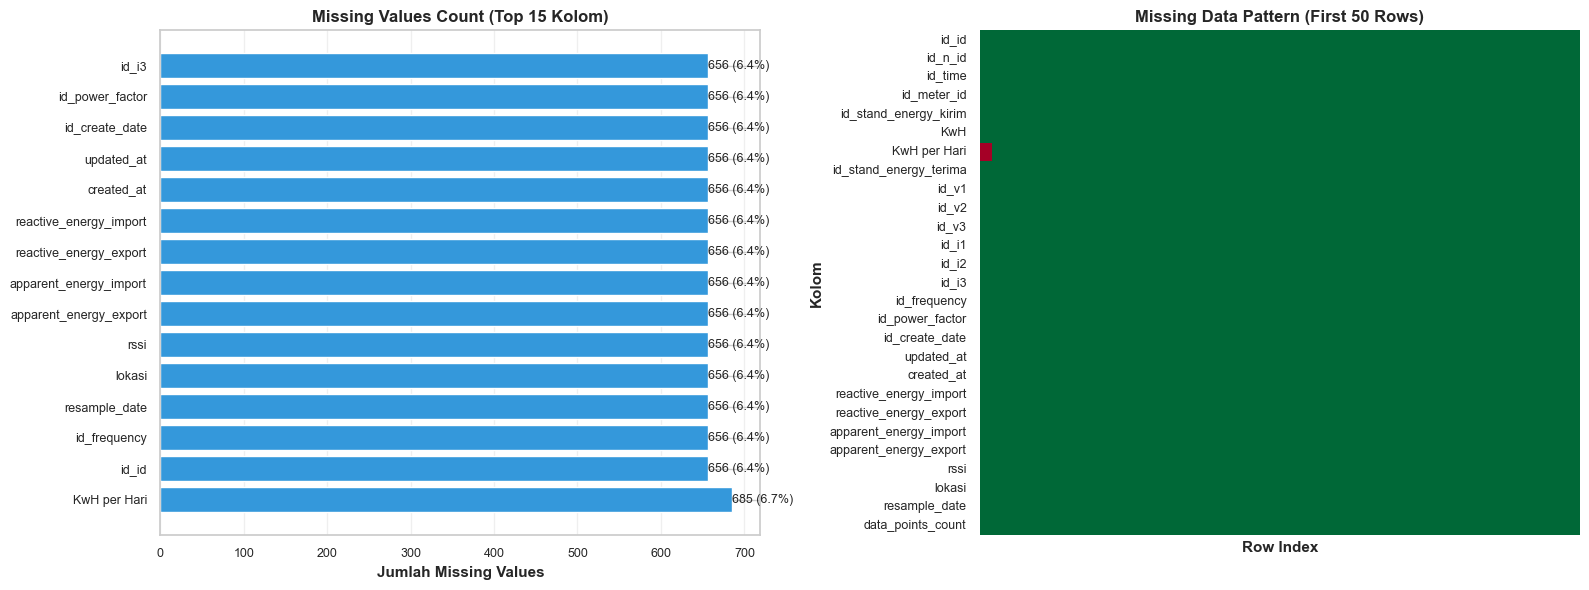

✅ Visualisasi selesai!



In [39]:
# ==========================================
# 2.6 VISUALISASI MISSING VALUES
# ==========================================

print("\n📊 VISUALISASI MISSING VALUES")
print("=" * 80)

# Hanya visualisasi jika ada missing values
if len(missing_data_filtered) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Bar chart - Missing Count
    ax1 = axes[0]
    missing_data_filtered_top = missing_data_filtered.head(15)  # Top 15
    colors = ['#e74c3c' if x >= 90 else '#e67e22' if x >= 50 else '#f39c12' if x >= 10 else '#3498db' 
              for x in missing_data_filtered_top['Missing_Pct']]
    
    ax1.barh(range(len(missing_data_filtered_top)), missing_data_filtered_top['Missing_Count'], color=colors)
    ax1.set_yticks(range(len(missing_data_filtered_top)))
    ax1.set_yticklabels(missing_data_filtered_top['Kolom'])
    ax1.set_xlabel('Jumlah Missing Values', fontsize=11, fontweight='bold')
    ax1.set_title('Missing Values Count (Top 15 Kolom)', fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Tambahkan value labels
    for i, v in enumerate(missing_data_filtered_top['Missing_Count']):
        ax1.text(v + 0.1, i, f"{v} ({missing_data_filtered_top['Missing_Pct'].iloc[i]:.1f}%)", 
                va='center', fontsize=9)
    
    # Plot 2: Heatmap - Missing Pattern (sample rows)
    ax2 = axes[1]
    sample_size = min(50, len(df))  # Max 50 rows untuk readability
    missing_matrix = df.head(sample_size).isnull().T
    
    sns.heatmap(missing_matrix, cmap='RdYlGn_r', cbar=False, ax=ax2, 
                yticklabels=True, xticklabels=False)
    ax2.set_title(f'Missing Data Pattern (First {sample_size} Rows)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Row Index', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Kolom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualisasi selesai!")
else:
    print("ℹ️  Tidak ada missing values untuk divisualisasikan")

print("\n" + "=" * 80)

In [40]:
# ==========================================
# 2.7 DROP KOLOM YANG TIDAK BERGUNA
# ==========================================

print("\n🗑️  DROPPING KOLOM YANG TIDAK BERGUNA")
print("=" * 80)

# Identifikasi kolom yang akan di-drop
cols_to_drop = []

# 1. Kolom dengan 100% missing values
critical_missing = missing_data[missing_data['Missing_Pct'] == 100]['Kolom'].tolist()
cols_to_drop.extend(critical_missing)

# 2. Kolom yang >95% missing dan tidak penting untuk analisis
high_missing = missing_data[missing_data['Missing_Pct'] >= 95]['Kolom'].tolist()
cols_to_drop.extend([col for col in high_missing if col not in cols_to_drop])

# 3. Kolom duplikat atau tidak perlu (contoh: id_id bisa jadi redundan dengan index)
# Uncomment jika perlu:
# redundant_cols = ['id_id', 'id_n_id']  
# cols_to_drop.extend([col for col in redundant_cols if col in df.columns and col not in cols_to_drop])

# Remove duplicates
cols_to_drop = list(set(cols_to_drop))

if len(cols_to_drop) > 0:
    print(f"📋 Kolom yang akan di-drop ({len(cols_to_drop)}):")
    for col in cols_to_drop:
        missing_pct = missing_data[missing_data['Kolom'] == col]['Missing_Pct'].values[0]
        print(f"   • {col:40s} ({missing_pct:.1f}% missing)")
    
    # Drop kolom
    df = df.drop(columns=cols_to_drop)
    print(f"\n✅ {len(cols_to_drop)} kolom berhasil dihapus!")
else:
    print("✅ Tidak ada kolom yang perlu di-drop")

print("\n" + "=" * 80)


🗑️  DROPPING KOLOM YANG TIDAK BERGUNA
✅ Tidak ada kolom yang perlu di-drop



In [41]:
# ==========================================
# 2.8 HANDLING MISSING VALUES STRATEGIS
# ==========================================

print("\n🔧 HANDLING MISSING VALUES PADA KOLOM PENTING")
print("=" * 80)

# Strategi berbeda untuk kolom berbeda
handling_strategy = {
    'id_neutral_current': 'fill_zero',  # Jika missing, asumsikan 0
    'id_daya_aktif_plus': 'forward_fill',  # Forward fill untuk power
    'id_daya_aktif_minus': 'fill_zero',  # Jika missing, asumsikan 0
    'rssi': 'keep_nan',  # Keep NaN, bukan parameter kritis
    'lokasi': 'fill_unknown',  # Fill dengan 'Unknown'
}

for col, strategy in handling_strategy.items():
    if col in df.columns:
        missing_before = df[col].isnull().sum()
        
        if missing_before > 0:
            if strategy == 'fill_zero':
                df[col] = df[col].fillna(0)
                print(f"   ✅ {col:30s} → {missing_before} NaN diisi dengan 0")
                
            elif strategy == 'forward_fill':
                df[col] = df[col].fillna(method='ffill')
                print(f"   ✅ {col:30s} → {missing_before} NaN diisi dengan forward fill")
                
            elif strategy == 'fill_unknown':
                df[col] = df[col].fillna('Unknown')
                print(f"   ✅ {col:30s} → {missing_before} NaN diisi dengan 'Unknown'")
                
            elif strategy == 'keep_nan':
                print(f"   ℹ️  {col:30s} → {missing_before} NaN dipertahankan (not critical)")

print("\n" + "=" * 80)


🔧 HANDLING MISSING VALUES PADA KOLOM PENTING
   ℹ️  rssi                           → 656 NaN dipertahankan (not critical)
   ✅ lokasi                         → 656 NaN diisi dengan 'Unknown'



In [42]:
# ==========================================
# 2.9 SUMMARY SETELAH PEMBERSIHAN
# ==========================================

print("\n📊 SUMMARY PEMBERSIHAN DATA")
print("=" * 80)

print("\n🔹 PERBANDINGAN DIMENSI:")
print(f"   SEBELUM: {df_original.shape[0]:,} baris × {df_original.shape[1]} kolom = {df_original.shape[0] * df_original.shape[1]:,} data points")
print(f"   SESUDAH: {df.shape[0]:,} baris × {df.shape[1]} kolom = {df.shape[0] * df.shape[1]:,} data points")
print(f"   SELISIH: {df_original.shape[1] - df.shape[1]} kolom dihapus")

print("\n🔹 KUALITAS DATA:")
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
completeness = ((total_cells - missing_cells) / total_cells * 100)

print(f"   Total Data Cells    : {total_cells:,}")
print(f"   Missing Cells       : {missing_cells:,}")
print(f"   Completeness Rate   : {completeness:.2f}%")

print("\n🔹 TIPE DATA:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {str(dtype):20s}: {count} kolom")

print("\n" + "=" * 80)

# Display info final
print("\n📋 STRUKTUR DATA FINAL:")
df.info()


📊 SUMMARY PEMBERSIHAN DATA

🔹 PERBANDINGAN DIMENSI:
   SEBELUM: 10,301 baris × 27 kolom = 278,127 data points
   SESUDAH: 10,301 baris × 27 kolom = 278,127 data points
   SELISIH: 0 kolom dihapus

🔹 KUALITAS DATA:
   Total Data Cells    : 278,127
   Missing Cells       : 17,085
   Completeness Rate   : 93.86%

🔹 TIPE DATA:
   float64             : 21 kolom
   object              : 6 kolom


📋 STRUKTUR DATA FINAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10301 entries, 0 to 10300
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_id                   9645 non-null   float64
 1   id_n_id                 9645 non-null   float64
 2   id_time                 9645 non-null   object 
 3   id_meter_id             9645 non-null   float64
 4   id_stand_energy_kirim   9645 non-null   float64
 5   KwH                     9645 non-null   float64
 6   KwH per Hari            9616 non-null   floa

In [43]:
# ==========================================
# 2.10 PREVIEW DATA SETELAH DIBERSIHKAN
# ==========================================

print("\n📋 PREVIEW DATA SETELAH DIBERSIHKAN")
print("=" * 80)
display(df.head(10))

print("\n📊 STATISTIK DESKRIPTIF (NUMERIK ONLY)")
print("=" * 80)
display(df.describe().T)


📋 PREVIEW DATA SETELAH DIBERSIHKAN


,id_id,id_n_id,id_time,id_meter_id,id_stand_energy_kirim,KwH,KwH per Hari,id_stand_energy_terima,id_v1,id_v2,id_v3,id_i1,id_i2,id_i3,id_frequency,id_power_factor,id_create_date,updated_at,created_at,reactive_energy_import,reactive_energy_export,apparent_energy_import,apparent_energy_export,rssi,lokasi,resample_date,data_points_count
0,605002.0,67.0,2024-01-01,2.51e+08,4.68e+07,4683.21,NaN,0.0,227.12,227.58,229.25,0.98,1.84,3.83,50.00,0.86,1/1/2024 22:25,1/1/2024 22:25,1/1/2024 22:25,9.76e+06,1.36e+06,5.13e+07,0.0,-110.60,97.0,1/1/2024,1.0
1,609728.0,67.0,2024-01-02,2.51e+08,4.74e+07,4736.55,53.34,0.0,225.54,225.69,227.79,1.27,10.69,5.24,50.00,0.95,1/2/2024 23:50,1/2/2024 23:50,1/2/2024 23:50,9.88e+06,1.37e+06,5.19e+07,0.0,-117.21,97.0,1/2/2024,1.0
2,612415.0,67.0,2024-01-03,2.51e+08,4.80e+07,4804.62,68.07,0.0,227.68,228.01,229.79,1.20,6.77,4.61,50.01,0.93,1/3/2024 23:55,1/3/2024 23:55,1/3/2024 23:55,1.00e+07,1.38e+06,5.26e+07,0.0,-119.73,97.0,1/3/2024,1.0
3,615949.0,67.0,2024-01-04,2.51e+08,4.86e+07,4856.85,52.23,0.0,226.45,226.95,228.42,1.00,4.10,4.59,50.00,0.91,1/4/2024 23:55,1/4/2024 23:55,1/4/2024 23:55,1.01e+07,1.39e+06,5.32e+07,0.0,-119.42,97.0,1/4/2024,1.0
4,619405.0,67.0,2024-01-05,2.51e+08,4.89e+07,4891.98,35.13,0.0,226.51,227.01,228.38,1.10,1.84,4.50,50.01,0.87,1/5/2024 20:50,1/5/2024 20:50,1/5/2024 20:50,1.02e+07,1.40e+06,5.36e+07,0.0,-117.79,97.0,1/5/2024,1.0
5,625154.0,67.0,2024-01-06,2.51e+08,4.94e+07,4942.60,50.63,0.0,228.43,228.92,230.43,1.88,2.25,4.08,50.03,0.89,1/6/2024 22:25,1/6/2024 22:25,1/6/2024 22:25,1.04e+07,1.41e+06,5.41e+07,0.0,-119.57,97.0,1/6/2024,1.0
6,627691.0,67.0,2024-01-07,2.51e+08,4.97e+07,4968.89,26.29,0.0,227.52,227.95,229.50,1.63,1.35,3.81,50.01,0.86,1/7/2024 23:55,1/7/2024 23:55,1/7/2024 23:55,1.04e+07,1.42e+06,5.44e+07,0.0,-119.74,97.0,1/7/2024,1.0
7,630410.0,67.0,2024-01-08,2.51e+08,5.00e+07,5003.19,34.30,0.0,226.60,227.03,228.58,1.75,2.87,4.42,50.02,0.89,1/8/2024 23:55,1/8/2024 23:55,1/8/2024 23:55,1.05e+07,1.43e+06,5.48e+07,0.0,-119.48,97.0,1/8/2024,1.0
8,634320.0,67.0,2024-01-09,2.51e+08,5.04e+07,5036.28,33.10,0.0,226.48,226.95,228.54,1.26,3.97,4.35,50.01,0.89,1/9/2024 20:55,1/9/2024 20:55,1/9/2024 20:55,1.06e+07,1.44e+06,5.52e+07,0.0,-120.34,97.0,1/9/2024,1.0
9,639005.0,67.0,2024-01-10,2.51e+08,5.11e+07,5106.66,70.37,0.0,228.70,228.98,230.69,1.00,2.58,4.25,50.02,0.89,1/10/2024 23:55,1/10/2024 23:55,1/10/2024 23:55,1.08e+07,1.46e+06,5.60e+07,0.0,-118.60,97.0,1/10/2024,1.0



📊 STATISTIK DESKRIPTIF (NUMERIK ONLY)


,count,mean,std,min,25%,50%,75%,max
id_id,9645.0,1.80e+06,7.91e+05,6.05e+05,1.07e+06,1.69e+06,2.67e+06,3.11e+06
id_n_id,9645.0,3.09e+01,1.34e+01,1.10e+01,2.00e+01,3.00e+01,3.90e+01,6.70e+01
id_meter_id,9645.0,2.51e+08,5.60e+01,2.51e+08,2.51e+08,2.51e+08,2.51e+08,2.51e+08
id_stand_energy_kirim,9645.0,9.91e+07,1.17e+08,2.68e+06,3.16e+07,6.52e+07,1.27e+08,1.27e+09
KwH,9645.0,9.91e+03,1.17e+04,2.68e+02,3.16e+03,6.52e+03,1.27e+04,1.27e+05
KwH per Hari,9616.0,3.92e+01,8.14e+01,0.00e+00,7.93e+00,2.47e+01,4.87e+01,2.21e+03
id_stand_energy_terima,9645.0,1.29e+03,4.95e+03,0.00e+00,0.00e+00,0.00e+00,0.00e+00,2.52e+04
id_v1,9645.0,2.27e+02,1.32e+00,2.18e+02,2.26e+02,2.27e+02,2.28e+02,2.32e+02
id_v2,9645.0,2.27e+02,1.44e+00,2.19e+02,2.27e+02,2.28e+02,2.28e+02,2.33e+02
id_v3,9645.0,2.29e+02,1.37e+00,2.20e+02,2.28e+02,2.29e+02,2.30e+02,2.32e+02


In [44]:
# ==========================================
# 2.11 KONVERSI TIPE DATA WAKTU (FIX)
# ==========================================
# Ini adalah langkah yang hilang. Kita harus mengubah 'id_time' 
# dari 'object' menjadi 'datetime' agar bisa dianalisis.

print("\n🔄 Mengonversi 'id_time' dan kolom tanggal lainnya...")

# Gunakan 'errors=coerce' untuk mengubah tanggal yang salah format menjadi NaT (Not a Time)
# ganti 'id_time' dengan nama kolom waktu Anda yang benar jika berbeda
df['id_time'] = pd.to_datetime(df['id_time'], errors='coerce')

# Konversi juga kolom tanggal lain jika perlu (opsional tapi disarankan)
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['updated_at'] = pd.to_datetime(df['updated_at'], errors='coerce')

print("✅ Konversi datetime selesai!")

# Verifikasi perubahan
print("\n📋 Struktur Data Setelah Konversi Waktu:")
df.info()


🔄 Mengonversi 'id_time' dan kolom tanggal lainnya...
✅ Konversi datetime selesai!

📋 Struktur Data Setelah Konversi Waktu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10301 entries, 0 to 10300
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_id                   9645 non-null   float64       
 1   id_n_id                 9645 non-null   float64       
 2   id_time                 9645 non-null   datetime64[ns]
 3   id_meter_id             9645 non-null   float64       
 4   id_stand_energy_kirim   9645 non-null   float64       
 5   KwH                     9645 non-null   float64       
 6   KwH per Hari            9616 non-null   float64       
 7   id_stand_energy_terima  9645 non-null   float64       
 8   id_v1                   9645 non-null   float64       
 9   id_v2                   9645 non-null   float64       
 10  id_v3                   9645 non-null   fl

In [45]:
# ==========================================
# 3.1 PEMETAAN METER KE KATEGORI BEBAN
# ==========================================

print("=" * 80)
print("🗺️  PEMETAAN METER KE KATEGORI BEBAN")
print("=" * 80)

# --- METER MAP BERDASARKAN DIAGRAM ELEKTRIKAL ---
# Lengkapi sesuai dengan data 500 baris Anda

meter_map = {
    # ========== MDP 3.1 WITEL ==========
    # HVAC - Chiller & AHU
    251400177: {'kategori_beban': 'CHILLER', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400251: {'kategori_beban': 'AHU_L1_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400321: {'kategori_beban': 'AHU_L2_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400387: {'kategori_beban': 'AHU_L3_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400373: {'kategori_beban': 'AHU_L4_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400316: {'kategori_beban': 'AHU_L5_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400276: {'kategori_beban': 'AHU_L6_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400382: {'kategori_beban': 'AHU_L7_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400385: {'kategori_beban': 'AHU_L8_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400271: {'kategori_beban': 'DBT_AC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # IT Equipment
    251400372: {'kategori_beban': 'SERVER_NOC', 'group_beban': 'IT', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # Mekanikal - Lift
    251400184: {'kategori_beban': 'LIFT_WITEL', 'group_beban': 'MEKANIKAL', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # Power Distribution - SDP
    251400383: {'kategori_beban': 'SDP_L1_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400322: {'kategori_beban': 'SDP_L2_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400320: {'kategori_beban': 'SDP_L3_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400277: {'kategori_beban': 'SDP_L4_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400381: {'kategori_beban': 'SDP_L5_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400384: {'kategori_beban': 'SDP_L6_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400279: {'kategori_beban': 'SDP_L7_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400278: {'kategori_beban': 'SDP_L8_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # ========== MDP 3.2 OPMC ==========
    # HVAC - AHU
    251400247: {'kategori_beban': 'AHU_L2_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400318: {'kategori_beban': 'AHU_L3_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400244: {'kategori_beban': 'AHU_L4_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400281: {'kategori_beban': 'AHU_L5_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400270: {'kategori_beban': 'AHU_L6_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # IT Equipment
    251400280: {'kategori_beban': 'PANEL_SISCA_L6', 'group_beban': 'IT', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # Mekanikal - Lift
    251400378: {'kategori_beban': 'LIFT_OPMC', 'group_beban': 'MEKANIKAL', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # Power Distribution - SDP
    251400282: {'kategori_beban': 'SDP_L1_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400249: {'kategori_beban': 'SDP_L2_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400248: {'kategori_beban': 'SDP_L3_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400319: {'kategori_beban': 'SDP_L4_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400323: {'kategori_beban': 'SDP_L5_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400386: {'kategori_beban': 'SDP_L6_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # ========== METER DARI SAMPEL (Unknown) ==========
    251400179: {'kategori_beban': 'METER_179', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400172: {'kategori_beban': 'METER_172', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400182: {'kategori_beban': 'METER_182', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400178: {'kategori_beban': 'METER_178', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400181: {'kategori_beban': 'METER_181', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
}

print(f"\n✅ Meter map berisi {len(meter_map)} meter yang teridentifikasi\n")

# Konversi map ke DataFrame
map_df = pd.DataFrame.from_dict(meter_map, orient='index').reset_index()
map_df = map_df.rename(columns={'index': 'id_meter_id'})

print("📋 PREVIEW METER MAP:")
display(map_df.head(10))

🗺️  PEMETAAN METER KE KATEGORI BEBAN

✅ Meter map berisi 38 meter yang teridentifikasi

📋 PREVIEW METER MAP:


,id_meter_id,kategori_beban,group_beban,lokasi_panel
0,251400177,CHILLER,HVAC,MDP_3.1_WITEL
1,251400251,AHU_L1_WITEL,HVAC,MDP_3.1_WITEL
2,251400321,AHU_L2_WITEL,HVAC,MDP_3.1_WITEL
3,251400387,AHU_L3_WITEL,HVAC,MDP_3.1_WITEL
4,251400373,AHU_L4_WITEL,HVAC,MDP_3.1_WITEL
5,251400316,AHU_L5_WITEL,HVAC,MDP_3.1_WITEL
6,251400276,AHU_L6_WITEL,HVAC,MDP_3.1_WITEL
7,251400382,AHU_L7_WITEL,HVAC,MDP_3.1_WITEL
8,251400385,AHU_L8_WITEL,HVAC,MDP_3.1_WITEL
9,251400271,DBT_AC,HVAC,MDP_3.1_WITEL


In [46]:
# ==========================================
# 3.2 VALIDASI COVERAGE METER MAP
# ==========================================

print("\n" + "=" * 80)
print("🔍 VALIDASI COVERAGE METER MAP")
print("=" * 80)

# Identifikasi meter unik di data
unique_meters_in_data = df['id_meter_id'].unique()
unique_meters_in_map = map_df['id_meter_id'].unique()

print(f"\n📊 SUMMARY:")
print(f"   Meter unik di DATA     : {len(unique_meters_in_data)}")
print(f"   Meter unik di MAP      : {len(unique_meters_in_map)}")

# Meter yang ada di data tapi tidak di map
unmapped_meters = set(unique_meters_in_data) - set(unique_meters_in_map)
if len(unmapped_meters) > 0:
    print(f"\n⚠️  UNMAPPED METERS ({len(unmapped_meters)}):")
    for meter in unmapped_meters:
        count = len(df[df['id_meter_id'] == meter])
        pct = (count / len(df) * 100)
        print(f"      • Meter {meter}: {count} records ({pct:.1f}% dari total data)")
    print(f"\n   ⚡ ACTION: Tambahkan meter ini ke dalam meter_map dictionary!")
else:
    print(f"\n✅ Semua meter di data sudah termapping!")

# Meter yang ada di map tapi tidak di data
unused_meters = set(unique_meters_in_map) - set(unique_meters_in_data)
if len(unused_meters) > 0:
    print(f"\nℹ️  UNUSED METERS di map ({len(unused_meters)}):")
    print(f"   Meter-meter ini ada di map tapi tidak ada di dataset sampel")
    print(f"   (Normal jika menggunakan data sampel 25 baris)")

print("\n" + "=" * 80)


🔍 VALIDASI COVERAGE METER MAP

📊 SUMMARY:
   Meter unik di DATA     : 30
   Meter unik di MAP      : 38

⚠️  UNMAPPED METERS (1):
      • Meter nan: 0 records (0.0% dari total data)

   ⚡ ACTION: Tambahkan meter ini ke dalam meter_map dictionary!

ℹ️  UNUSED METERS di map (9):
   Meter-meter ini ada di map tapi tidak ada di dataset sampel
   (Normal jika menggunakan data sampel 25 baris)



In [47]:
# ==========================================
# 3.3 MERGE DATA DENGAN METER MAP
# ==========================================

print("\n🔗 MERGING DATA DENGAN METER MAP")
print("=" * 80)

# Backup sebelum merge
df_before_merge = df.copy()

# Merge
df = pd.merge(df, map_df, on='id_meter_id', how='left')

# Handle unmapped meters
unmapped_count = df['kategori_beban'].isnull().sum()

if unmapped_count > 0:
    print(f"\n⚠️  {unmapped_count} records dengan meter yang tidak termapping")
    print(f"   Mengisi dengan kategori 'UNIDENTIFIED'")
    
    df['kategori_beban'] = df['kategori_beban'].fillna('UNIDENTIFIED')
    df['group_beban'] = df['group_beban'].fillna('UNIDENTIFIED')
    df['lokasi_panel'] = df['lokasi_panel'].fillna('UNKNOWN')

print(f"\n✅ Merge selesai!")
print(f"   Kolom baru ditambahkan: kategori_beban, group_beban, lokasi_panel")

# Summary distribusi group beban
print(f"\n📊 DISTRIBUSI GROUP BEBAN:")
group_dist = df['group_beban'].value_counts()
for group, count in group_dist.items():
    pct = (count / len(df) * 100)
    print(f"   {group:20s}: {count:4d} records ({pct:5.1f}%)")

print("\n" + "=" * 80)


🔗 MERGING DATA DENGAN METER MAP

⚠️  656 records dengan meter yang tidak termapping
   Mengisi dengan kategori 'UNIDENTIFIED'

✅ Merge selesai!
   Kolom baru ditambahkan: kategori_beban, group_beban, lokasi_panel

📊 DISTRIBUSI GROUP BEBAN:
   POWER_DIST          : 4793 records ( 46.5%)
   HVAC                : 4509 records ( 43.8%)
   UNIDENTIFIED        :  656 records (  6.4%)
   MEKANIKAL           :  343 records (  3.3%)



In [48]:
# ==========================================
# 3.4 PERHITUNGAN KONSUMSI ENERGI (DELTA)
# ==========================================

print("\n⚡ PERHITUNGAN KONSUMSI ENERGI (DELTA METHOD)")
print("=" * 80)

# STEP 1: Pastikan data terurut dengan benar
print("\n📐 STEP 1: Sorting data...")
df = df.sort_values(by=['id_meter_id', 'id_time']).reset_index(drop=True)
print(f"   ✅ Data diurutkan berdasarkan [id_meter_id, id_time]")

# STEP 2: Hitung delta (konsumsi) per meter
print(f"\n🔢 STEP 2: Menghitung delta energi...")
df['energy_consumed_kwh'] = df.groupby('id_meter_id')['id_stand_energy_kirim'].diff()

# Hitung berapa yang berhasil
valid_consumption = df['energy_consumed_kwh'].notna().sum()
print(f"   ✅ {valid_consumption} dari {len(df)} records berhasil dihitung")

# STEP 3: Handle edge cases
print(f"\n🛠️  STEP 3: Handling edge cases...")

# 3.1 - First reading per meter (NaN)
first_readings = df['energy_consumed_kwh'].isnull().sum()
if first_readings > 0:
    print(f"   • {first_readings} first readings (NaN) → diisi dengan 0")
    df['energy_consumed_kwh'] = df['energy_consumed_kwh'].fillna(0)

# 3.2 - Negative values (meter reset)
negative_count = (df['energy_consumed_kwh'] < 0).sum()
if negative_count > 0:
    print(f"   • {negative_count} negative values (meter reset detected)")
    print(f"     → Menampilkan detail untuk investigasi...")
    
    negative_data = df[df['energy_consumed_kwh'] < 0][
        ['id_time', 'id_meter_id', 'kategori_beban', 'id_stand_energy_kirim', 'energy_consumed_kwh']
    ].head(10)
    display(negative_data)
    
    # Option: Set negative to 0 or keep for analysis
    print(f"\n   ⚠️  ACTION DIPERLUKAN:")
    print(f"      - Opsi 1: Set negative ke 0 (asumsikan error)")
    print(f"      - Opsi 2: Keep untuk analisis anomali")
    print(f"      - Untuk tutorial ini: KEEP (tidak diubah)")

# 3.3 - Extreme outliers (>1000 kWh dalam 5 menit? Tidak masuk akal)
outlier_threshold = 5000  # kWh
extreme_outliers = (df['energy_consumed_kwh'] > outlier_threshold).sum()
if extreme_outliers > 0:
    print(f"   • {extreme_outliers} extreme outliers (>{outlier_threshold} kWh)")
    print(f"     → Menampilkan untuk investigasi...")
    
    outlier_data = df[df['energy_consumed_kwh'] > outlier_threshold][
        ['id_time', 'id_meter_id', 'kategori_beban', 'energy_consumed_kwh']
    ].head(10)
    display(outlier_data)

print("\n✅ Perhitungan konsumsi energi selesai!")
print("=" * 80)


⚡ PERHITUNGAN KONSUMSI ENERGI (DELTA METHOD)

📐 STEP 1: Sorting data...
   ✅ Data diurutkan berdasarkan [id_meter_id, id_time]

🔢 STEP 2: Menghitung delta energi...
   ✅ 9616 dari 10301 records berhasil dihitung

🛠️  STEP 3: Handling edge cases...
   • 685 first readings (NaN) → diisi dengan 0
   • 8647 extreme outliers (>5000 kWh)
     → Menampilkan untuk investigasi...


,id_time,id_meter_id,kategori_beban,energy_consumed_kwh
1,2024-01-02,2.51e+08,CHILLER,5.85e+06
2,2024-01-03,2.51e+08,CHILLER,1.39e+07
3,2024-01-04,2.51e+08,CHILLER,1.20e+07
4,2024-01-05,2.51e+08,CHILLER,1.24e+07
5,2024-01-06,2.51e+08,CHILLER,6.55e+06
6,2024-01-07,2.51e+08,CHILLER,3.45e+05
7,2024-01-08,2.51e+08,CHILLER,8.16e+06
8,2024-01-09,2.51e+08,CHILLER,1.30e+07
9,2024-01-10,2.51e+08,CHILLER,1.39e+07
10,2024-01-11,2.51e+08,CHILLER,1.10e+07



✅ Perhitungan konsumsi energi selesai!


In [49]:
# ==========================================
# 3.5 EKSTRAKSI FITUR TEMPORAL
# ==========================================

print("\n📅 EKSTRAKSI FITUR TEMPORAL (TIME-BASED FEATURES)")
print("=" * 80)

if pd.api.types.is_datetime64_any_dtype(df['id_time']):
    print("\n⏰ Membuat fitur temporal dari kolom 'id_time'...\n")
    
    # Date components
    df['year'] = df['id_time'].dt.year
    df['month'] = df['id_time'].dt.month
    df['day'] = df['id_time'].dt.day
    df['hour'] = df['id_time'].dt.hour
    df['minute'] = df['id_time'].dt.minute
    df['dayofweek'] = df['id_time'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['dayname'] = df['id_time'].dt.day_name()
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # Time of day categorization
    def categorize_time_of_day(hour):
        if 6 <= hour < 12:
            return 'Pagi'
        elif 12 <= hour < 18:
            return 'Siang'
        elif 18 <= hour < 22:
            return 'Malam'
        else:
            return 'Dini_Hari'
    
    df['time_of_day'] = df['hour'].apply(categorize_time_of_day)
    
    # Business hours
    df['is_business_hour'] = ((df['hour'] >= 8) & (df['hour'] < 17) & (df['is_weekend'] == 0)).astype(int)
    
    # Time interval calculation (minutes between readings)
    df['time_interval_minutes'] = df.groupby('id_meter_id')['id_time'].diff().dt.total_seconds() / 60
    
    print("✅ Fitur temporal berhasil dibuat:")
    temporal_features = ['year', 'month', 'day', 'hour', 'minute', 'dayofweek', 'dayname', 
                         'is_weekend', 'time_of_day', 'is_business_hour', 'time_interval_minutes']
    for feat in temporal_features:
        print(f"   • {feat}")
    
    # Summary
    print(f"\n📊 SUMMARY TEMPORAL:")
    print(f"   Periode data      : {df['id_time'].min()} s/d {df['id_time'].max()}")
    print(f"   Durasi total      : {(df['id_time'].max() - df['id_time'].min()).days} hari")
    print(f"   Weekend records   : {df['is_weekend'].sum()} ({df['is_weekend'].sum()/len(df)*100:.1f}%)")
    print(f"   Business hours    : {df['is_business_hour'].sum()} ({df['is_business_hour'].sum()/len(df)*100:.1f}%)")
else:
    print("⚠️  Kolom 'id_time' bukan datetime. Skip ekstraksi temporal.")

print("\n" + "=" * 80)


📅 EKSTRAKSI FITUR TEMPORAL (TIME-BASED FEATURES)

⏰ Membuat fitur temporal dari kolom 'id_time'...

✅ Fitur temporal berhasil dibuat:
   • year
   • month
   • day
   • hour
   • minute
   • dayofweek
   • dayname
   • is_weekend
   • time_of_day
   • is_business_hour
   • time_interval_minutes

📊 SUMMARY TEMPORAL:
   Periode data      : 2024-01-01 00:00:00 s/d 2024-12-31 00:00:00
   Durasi total      : 365 hari
   Weekend records   : 2770 (26.9%)
   Business hours    : 0 (0.0%)



In [50]:
# ==========================================
# 3.6 PERHITUNGAN METRIK POWER TAMBAHAN
# ==========================================

print("\n⚡ PERHITUNGAN METRIK POWER TAMBAHAN")
print("=" * 80)

print("\n🔧 Membuat metrik power tambahan...\n")

# 1. Average Voltage per phase
df['voltage_avg'] = (df['id_v1'] + df['id_v2'] + df['id_v3']) / 3

# 2. Average Current per phase
df['current_avg'] = (df['id_i1'] + df['id_i2'] + df['id_i3']) / 3

# 3. Voltage imbalance (max deviation from average)
df['voltage_imbalance_pct'] = (
    df[['id_v1', 'id_v2', 'id_v3']].max(axis=1) - 
    df[['id_v1', 'id_v2', 'id_v3']].min(axis=1)
) / df['voltage_avg'] * 100

# 4. Current imbalance (max deviation from average)
df['current_imbalance_pct'] = (
    df[['id_i1', 'id_i2', 'id_i3']].max(axis=1) - 
    df[['id_i1', 'id_i2', 'id_i3']].min(axis=1)
) / df['current_avg'].replace(0, np.nan) * 100

# 5. Total Apparent Power (VA) - 3 phase
# S = sqrt(3) × V_line × I_line
df['apparent_power_kva'] = np.sqrt(3) * (df['voltage_avg'] / 1000) * df['current_avg']

# 6. Total Active Power (W) - estimated
# P = S × PF
df['active_power_kw'] = df['apparent_power_kva'] * df['id_power_factor']

# 7. Reactive Power (VAR) - estimated
# Q = sqrt(S² - P²)
df['reactive_power_kvar'] = np.sqrt(
    np.maximum(df['apparent_power_kva']**2 - df['active_power_kw']**2, 0)
)

# 8. Power quality indicator (low PF = poor quality)
df['power_quality'] = pd.cut(
    df['id_power_factor'], 
    bins=[0, 0.85, 0.95, 1.0], 
    labels=['Poor', 'Fair', 'Good']
)

# 9. Energy consumption rate (kW per interval)
# Handle division by zero
df['consumption_rate_kw'] = df['energy_consumed_kwh'] / (
    df['time_interval_minutes'].replace(0, np.nan) / 60
)

print("✅ Metrik power tambahan berhasil dibuat:")
power_metrics = [
    'voltage_avg', 'current_avg', 'voltage_imbalance_pct', 'current_imbalance_pct',
    'apparent_power_kva', 'active_power_kw', 'reactive_power_kvar', 
    'power_quality', 'consumption_rate_kw'
]
for metric in power_metrics:
    print(f"   • {metric}")

# Summary statistik
print(f"\n📊 STATISTIK POWER METRICS:")
summary_cols = ['voltage_avg', 'current_avg', 'apparent_power_kva', 
                'active_power_kw', 'id_power_factor']
display(df[summary_cols].describe().T)

print("\n" + "=" * 80)


⚡ PERHITUNGAN METRIK POWER TAMBAHAN

🔧 Membuat metrik power tambahan...

✅ Metrik power tambahan berhasil dibuat:
   • voltage_avg
   • current_avg
   • voltage_imbalance_pct
   • current_imbalance_pct
   • apparent_power_kva
   • active_power_kw
   • reactive_power_kvar
   • power_quality
   • consumption_rate_kw

📊 STATISTIK POWER METRICS:


,count,mean,std,min,25%,50%,75%,max
voltage_avg,9645.0,227.68,1.23,219.74,227.01,227.71,228.60,232.33
current_avg,9645.0,2.69,5.48,0.00,0.34,1.98,3.68,119.63
apparent_power_kva,9645.0,1.06,2.15,0.00,0.13,0.78,1.45,46.86
active_power_kw,9645.0,0.82,1.86,0.00,0.09,0.43,1.13,40.64
id_power_factor,9645.0,0.69,0.28,0.00,0.54,0.79,0.89,1.00


In [51]:
# ==========================================
# 3.6 PERHITUNGAN METRIK POWER TAMBAHAN
# ==========================================

print("\n⚡ PERHITUNGAN METRIK POWER TAMBAHAN")
print("=" * 80)

print("\n🔧 Membuat metrik power tambahan...\n")

# 1. Average Voltage per phase
df['voltage_avg'] = (df['id_v1'] + df['id_v2'] + df['id_v3']) / 3

# 2. Average Current per phase
df['current_avg'] = (df['id_i1'] + df['id_i2'] + df['id_i3']) / 3

# 3. Voltage imbalance (max deviation from average)
df['voltage_imbalance_pct'] = (
    df[['id_v1', 'id_v2', 'id_v3']].max(axis=1) - 
    df[['id_v1', 'id_v2', 'id_v3']].min(axis=1)
) / df['voltage_avg'] * 100

# 4. Current imbalance (max deviation from average)
df['current_imbalance_pct'] = (
    df[['id_i1', 'id_i2', 'id_i3']].max(axis=1) - 
    df[['id_i1', 'id_i2', 'id_i3']].min(axis=1)
) / df['current_avg'].replace(0, np.nan) * 100

# 5. Total Apparent Power (VA) - 3 phase
# S = sqrt(3) × V_line × I_line
df['apparent_power_kva'] = np.sqrt(3) * (df['voltage_avg'] / 1000) * df['current_avg']

# 6. Total Active Power (W) - estimated
# P = S × PF
df['active_power_kw'] = df['apparent_power_kva'] * df['id_power_factor']

# 7. Reactive Power (VAR) - estimated
# Q = sqrt(S² - P²)
df['reactive_power_kvar'] = np.sqrt(
    np.maximum(df['apparent_power_kva']**2 - df['active_power_kw']**2, 0)
)

# 8. Power quality indicator (low PF = poor quality)
df['power_quality'] = pd.cut(
    df['id_power_factor'], 
    bins=[0, 0.85, 0.95, 1.0], 
    labels=['Poor', 'Fair', 'Good']
)

# 9. Energy consumption rate (kW per interval)
# Handle division by zero
df['consumption_rate_kw'] = df['energy_consumed_kwh'] / (
    df['time_interval_minutes'].replace(0, np.nan) / 60
)

print("✅ Metrik power tambahan berhasil dibuat:")
power_metrics = [
    'voltage_avg', 'current_avg', 'voltage_imbalance_pct', 'current_imbalance_pct',
    'apparent_power_kva', 'active_power_kw', 'reactive_power_kvar', 
    'power_quality', 'consumption_rate_kw'
]
for metric in power_metrics:
    print(f"   • {metric}")

# Summary statistik
print(f"\n📊 STATISTIK POWER METRICS:")
summary_cols = ['voltage_avg', 'current_avg', 'apparent_power_kva', 
                'active_power_kw', 'id_power_factor']
display(df[summary_cols].describe().T)

print("\n" + "=" * 80)


⚡ PERHITUNGAN METRIK POWER TAMBAHAN

🔧 Membuat metrik power tambahan...

✅ Metrik power tambahan berhasil dibuat:
   • voltage_avg
   • current_avg
   • voltage_imbalance_pct
   • current_imbalance_pct
   • apparent_power_kva
   • active_power_kw
   • reactive_power_kvar
   • power_quality
   • consumption_rate_kw

📊 STATISTIK POWER METRICS:


,count,mean,std,min,25%,50%,75%,max
voltage_avg,9645.0,227.68,1.23,219.74,227.01,227.71,228.60,232.33
current_avg,9645.0,2.69,5.48,0.00,0.34,1.98,3.68,119.63
apparent_power_kva,9645.0,1.06,2.15,0.00,0.13,0.78,1.45,46.86
active_power_kw,9645.0,0.82,1.86,0.00,0.09,0.43,1.13,40.64
id_power_factor,9645.0,0.69,0.28,0.00,0.54,0.79,0.89,1.00


In [52]:
# ==========================================
# 3.7 FEATURE UNTUK DETEKSI ANOMALI
# ==========================================

print("\n🚨 FEATURE ENGINEERING UNTUK DETEKSI ANOMALI")
print("=" * 80)

print("\n🔍 Membuat features untuk anomaly detection...\n")

# 1. Rolling statistics (untuk deteksi sudden spike)
window = 5  # 5 readings

for col in ['energy_consumed_kwh', 'current_avg', 'active_power_kw']:
    if col in df.columns:
        df[f'{col}_rolling_mean'] = df.groupby('id_meter_id')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f'{col}_rolling_std'] = df.groupby('id_meter_id')[col].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )

# 2. Deviation from rolling mean (z-score like)
df['energy_deviation'] = (
    df['energy_consumed_kwh'] - df['energy_consumed_kwh_rolling_mean']
) / df['energy_consumed_kwh_rolling_std'].replace(0, np.nan)

# 3. Binary flag untuk anomaly
anomaly_threshold = 3  # 3 standard deviations
df['is_anomaly_energy'] = (abs(df['energy_deviation']) > anomaly_threshold).astype(int)

# 4. Power factor anomaly (< 0.85 considered poor)
df['is_anomaly_pf'] = (df['id_power_factor'] < 0.85).astype(int)

# 5. Voltage anomaly (outside ±10% of 220V nominal)
df['is_anomaly_voltage'] = (
    (df['voltage_avg'] < 198) | (df['voltage_avg'] > 242)
).astype(int)

print("✅ Anomaly detection features berhasil dibuat:")
anomaly_features = [
    'energy_consumed_kwh_rolling_mean', 'energy_consumed_kwh_rolling_std',
    'energy_deviation', 'is_anomaly_energy', 'is_anomaly_pf', 'is_anomaly_voltage'
]
for feat in anomaly_features:
    print(f"   • {feat}")

# Summary anomalies detected
print(f"\n🚨 ANOMALI TERDETEKSI:")
print(f"   Energy anomalies   : {df['is_anomaly_energy'].sum()} ({df['is_anomaly_energy'].mean()*100:.1f}%)")
print(f"   Power factor anom. : {df['is_anomaly_pf'].sum()} ({df['is_anomaly_pf'].mean()*100:.1f}%)")
print(f"   Voltage anomalies  : {df['is_anomaly_voltage'].sum()} ({df['is_anomaly_voltage'].mean()*100:.1f}%)")

print("\n" + "=" * 80)


🚨 FEATURE ENGINEERING UNTUK DETEKSI ANOMALI

🔍 Membuat features untuk anomaly detection...

✅ Anomaly detection features berhasil dibuat:
   • energy_consumed_kwh_rolling_mean
   • energy_consumed_kwh_rolling_std
   • energy_deviation
   • is_anomaly_energy
   • is_anomaly_pf
   • is_anomaly_voltage

🚨 ANOMALI TERDETEKSI:
   Energy anomalies   : 0 (0.0%)
   Power factor anom. : 6220 (60.4%)
   Voltage anomalies  : 0 (0.0%)



In [53]:
# ==========================================
# 3.8 VALIDASI HASIL FEATURE ENGINEERING
# ==========================================

print("\n✅ VALIDASI HASIL FEATURE ENGINEERING")
print("=" * 80)

# Preview data dengan fitur baru
print("\n📋 PREVIEW DATA DENGAN FITUR BARU (10 baris pertama):")
key_cols = [
    'id_time', 'id_meter_id', 'kategori_beban', 'group_beban',
    'energy_consumed_kwh', 'hour', 'time_of_day', 'is_business_hour',
    'voltage_avg', 'current_avg', 'active_power_kw', 'id_power_factor'
]
available_cols = [col for col in key_cols if col in df.columns]
display(df[available_cols].head(10))

# Summary kolom baru yang ditambahkan
print(f"\n📊 SUMMARY KOLOM:")
print(f"   Kolom SEBELUM feature engineering: {df_before_merge.shape[1]}")
print(f"   Kolom SESUDAH feature engineering: {df.shape[1]}")
print(f"   KOLOM BARU DITAMBAHKAN           : {df.shape[1] - df_before_merge.shape[1]}")

print("\n🆕 DAFTAR KOLOM BARU:")
new_cols = [col for col in df.columns if col not in df_before_merge.columns]
for i, col in enumerate(new_cols, 1):
    print(f"   {i:2d}. {col}")

print("\n" + "=" * 80)


✅ VALIDASI HASIL FEATURE ENGINEERING

📋 PREVIEW DATA DENGAN FITUR BARU (10 baris pertama):


,id_time,id_meter_id,kategori_beban,group_beban,energy_consumed_kwh,hour,time_of_day,is_business_hour,voltage_avg,current_avg,active_power_kw,id_power_factor
0,2024-01-01,2.51e+08,CHILLER,HVAC,0.00e+00,0.0,Dini_Hari,0,228.05,2.66,0.91,0.87
1,2024-01-02,2.51e+08,CHILLER,HVAC,5.85e+06,0.0,Dini_Hari,0,226.52,90.72,30.90,0.87
2,2024-01-03,2.51e+08,CHILLER,HVAC,1.39e+07,0.0,Dini_Hari,0,227.65,95.66,32.37,0.86
3,2024-01-04,2.51e+08,CHILLER,HVAC,1.20e+07,0.0,Dini_Hari,0,226.66,75.75,25.20,0.85
4,2024-01-05,2.51e+08,CHILLER,HVAC,1.24e+07,0.0,Dini_Hari,0,226.96,92.78,31.15,0.85
5,2024-01-06,2.51e+08,CHILLER,HVAC,6.55e+06,0.0,Dini_Hari,0,229.17,2.67,0.92,0.87
6,2024-01-07,2.51e+08,CHILLER,HVAC,3.45e+05,0.0,Dini_Hari,0,228.84,2.67,0.92,0.87
7,2024-01-08,2.51e+08,CHILLER,HVAC,8.16e+06,0.0,Dini_Hari,0,225.82,119.16,40.64,0.87
8,2024-01-09,2.51e+08,CHILLER,HVAC,1.30e+07,0.0,Dini_Hari,0,226.62,82.95,28.29,0.87
9,2024-01-10,2.51e+08,CHILLER,HVAC,1.39e+07,0.0,Dini_Hari,0,227.33,96.85,32.84,0.86



📊 SUMMARY KOLOM:
   Kolom SEBELUM feature engineering: 27
   Kolom SESUDAH feature engineering: 61
   KOLOM BARU DITAMBAHKAN           : 34

🆕 DAFTAR KOLOM BARU:
    1. kategori_beban
    2. group_beban
    3. lokasi_panel
    4. energy_consumed_kwh
    5. year
    6. month
    7. day
    8. hour
    9. minute
   10. dayofweek
   11. dayname
   12. is_weekend
   13. time_of_day
   14. is_business_hour
   15. time_interval_minutes
   16. voltage_avg
   17. current_avg
   18. voltage_imbalance_pct
   19. current_imbalance_pct
   20. apparent_power_kva
   21. active_power_kw
   22. reactive_power_kvar
   23. power_quality
   24. consumption_rate_kw
   25. energy_consumed_kwh_rolling_mean
   26. energy_consumed_kwh_rolling_std
   27. current_avg_rolling_mean
   28. current_avg_rolling_std
   29. active_power_kw_rolling_mean
   30. active_power_kw_rolling_std
   31. energy_deviation
   32. is_anomaly_energy
   33. is_anomaly_pf
   34. is_anomaly_voltage




📊 VISUALISASI HASIL FEATURE ENGINEERING


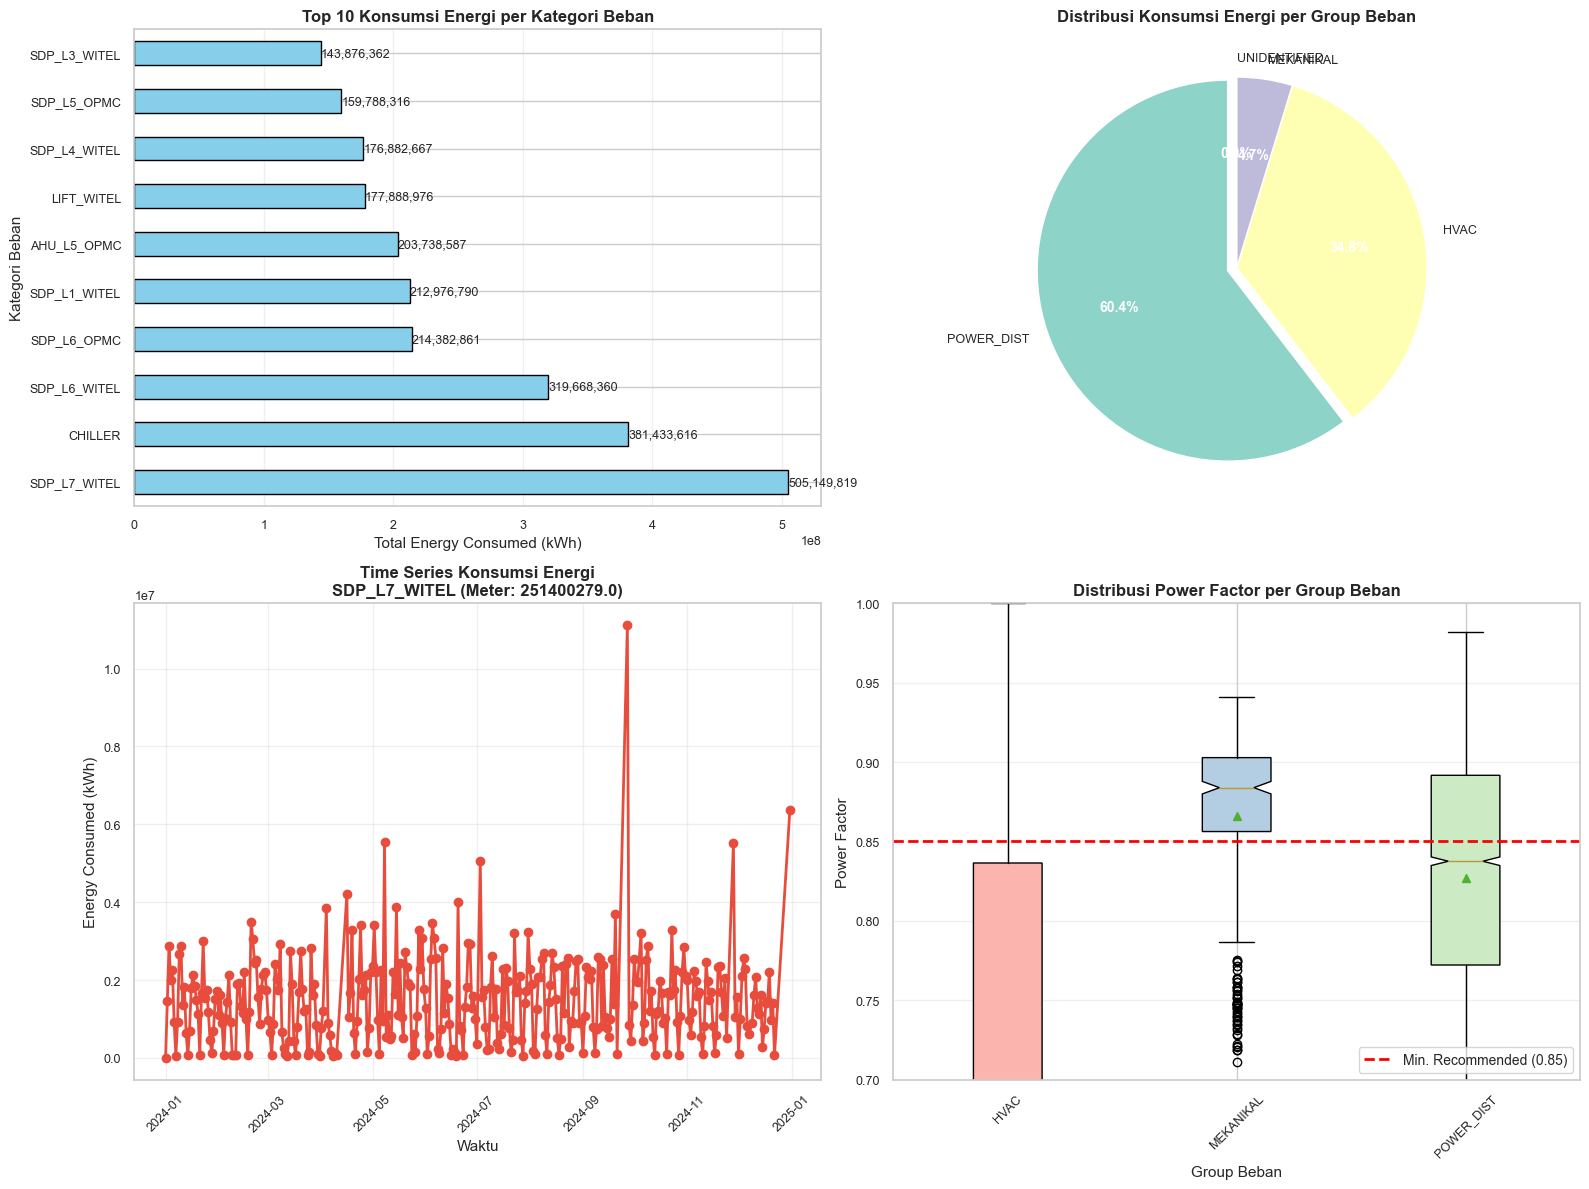


✅ Visualisasi selesai!


In [55]:
# ==========================================
# 3.9 VISUALISASI HASIL FEATURE ENGINEERING
# ==========================================

print("\n📊 VISUALISASI HASIL FEATURE ENGINEERING")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Konsumsi energi per kategori beban
ax1 = axes[0, 0]
energy_by_category = df.groupby('kategori_beban')['energy_consumed_kwh'].sum().sort_values(ascending=False).head(10)
energy_by_category.plot(kind='barh', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Top 10 Konsumsi Energi per Kategori Beban', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Energy Consumed (kWh)', fontsize=11)
ax1.set_ylabel('Kategori Beban', fontsize=11)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(energy_by_category.values):
    ax1.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)

# Plot 2: Distribusi konsumsi per group beban
ax2 = axes[0, 1]
energy_by_group = df.groupby('group_beban')['energy_consumed_kwh'].sum().sort_values(ascending=False)
colors_group = plt.cm.Set3(range(len(energy_by_group)))
wedges, texts, autotexts = ax2.pie(
    energy_by_group.values, 
    labels=energy_by_group.index,
    autopct='%1.1f%%',
    colors=colors_group,
    startangle=90,
    explode=[0.05 if i == 0 else 0 for i in range(len(energy_by_group))]
)
ax2.set_title('Distribusi Konsumsi Energi per Group Beban', fontsize=12, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Plot 3: Time series konsumsi energi (sample meter)
ax3 = axes[1, 0]
if 'id_time' in df.columns and pd.api.types.is_datetime64_any_dtype(df['id_time']):
    # Pilih meter dengan konsumsi terbanyak untuk visualisasi
    top_meter = df.groupby('id_meter_id')['energy_consumed_kwh'].sum().idxmax()
    meter_data = df[df['id_meter_id'] == top_meter].sort_values('id_time')
    meter_name = meter_data['kategori_beban'].iloc[0]
    
    ax3.plot(meter_data['id_time'], meter_data['energy_consumed_kwh'], 
             marker='o', linestyle='-', linewidth=2, markersize=6, color='#e74c3c')
    ax3.set_title(f'Time Series Konsumsi Energi\n{meter_name} (Meter: {top_meter})', 
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Waktu', fontsize=11)
    ax3.set_ylabel('Energy Consumed (kWh)', fontsize=11)
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
else:
    ax3.text(0.5, 0.5, 'Time series data tidak tersedia', 
             ha='center', va='center', fontsize=12)
    ax3.axis('off')

# Plot 4: Power Factor distribution by group
ax4 = axes[1, 1]
if 'id_power_factor' in df.columns and 'group_beban' in df.columns:
    # Filter valid power factor values
    pf_data = df[(df['id_power_factor'] > 0) & (df['id_power_factor'] <= 1)]
    
    # Create boxplot
    groups = pf_data['group_beban'].unique()
    data_to_plot = [pf_data[pf_data['group_beban'] == group]['id_power_factor'].dropna() 
                    for group in groups]
    
    bp = ax4.boxplot(data_to_plot, labels=groups, patch_artist=True, 
                     notch=True, showmeans=True)
    
    # Color the boxes
    colors_bp = plt.cm.Pastel1(range(len(groups)))
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
    
    # Add horizontal line at 0.85 (minimum recommended PF)
    ax4.axhline(y=0.85, color='red', linestyle='--', linewidth=2, label='Min. Recommended (0.85)')
    
    ax4.set_title('Distribusi Power Factor per Group Beban', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Group Beban', fontsize=11)
    ax4.set_ylabel('Power Factor', fontsize=11)
    ax4.set_ylim([0.7, 1.0])
    ax4.grid(axis='y', alpha=0.3)
    ax4.legend(loc='lower right')
    ax4.tick_params(axis='x', rotation=45)
else:
    ax4.text(0.5, 0.5, 'Power factor data tidak tersedia', 
             ha='center', va='center', fontsize=12)
    ax4.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Visualisasi selesai!")
print("=" * 80)

In [56]:
# ==========================================
# 3.10 DETEKSI & REPORT METER RESET
# ==========================================

print("\n🔄 DETEKSI METER RESET / ANOMALI NEGATIF")
print("=" * 80)

# Filter data dengan konsumsi negatif
meter_resets = df[df['energy_consumed_kwh'] < 0].copy()

if len(meter_resets) > 0:
    print(f"\n⚠️  PERINGATAN: Ditemukan {len(meter_resets)} data dengan konsumsi NEGATIF")
    print(f"   Ini mengindikasikan meter reset, meter diganti, atau error pembacaan\n")
    
    # Group by meter untuk melihat frekuensi per meter
    reset_by_meter = meter_resets.groupby(['id_meter_id', 'kategori_beban']).agg({
        'energy_consumed_kwh': ['count', 'min', 'mean']
    }).reset_index()
    reset_by_meter.columns = ['Meter_ID', 'Kategori', 'Jumlah_Reset', 'Min_Value', 'Avg_Value']
    reset_by_meter = reset_by_meter.sort_values('Jumlah_Reset', ascending=False)
    
    print("📊 SUMMARY METER RESET PER METER:")
    display(reset_by_meter)
    
    print("\n📋 DETAIL 10 KEJADIAN PERTAMA:")
    detail_cols = ['id_time', 'id_meter_id', 'kategori_beban', 'group_beban',
                   'id_stand_energy_kirim', 'energy_consumed_kwh']
    available_detail_cols = [col for col in detail_cols if col in meter_resets.columns]
    display(meter_resets[available_detail_cols].head(10))
    
    # Rekomendasi handling
    print("\n💡 REKOMENDASI HANDLING:")
    print("   1. INVESTIGASI: Cek apakah meter benar-benar direset/diganti")
    print("   2. OPSI A: Set nilai negatif ke 0 (asumsikan error)")
    print("   3. OPSI B: Exclude data tersebut dari analisis konsumsi")
    print("   4. OPSI C: Hitung ulang delta dari cumulative setelah reset")
    
    # Auto-handle: Set negative to 0 for now (bisa diubah sesuai kebutuhan)
    print("\n🔧 AUTO-HANDLING: Setting nilai negatif ke 0...")
    df.loc[df['energy_consumed_kwh'] < 0, 'energy_consumed_kwh'] = 0
    print("   ✅ Selesai!")
    
else:
    print("\n✅ Tidak ada meter reset terdeteksi (semua delta positif)")

print("\n" + "=" * 80)


🔄 DETEKSI METER RESET / ANOMALI NEGATIF

✅ Tidak ada meter reset terdeteksi (semua delta positif)



In [57]:
# ==========================================
# 3.11 SUMMARY STATISTIK FITUR UTAMA
# ==========================================

print("\n📊 SUMMARY STATISTIK FITUR UTAMA")
print("=" * 80)

# Pilih kolom kunci untuk summary
key_features = [
    'energy_consumed_kwh', 
    'voltage_avg', 
    'current_avg', 
    'active_power_kw',
    'apparent_power_kva',
    'id_power_factor',
    'id_frequency',
    'voltage_imbalance_pct',
    'current_imbalance_pct'
]

# Filter hanya yang ada di dataframe
available_features = [col for col in key_features if col in df.columns]

print("\n📈 STATISTIK DESKRIPTIF:")
summary_stats = df[available_features].describe().T
summary_stats['median'] = df[available_features].median()
summary_stats = summary_stats[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]
display(summary_stats.round(3))

# Summary per group beban
print("\n📊 STATISTIK KONSUMSI PER GROUP BEBAN:")
if 'group_beban' in df.columns and 'energy_consumed_kwh' in df.columns:
    group_summary = df.groupby('group_beban')['energy_consumed_kwh'].agg([
        ('Total_kWh', 'sum'),
        ('Mean_kWh', 'mean'),
        ('Median_kWh', 'median'),
        ('Std_kWh', 'std'),
        ('Count', 'count')
    ]).round(2)
    group_summary = group_summary.sort_values('Total_kWh', ascending=False)
    display(group_summary)

print("\n" + "=" * 80)


📊 SUMMARY STATISTIK FITUR UTAMA

📈 STATISTIK DESKRIPTIF:


,mean,median,std,min,25%,50%,75%,max
energy_consumed_kwh,365818.20,215217.80,7.92e+05,0.00,51286.47,215217.80,467285.70,2.21e+07
voltage_avg,227.68,227.71,1.23e+00,219.74,227.01,227.71,228.60,2.32e+02
current_avg,2.69,1.98,5.47e+00,0.00,0.34,1.98,3.68,1.20e+02
active_power_kw,0.82,0.42,1.86e+00,0.00,0.09,0.42,1.13,4.06e+01
apparent_power_kva,1.06,0.78,2.15e+00,0.00,0.13,0.78,1.45,4.69e+01
id_power_factor,0.69,0.79,2.76e-01,0.00,0.54,0.79,0.89,1.00e+00
id_frequency,50.01,50.01,8.00e-03,49.98,50.01,50.01,50.02,5.01e+01
voltage_imbalance_pct,1.01,0.97,2.43e-01,0.14,0.89,0.97,1.06,3.10e+00
current_imbalance_pct,127.40,124.36,8.65e+01,0.00,57.16,124.36,169.04,3.00e+02



📊 STATISTIK KONSUMSI PER GROUP BEBAN:


,Total_kWh,Mean_kWh,Median_kWh,Std_kWh,Count
group_beban,,,,,
POWER_DIST,2.28e+09,475104.66,370700.50,5.73e+05,4793
HVAC,1.31e+09,291245.88,147432.52,1.02e+06,4509
MEKANIKAL,1.78e+08,518626.75,470826.15,3.31e+05,343
UNIDENTIFIED,0.00e+00,0.00,0.00,0.00e+00,656


In [58]:
# ==========================================
# 3.12 DATA QUALITY REPORT
# ==========================================

print("\n🎯 DATA QUALITY REPORT SETELAH FEATURE ENGINEERING")
print("=" * 80)

# 1. Completeness check
print("\n1️⃣  COMPLETENESS CHECK:")
completeness = pd.DataFrame({
    'Feature': df.columns,
    'Non_Null': df.notna().sum(),
    'Null': df.isnull().sum(),
    'Null_Pct': (df.isnull().sum() / len(df) * 100).round(2)
})
completeness = completeness[completeness['Null'] > 0].sort_values('Null_Pct', ascending=False)

if len(completeness) > 0:
    print(f"   ⚠️  {len(completeness)} fitur masih memiliki missing values:")
    display(completeness.head(10))
else:
    print("   ✅ Semua fitur lengkap (no missing values)!")

# 2. Anomaly summary
print("\n2️⃣  ANOMALY SUMMARY:")
if 'is_anomaly_energy' in df.columns:
    total_anomalies = df[['is_anomaly_energy', 'is_anomaly_pf', 'is_anomaly_voltage']].sum()
    print(f"   • Energy anomalies      : {total_anomalies['is_anomaly_energy']} records")
    print(f"   • Power factor anomalies: {total_anomalies['is_anomaly_pf']} records")
    print(f"   • Voltage anomalies     : {total_anomalies['is_anomaly_voltage']} records")

# 3. Data coverage
print("\n3️⃣  DATA COVERAGE:")
print(f"   • Unique Meters         : {df['id_meter_id'].nunique()}")
print(f"   • Unique Categories     : {df['kategori_beban'].nunique()}")
print(f"   • Unique Groups         : {df['group_beban'].nunique()}")
if 'id_time' in df.columns and pd.api.types.is_datetime64_any_dtype(df['id_time']):
    print(f"   • Time Range            : {df['id_time'].min()} to {df['id_time'].max()}")
    print(f"   • Duration              : {(df['id_time'].max() - df['id_time'].min()).total_seconds() / 3600:.1f} hours")

# 4. Feature engineering success rate
print("\n4️⃣  FEATURE ENGINEERING SUCCESS:")
original_cols = df_before_merge.shape[1]
new_cols = df.shape[1]
added_features = new_cols - original_cols
print(f"   • Original columns      : {original_cols}")
print(f"   • Current columns       : {new_cols}")
print(f"   • Features added        : {added_features}")
print(f"   • Success rate          : {(added_features / original_cols * 100):.1f}% increase")

print("\n" + "=" * 80)


🎯 DATA QUALITY REPORT SETELAH FEATURE ENGINEERING

1️⃣  COMPLETENESS CHECK:
   ⚠️  50 fitur masih memiliki missing values:


,Feature,Non_Null,Null,Null_Pct
current_imbalance_pct,current_imbalance_pct,7765,2536,24.62
energy_deviation,energy_deviation,9123,1178,11.44
power_quality,power_quality,9499,802,7.79
active_power_kw_rolling_std,active_power_kw_rolling_std,9616,685,6.65
current_avg_rolling_std,current_avg_rolling_std,9616,685,6.65
KwH per Hari,KwH per Hari,9616,685,6.65
energy_consumed_kwh_rolling_std,energy_consumed_kwh_rolling_std,9616,685,6.65
consumption_rate_kw,consumption_rate_kw,9616,685,6.65
time_interval_minutes,time_interval_minutes,9616,685,6.65
current_avg,current_avg,9645,656,6.37



2️⃣  ANOMALY SUMMARY:
   • Energy anomalies      : 0 records
   • Power factor anomalies: 6220 records
   • Voltage anomalies     : 0 records

3️⃣  DATA COVERAGE:
   • Unique Meters         : 29
   • Unique Categories     : 30
   • Unique Groups         : 4
   • Time Range            : 2024-01-01 00:00:00 to 2024-12-31 00:00:00
   • Duration              : 8760.0 hours

4️⃣  FEATURE ENGINEERING SUCCESS:
   • Original columns      : 27
   • Current columns       : 61
   • Features added        : 34
   • Success rate          : 125.9% increase



In [59]:
# ==========================================
# 3.13 EXPORT CLEAN DATA (OPTIONAL)
# ==========================================

print("\n💾 EXPORT DATA CLEAN (OPTIONAL)")
print("=" * 80)

# Option untuk save processed data
SAVE_PROCESSED_DATA = False  # Ubah ke True jika ingin save

if SAVE_PROCESSED_DATA:
    output_filename = 'smart_meter_data_processed.csv'
    
    try:
        df.to_csv(output_filename, index=False)
        print(f"✅ Data berhasil disimpan ke: {output_filename}")
        print(f"   • Total records: {len(df):,}")
        print(f"   • Total columns: {df.shape[1]}")
        print(f"   • File size: ~{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    except Exception as e:
        print(f"❌ ERROR saat menyimpan: {str(e)}")
else:
    print("ℹ️  Export dilewati (SAVE_PROCESSED_DATA = False)")
    print("   Ubah ke True jika ingin menyimpan data hasil feature engineering")

print("\n" + "=" * 80)


💾 EXPORT DATA CLEAN (OPTIONAL)
ℹ️  Export dilewati (SAVE_PROCESSED_DATA = False)
   Ubah ke True jika ingin menyimpan data hasil feature engineering



In [60]:
# ==========================================
# 3.14 FINAL PREVIEW & VERIFICATION
# ==========================================

print("\n✅ FINAL PREVIEW & VERIFICATION")
print("=" * 80)

print("\n📋 SAMPLE DATA DENGAN SEMUA FITUR BARU:")
# Pilih kolom penting untuk preview
preview_cols = [
    'id_time', 'id_meter_id', 'kategori_beban', 'group_beban',
    'energy_consumed_kwh', 'hour', 'time_of_day', 'is_business_hour',
    'voltage_avg', 'current_avg', 'active_power_kw', 'id_power_factor',
    'is_anomaly_energy', 'is_anomaly_pf', 'is_anomaly_voltage'
]

# Filter only available columns
preview_cols_available = [col for col in preview_cols if col in df.columns]
display(df[preview_cols_available].head(15))

print("\n📊 STRUKTUR DATA FINAL:")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n🎯 TOP 5 METER BERDASARKAN KONSUMSI:")
top_meters = df.groupby(['id_meter_id', 'kategori_beban'])['energy_consumed_kwh'].sum().sort_values(ascending=False).head(5)
for i, (meter_info, consumption) in enumerate(top_meters.items(), 1):
    meter_id, kategori = meter_info
    print(f"   {i}. {kategori:30s} (ID: {meter_id}): {consumption:,.2f} kWh")

print("\n" + "=" * 80)
print("🎉 FEATURE ENGINEERING SELESAI!")
print("=" * 80)
print("\n📌 DATA SIAP UNTUK:")
print("   ✅ Analisis Distribusi (Distribution Analysis)")
print("   ✅ Analisis Agregat (Aggregate Analysis)")
print("   ✅ Analisis Time Series (Time Series Analysis)")
print("   ✅ Analisis Komparatif (Comparative Analysis)")
print("   ✅ Deteksi Anomali (Anomaly Detection)")
print("\n" + "=" * 80)


✅ FINAL PREVIEW & VERIFICATION

📋 SAMPLE DATA DENGAN SEMUA FITUR BARU:


,id_time,id_meter_id,kategori_beban,group_beban,energy_consumed_kwh,hour,time_of_day,is_business_hour,voltage_avg,current_avg,active_power_kw,id_power_factor,is_anomaly_energy,is_anomaly_pf,is_anomaly_voltage
0,2024-01-01,2.51e+08,CHILLER,HVAC,0.00e+00,0.0,Dini_Hari,0,228.05,2.66,0.91,0.87,0,0,0
1,2024-01-02,2.51e+08,CHILLER,HVAC,5.85e+06,0.0,Dini_Hari,0,226.52,90.72,30.90,0.87,0,0,0
2,2024-01-03,2.51e+08,CHILLER,HVAC,1.39e+07,0.0,Dini_Hari,0,227.65,95.66,32.37,0.86,0,0,0
3,2024-01-04,2.51e+08,CHILLER,HVAC,1.20e+07,0.0,Dini_Hari,0,226.66,75.75,25.20,0.85,0,1,0
4,2024-01-05,2.51e+08,CHILLER,HVAC,1.24e+07,0.0,Dini_Hari,0,226.96,92.78,31.15,0.85,0,0,0
5,2024-01-06,2.51e+08,CHILLER,HVAC,6.55e+06,0.0,Dini_Hari,0,229.17,2.67,0.92,0.87,0,0,0
6,2024-01-07,2.51e+08,CHILLER,HVAC,3.45e+05,0.0,Dini_Hari,0,228.84,2.67,0.92,0.87,0,0,0
7,2024-01-08,2.51e+08,CHILLER,HVAC,8.16e+06,0.0,Dini_Hari,0,225.82,119.16,40.64,0.87,0,0,0
8,2024-01-09,2.51e+08,CHILLER,HVAC,1.30e+07,0.0,Dini_Hari,0,226.62,82.95,28.29,0.87,0,0,0
9,2024-01-10,2.51e+08,CHILLER,HVAC,1.39e+07,0.0,Dini_Hari,0,227.33,96.85,32.84,0.86,0,0,0



📊 STRUKTUR DATA FINAL:
   Shape: 10,301 rows × 61 columns
   Memory: 8.79 MB

🎯 TOP 5 METER BERDASARKAN KONSUMSI:
   1. SDP_L7_WITEL                   (ID: 251400279.0): 505,149,818.90 kWh
   2. CHILLER                        (ID: 251400177.0): 381,433,615.70 kWh
   3. SDP_L6_WITEL                   (ID: 251400384.0): 319,668,359.59 kWh
   4. SDP_L6_OPMC                    (ID: 251400386.0): 214,382,860.56 kWh
   5. SDP_L1_WITEL                   (ID: 251400383.0): 212,976,789.57 kWh

🎉 FEATURE ENGINEERING SELESAI!

📌 DATA SIAP UNTUK:
   ✅ Analisis Distribusi (Distribution Analysis)
   ✅ Analisis Agregat (Aggregate Analysis)
   ✅ Analisis Time Series (Time Series Analysis)
   ✅ Analisis Komparatif (Comparative Analysis)
   ✅ Deteksi Anomali (Anomaly Detection)



In [61]:
# ==========================================
# 4.1 PERSIAPAN ANALISIS DISTRIBUSI
# ==========================================

print("=" * 80)
print("📊 ANALISIS DISTRIBUSI VARIABEL KUNCI")
print("=" * 80)

# Import library tambahan untuk statistical tests
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest

# Definisi variabel yang akan dianalisis
analysis_variables = {
    'Electrical Parameters': ['id_v1', 'id_v2', 'id_v3', 'voltage_avg', 'id_frequency'],
    'Current & Power': ['id_i1', 'id_i2', 'id_i3', 'current_avg', 'id_power_factor'],
    'Energy Metrics': ['energy_consumed_kwh', 'active_power_kw', 'apparent_power_kva'],
    'Derived Metrics': ['voltage_imbalance_pct', 'current_imbalance_pct']
}

# Flatten all variables
all_vars = [var for category in analysis_variables.values() for var in category]
available_vars = [var for var in all_vars if var in df.columns]

print(f"\n📋 Variabel yang akan dianalisis: {len(available_vars)} variabel")
for category, vars_list in analysis_variables.items():
    available_in_cat = [v for v in vars_list if v in df.columns]
    if available_in_cat:
        print(f"   • {category}: {len(available_in_cat)} variabel")

print("\n" + "=" * 80)

📊 ANALISIS DISTRIBUSI VARIABEL KUNCI

📋 Variabel yang akan dianalisis: 15 variabel
   • Electrical Parameters: 5 variabel
   • Current & Power: 5 variabel
   • Energy Metrics: 3 variabel
   • Derived Metrics: 2 variabel



In [62]:
# ==========================================
# 4.2 STATISTIK DESKRIPTIF LENGKAP
# ==========================================

print("\n📈 STATISTIK DESKRIPTIF LENGKAP")
print("=" * 80)

# Pilih kolom numerik utama
key_numeric_cols = [
    'id_v1', 'voltage_avg', 'id_i1', 'current_avg', 
    'id_frequency', 'id_power_factor', 
    'energy_consumed_kwh', 'active_power_kw'
]

# Filter hanya yang ada
key_numeric_cols = [col for col in key_numeric_cols if col in df.columns]

# Hitung statistik tambahan
def calculate_advanced_stats(series):
    """Calculate advanced statistical metrics"""
    series_clean = series.dropna()
    
    if len(series_clean) == 0:
        return {}
    
    return {
        'mean': series_clean.mean(),
        'median': series_clean.median(),
        'std': series_clean.std(),
        'min': series_clean.min(),
        'max': series_clean.max(),
        'q25': series_clean.quantile(0.25),
        'q75': series_clean.quantile(0.75),
        'iqr': series_clean.quantile(0.75) - series_clean.quantile(0.25),
        'skewness': stats.skew(series_clean),
        'kurtosis': stats.kurtosis(series_clean),
        'cv': (series_clean.std() / series_clean.mean() * 100) if series_clean.mean() != 0 else np.nan
    }

# Build statistics table
stats_data = []
for col in key_numeric_cols:
    col_stats = calculate_advanced_stats(df[col])
    col_stats['Variable'] = col
    stats_data.append(col_stats)

stats_df = pd.DataFrame(stats_data)
stats_df = stats_df[['Variable', 'mean', 'median', 'std', 'min', 'max', 'q25', 'q75', 'iqr', 'skewness', 'kurtosis', 'cv']]

print("\n📊 Extended Statistics:")
display(stats_df.round(3))

# Interpretasi Skewness & Kurtosis
print("\n📖 INTERPRETASI DISTRIBUSI:")
print("   • Skewness > 0   : Right-skewed (ekor kanan panjang)")
print("   • Skewness < 0   : Left-skewed (ekor kiri panjang)")
print("   • Skewness ≈ 0   : Symmetrical (mendekati normal)")
print("   • Kurtosis > 0   : Heavy-tailed (banyak outlier)")
print("   • Kurtosis < 0   : Light-tailed (sedikit outlier)")
print("   • CV (%)         : Coefficient of Variation (variability relative to mean)")

print("\n" + "=" * 80)


📈 STATISTIK DESKRIPTIF LENGKAP

📊 Extended Statistics:


,Variable,mean,median,std,min,max,q25,q75,iqr,skewness,kurtosis,cv
0,id_v1,226.85,226.91,1.32e+00,218.19,2.32e+02,226.12,227.83,1.71,-0.79,1.66,0.58
1,voltage_avg,227.68,227.71,1.23e+00,219.74,2.32e+02,227.01,228.60,1.58,-0.82,1.83,0.54
2,id_i1,2.88,1.53,5.75e+00,0.00,1.16e+02,0.00,3.63,3.63,10.38,157.46,199.81
3,current_avg,2.69,1.98,5.47e+00,0.00,1.20e+02,0.34,3.68,3.35,12.79,213.63,203.59
4,id_frequency,50.01,50.01,8.00e-03,49.98,5.01e+01,50.01,50.02,0.01,0.34,0.55,0.02
5,id_power_factor,0.69,0.79,2.76e-01,0.00,1.00e+00,0.54,0.89,0.35,-0.99,-0.23,40.26
6,energy_consumed_kwh,365818.20,215217.80,7.92e+05,0.00,2.21e+07,51286.47,467285.70,415999.23,12.09,208.31,216.61
7,active_power_kw,0.82,0.42,1.86e+00,0.00,4.06e+01,0.09,1.13,1.05,12.89,215.55,225.67



📖 INTERPRETASI DISTRIBUSI:
   • Skewness > 0   : Right-skewed (ekor kanan panjang)
   • Skewness < 0   : Left-skewed (ekor kiri panjang)
   • Skewness ≈ 0   : Symmetrical (mendekati normal)
   • Kurtosis > 0   : Heavy-tailed (banyak outlier)
   • Kurtosis < 0   : Light-tailed (sedikit outlier)
   • CV (%)         : Coefficient of Variation (variability relative to mean)




📊 VISUALISASI DISTRIBUSI (HISTOGRAM + KDE)


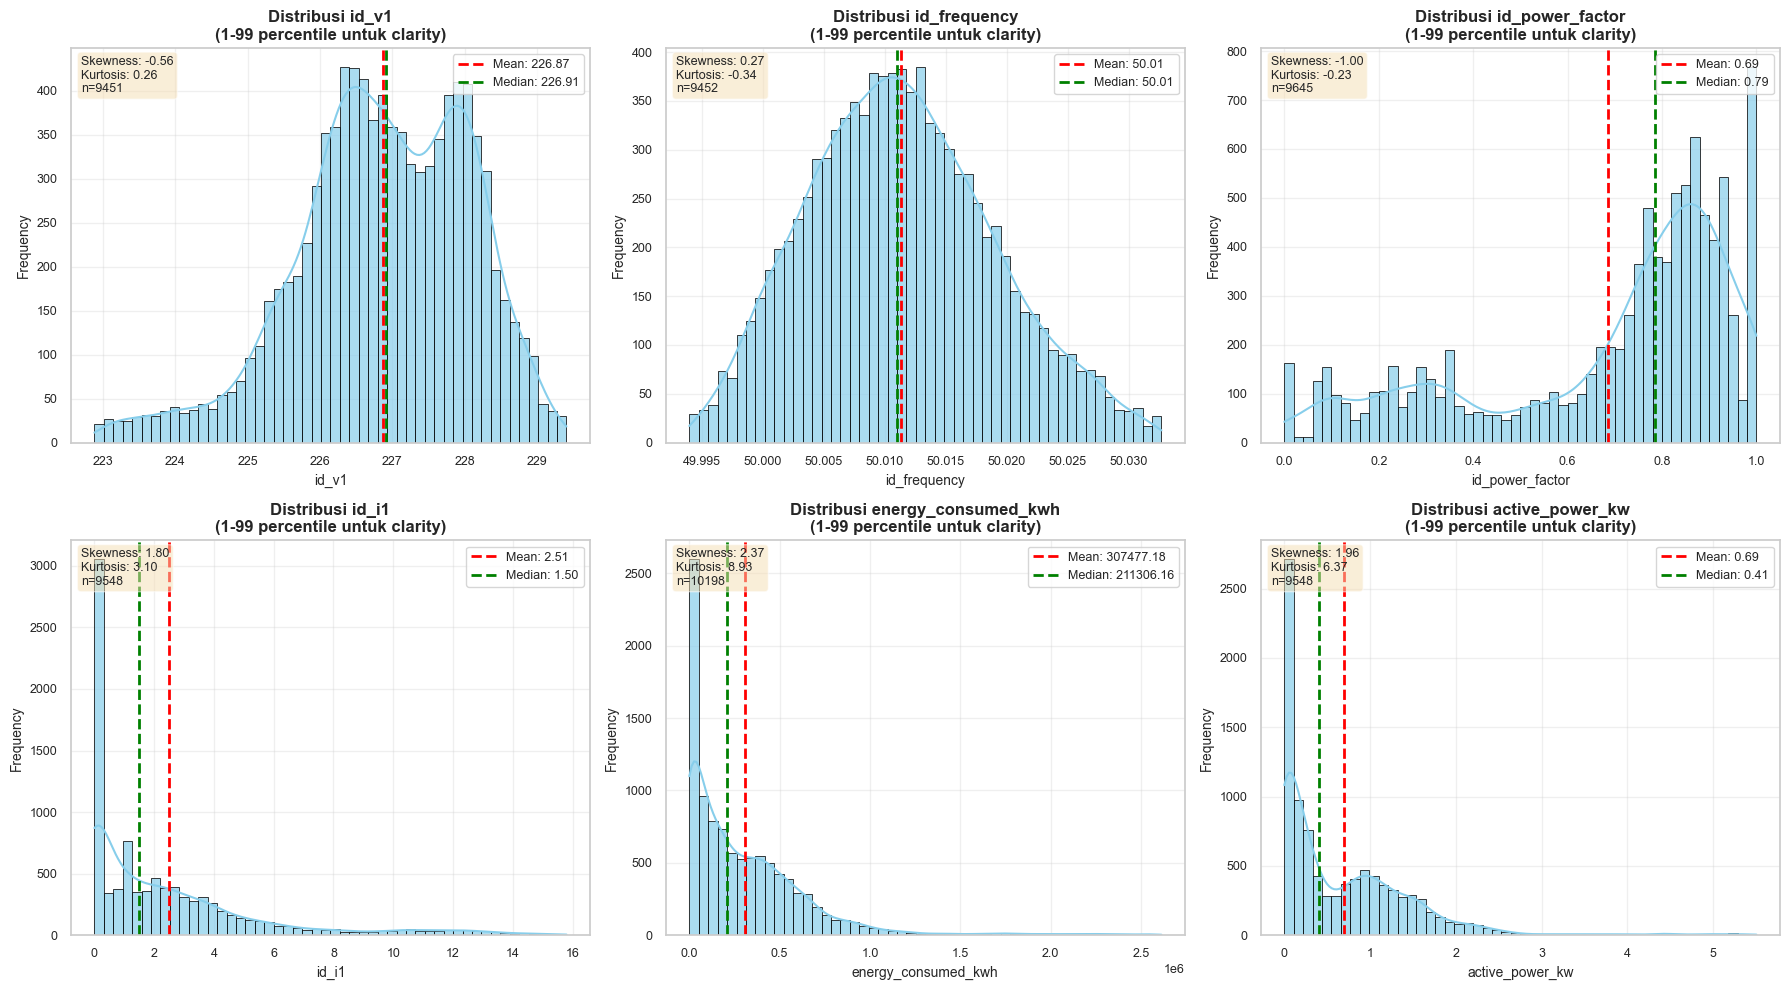


✅ Visualisasi histogram selesai!


In [63]:
# ==========================================
# 4.3 VISUALISASI DISTRIBUSI - HISTOGRAM + KDE
# ==========================================

print("\n📊 VISUALISASI DISTRIBUSI (HISTOGRAM + KDE)")
print("=" * 80)

# Pilih variabel kunci untuk visualisasi
viz_cols = [
    'id_v1', 'id_frequency', 'id_power_factor', 
    'id_i1', 'energy_consumed_kwh', 'active_power_kw'
]
viz_cols = [col for col in viz_cols if col in df.columns]

# Create figure
n_cols = 3
n_rows = int(np.ceil(len(viz_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, col in enumerate(viz_cols):
    ax = axes[idx]
    
    # Remove outliers for better visualization (only for plotting)
    data_clean = df[col].dropna()
    q1 = data_clean.quantile(0.01)
    q99 = data_clean.quantile(0.99)
    data_viz = data_clean[(data_clean >= q1) & (data_clean <= q99)]
    
    # Plot histogram with KDE
    sns.histplot(data_viz, kde=True, bins=50, ax=ax, color='skyblue', 
                 edgecolor='black', alpha=0.7)
    
    # Add vertical lines for mean and median
    mean_val = data_viz.mean()
    median_val = data_viz.median()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    
    # Styling
    ax.set_title(f'Distribusi {col}\n(1-99 percentile untuk clarity)', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add text box with statistics
    skew = stats.skew(data_viz)
    kurt = stats.kurtosis(data_viz)
    textstr = f'Skewness: {skew:.2f}\nKurtosis: {kurt:.2f}\nn={len(data_viz)}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)

# Hide unused subplots
for idx in range(len(viz_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Visualisasi histogram selesai!")
print("=" * 80)


📊 Q-Q PLOTS - NORMALITY CHECK
Q-Q Plot membandingkan distribusi data dengan distribusi normal teoritis
Jika data mengikuti garis diagonal, maka data mendekati distribusi normal



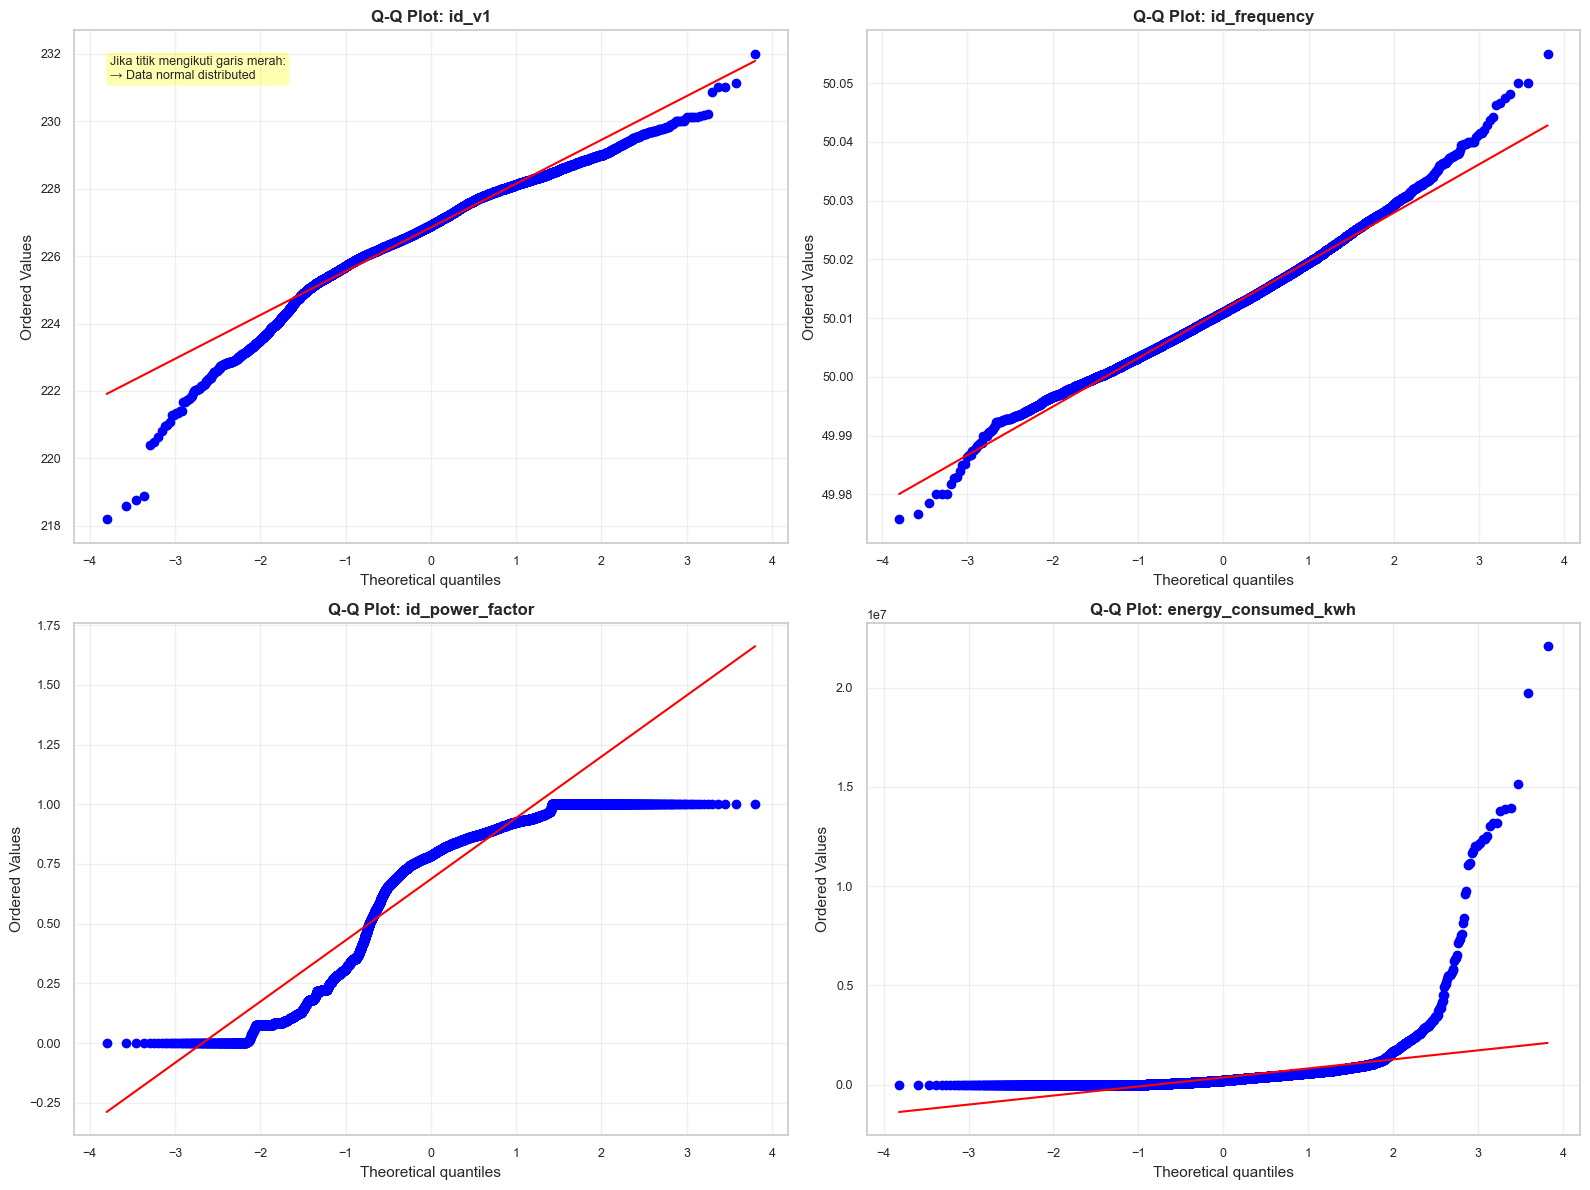

✅ Q-Q plots selesai!


In [64]:
# ==========================================
# 4.4 Q-Q PLOTS (QUANTILE-QUANTILE PLOTS)
# ==========================================

print("\n📊 Q-Q PLOTS - NORMALITY CHECK")
print("=" * 80)
print("Q-Q Plot membandingkan distribusi data dengan distribusi normal teoritis")
print("Jika data mengikuti garis diagonal, maka data mendekati distribusi normal\n")

# Pilih subset variabel untuk Q-Q plot
qq_cols = ['id_v1', 'id_frequency', 'id_power_factor', 'energy_consumed_kwh']
qq_cols = [col for col in qq_cols if col in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(qq_cols[:4]):  # Max 4 plots
    ax = axes[idx]
    
    # Get clean data
    data_clean = df[col].dropna()
    
    # Create Q-Q plot
    stats.probplot(data_clean, dist="norm", plot=ax)
    
    ax.set_title(f'Q-Q Plot: {col}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add interpretation text
    if idx == 0:
        interpretation = "Jika titik mengikuti garis merah:\n→ Data normal distributed"
    else:
        interpretation = ""
    
    if interpretation:
        ax.text(0.05, 0.95, interpretation, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

print("✅ Q-Q plots selesai!")
print("=" * 80)

In [65]:
# ==========================================
# 4.5 STATISTICAL NORMALITY TESTS
# ==========================================

print("\n🧪 UJI NORMALITAS STATISTIK")
print("=" * 80)

print("\n📖 METODE UJI:")
print("   • Shapiro-Wilk Test  : Powerful untuk sample < 5000")
print("   • D'Agostino K² Test : Based on skewness & kurtosis")
print("   • Anderson-Darling   : Distribution fit test")
print("   H0: Data berdistribusi normal | p-value < 0.05 → REJECT H0 (NOT normal)\n")

# Test variables
test_cols = ['id_v1', 'voltage_avg', 'id_frequency', 'id_power_factor', 
             'id_i1', 'current_avg', 'energy_consumed_kwh', 'active_power_kw']
test_cols = [col for col in test_cols if col in df.columns]

normality_results = []

for col in test_cols:
    data_clean = df[col].dropna()
    
    # Limit sample size for Shapiro test (max 5000)
    if len(data_clean) > 5000:
        data_sample = data_clean.sample(5000, random_state=42)
    else:
        data_sample = data_clean
    
    try:
        # Shapiro-Wilk Test
        shapiro_stat, shapiro_p = shapiro(data_sample)
        
        # D'Agostino K² Test
        dagostino_stat, dagostino_p = normaltest(data_clean)
        
        # Anderson-Darling Test
        anderson_result = stats.anderson(data_clean, dist='norm')
        anderson_stat = anderson_result.statistic
        anderson_critical = anderson_result.critical_values[2]  # 5% significance
        anderson_pass = 'Yes' if anderson_stat < anderson_critical else 'No'
        
        normality_results.append({
            'Variable': col,
            'Shapiro_Stat': shapiro_stat,
            'Shapiro_p': shapiro_p,
            'Shapiro_Normal': 'Yes' if shapiro_p > 0.05 else 'No',
            'DAgostino_Stat': dagostino_stat,
            'DAgostino_p': dagostino_p,
            'DAgostino_Normal': 'Yes' if dagostino_p > 0.05 else 'No',
            'Anderson_Stat': anderson_stat,
            'Anderson_Critical_5%': anderson_critical,
            'Anderson_Normal': anderson_pass,
            'n': len(data_clean)
        })
        
    except Exception as e:
        print(f"   ⚠️  Error testing {col}: {str(e)}")

# Create results dataframe
normality_df = pd.DataFrame(normality_results)

print("📊 HASIL UJI NORMALITAS:")
display(normality_df)

# Summary
print("\n📌 SUMMARY:")
shapiro_normal = normality_df['Shapiro_Normal'].value_counts()
dagostino_normal = normality_df['DAgostino_Normal'].value_counts()

print(f"   Shapiro-Wilk  : {shapiro_normal.get('Yes', 0)}/{len(normality_df)} variabel normal")
print(f"   D'Agostino K² : {dagostino_normal.get('Yes', 0)}/{len(normality_df)} variabel normal")

# List non-normal variables
non_normal = normality_df[normality_df['Shapiro_Normal'] == 'No']['Variable'].tolist()
if non_normal:
    print(f"\n   ⚠️  Variabel NON-NORMAL: {', '.join(non_normal)}")
else:
    print(f"\n   ✅ Semua variabel berdistribusi normal!")

print("\n" + "=" * 80)


🧪 UJI NORMALITAS STATISTIK

📖 METODE UJI:
   • Shapiro-Wilk Test  : Powerful untuk sample < 5000
   • D'Agostino K² Test : Based on skewness & kurtosis
   • Anderson-Darling   : Distribution fit test
   H0: Data berdistribusi normal | p-value < 0.05 → REJECT H0 (NOT normal)

📊 HASIL UJI NORMALITAS:


,Variable,Shapiro_Stat,Shapiro_p,Shapiro_Normal,DAgostino_Stat,DAgostino_p,DAgostino_Normal,Anderson_Stat,Anderson_Critical_5%,Anderson_Normal,n
0,id_v1,0.97,4.02e-33,No,1154.68,1.84e-251,No,54.28,0.79,No,9645
1,voltage_avg,0.96,1.12e-34,No,1242.70,1.42e-270,No,61.36,0.79,No,9645
2,id_frequency,0.99,1.86e-15,No,255.23,3.78e-56,No,14.28,0.79,No,9645
3,id_power_factor,0.86,3.55e-55,No,1162.35,3.98e-253,No,512.48,0.79,No,9645
4,id_i1,0.39,1.71e-84,No,15384.49,0.00e+00,No,1133.65,0.79,No,9645
5,current_avg,0.31,3.22e-87,No,17082.65,0.00e+00,No,1255.26,0.79,No,9645
6,energy_consumed_kwh,0.34,2.94e-86,No,17779.36,0.00e+00,No,1499.41,0.79,No,10301
7,active_power_kw,0.30,9.61e-88,No,17145.61,0.00e+00,No,1370.00,0.79,No,9645



📌 SUMMARY:
   Shapiro-Wilk  : 0/8 variabel normal
   D'Agostino K² : 0/8 variabel normal

   ⚠️  Variabel NON-NORMAL: id_v1, voltage_avg, id_frequency, id_power_factor, id_i1, current_avg, energy_consumed_kwh, active_power_kw




📦 BOXPLOTS - DETEKSI OUTLIERS


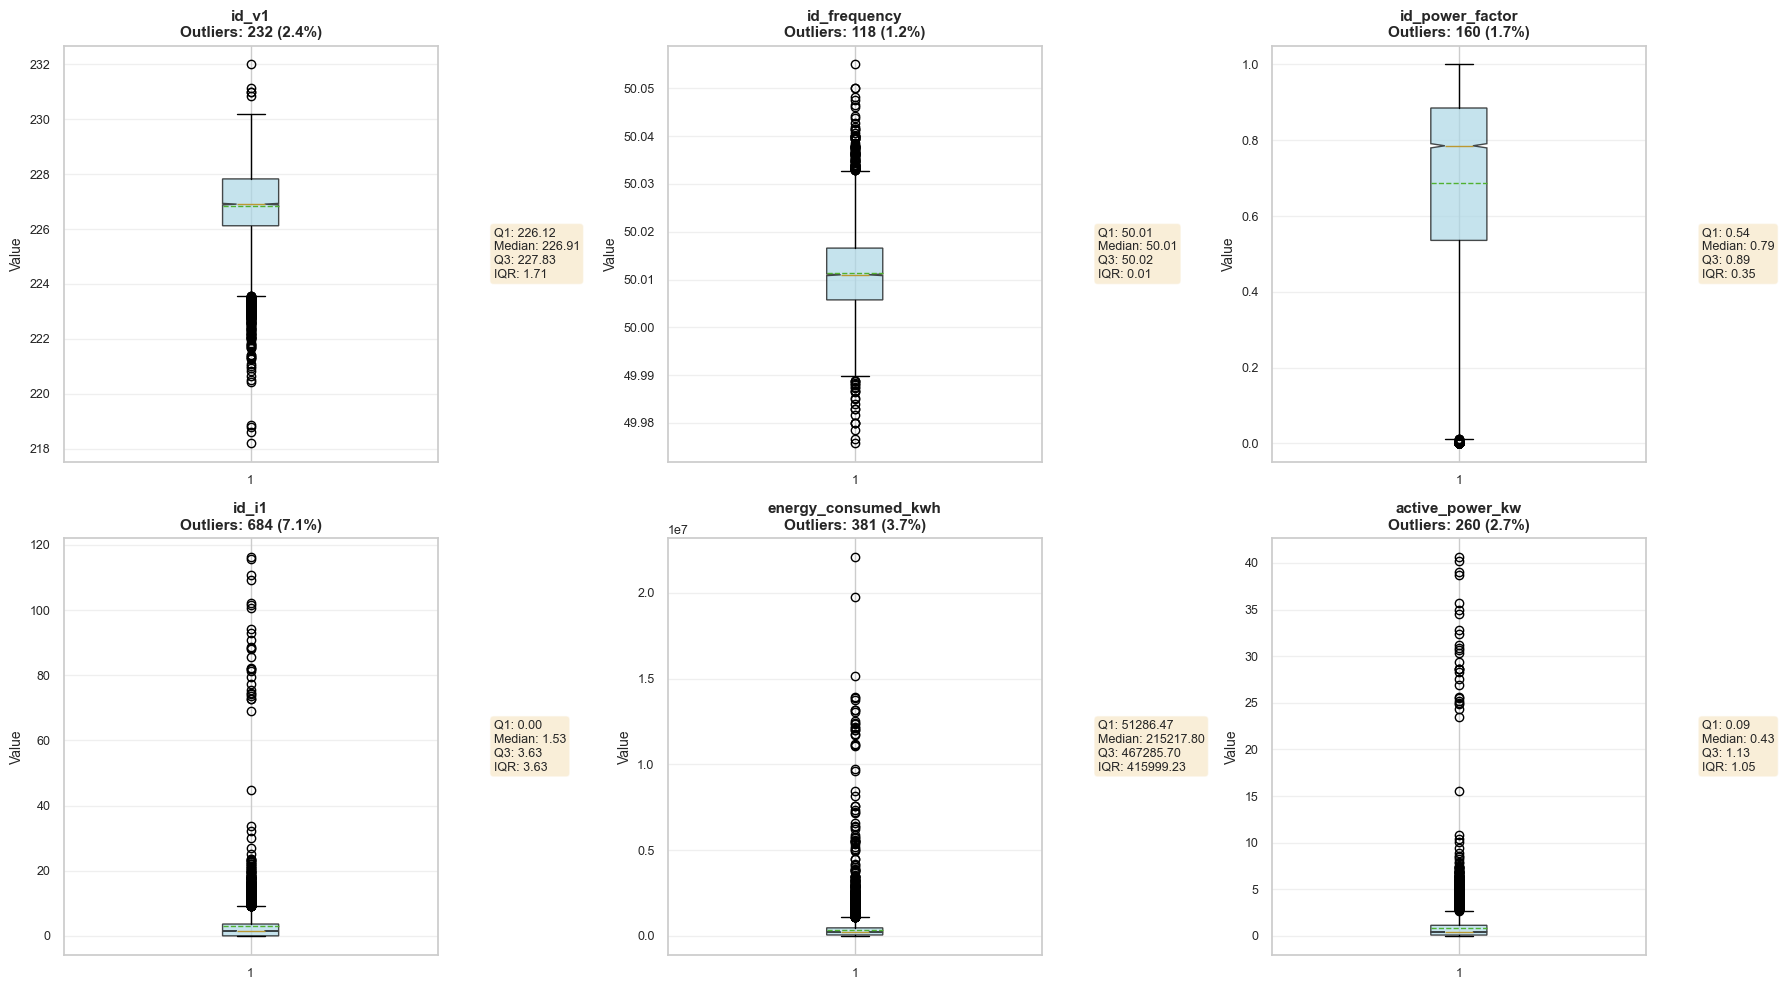


📊 SUMMARY OUTLIERS (IQR Method):


,Variable,Total_Data,Outliers_Count,Outliers_Pct,Lower_Bound,Upper_Bound
0,id_v1,9645,232,2.41,223.56,2.30e+02
1,id_frequency,9645,118,1.22,49.99,5.00e+01
2,id_power_factor,9645,160,1.66,0.01,1.41e+00
3,id_i1,9645,684,7.09,-5.45,9.09e+00
4,energy_consumed_kwh,10301,381,3.70,-572712.38,1.09e+06
5,active_power_kw,9645,260,2.70,-1.48,2.70e+00



📖 INTERPRETASI:
   • Outliers = Data di luar [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
   • Boxplot menunjukkan distribusi dan outliers secara visual
   • Notch (lekukan) menunjukkan confidence interval median



In [66]:
# ==========================================
# 4.6 BOXPLOTS - OUTLIER DETECTION
# ==========================================

print("\n📦 BOXPLOTS - DETEKSI OUTLIERS")
print("=" * 80)

# Pilih variabel untuk boxplot
box_cols = ['id_v1', 'id_frequency', 'id_power_factor', 
            'id_i1', 'energy_consumed_kwh', 'active_power_kw']
box_cols = [col for col in box_cols if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

outlier_summary = []

for idx, col in enumerate(box_cols):
    ax = axes[idx]
    
    data_clean = df[col].dropna()
    
    # Calculate outliers using IQR method
    q1 = data_clean.quantile(0.25)
    q3 = data_clean.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data_clean[(data_clean < lower_bound) | (data_clean > upper_bound)]
    outlier_pct = len(outliers) / len(data_clean) * 100
    
    outlier_summary.append({
        'Variable': col,
        'Total_Data': len(data_clean),
        'Outliers_Count': len(outliers),
        'Outliers_Pct': outlier_pct,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })
    
    # Create boxplot
    bp = ax.boxplot(data_clean, vert=True, patch_artist=True, 
                    notch=True, showmeans=True, meanline=True)
    
    # Color the box
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    # Styling
    ax.set_title(f'{col}\nOutliers: {len(outliers)} ({outlier_pct:.1f}%)', 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistical annotations
    textstr = f'Q1: {q1:.2f}\nMedian: {data_clean.median():.2f}\nQ3: {q3:.2f}\nIQR: {iqr:.2f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(1.15, 0.5, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='center', bbox=props)

plt.tight_layout()
plt.show()

# Display outlier summary
outlier_summary_df = pd.DataFrame(outlier_summary)
print("\n📊 SUMMARY OUTLIERS (IQR Method):")
display(outlier_summary_df.round(2))

print("\n📖 INTERPRETASI:")
print("   • Outliers = Data di luar [Q1 - 1.5×IQR, Q3 + 1.5×IQR]")
print("   • Boxplot menunjukkan distribusi dan outliers secara visual")
print("   • Notch (lekukan) menunjukkan confidence interval median")

print("\n" + "=" * 80)


📊 DISTRIBUSI PER GROUP BEBAN

🔍 Analisis distribusi 'energy_consumed_kwh' per group beban



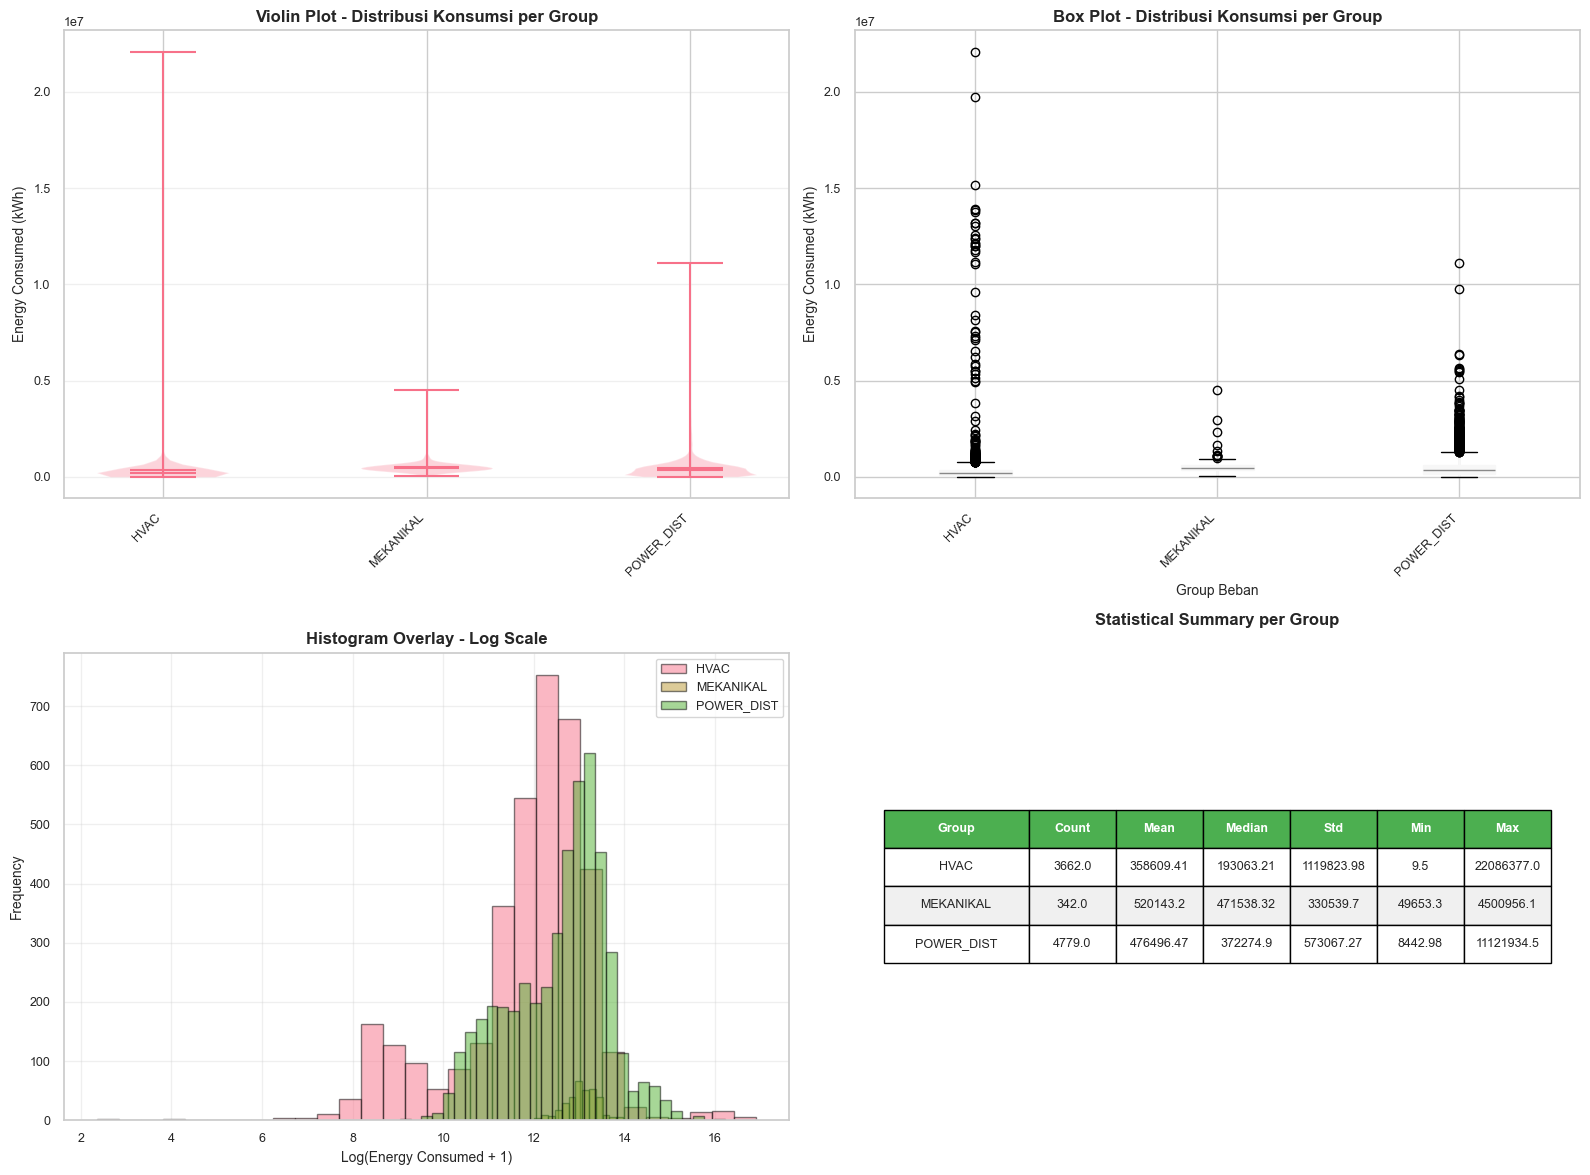

✅ Visualisasi distribusi per group selesai!

🧪 UJI STATISTIK ANTAR GROUP (ANOVA):
   H0: Semua group memiliki mean yang sama

   F-statistic: 22.5026
   p-value: 1.7873e-10
   ✅ REJECT H0: Ada perbedaan signifikan antar group (p < 0.05)



In [67]:
# ==========================================
# 4.7 DISTRIBUSI PER GROUP BEBAN
# ==========================================

print("\n📊 DISTRIBUSI PER GROUP BEBAN")
print("=" * 80)

if 'group_beban' in df.columns:
    # Pilih variabel untuk analisis per group
    group_var = 'energy_consumed_kwh'  # Fokus pada konsumsi energi
    
    if group_var in df.columns:
        print(f"\n🔍 Analisis distribusi '{group_var}' per group beban\n")
        
        # Filter data valid (positive consumption)
        df_group = df[df[group_var] > 0].copy()
        
        # Create figure
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Violin plot per group
        ax1 = axes[0, 0]
        groups = df_group['group_beban'].unique()
        data_violin = [df_group[df_group['group_beban'] == g][group_var].dropna() for g in groups]
        
        parts = ax1.violinplot(data_violin, positions=range(len(groups)), 
                               showmeans=True, showmedians=True)
        ax1.set_xticks(range(len(groups)))
        ax1.set_xticklabels(groups, rotation=45, ha='right')
        ax1.set_title('Violin Plot - Distribusi Konsumsi per Group', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Energy Consumed (kWh)', fontsize=10)
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Plot 2: Box plot per group
        ax2 = axes[0, 1]
        df_group.boxplot(column=group_var, by='group_beban', ax=ax2, patch_artist=True)
        ax2.set_title('Box Plot - Distribusi Konsumsi per Group', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Group Beban', fontsize=10)
        ax2.set_ylabel('Energy Consumed (kWh)', fontsize=10)
        ax2.get_figure().suptitle('')  # Remove automatic title
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Plot 3: Histogram overlaid per group
        ax3 = axes[1, 0]
        for group in groups:
            data = df_group[df_group['group_beban'] == group][group_var]
            # Use log scale for better visualization if high variance
            data_log = np.log1p(data)  # log(1+x) to handle zeros
            ax3.hist(data_log, bins=30, alpha=0.5, label=group, edgecolor='black')
        
        ax3.set_title('Histogram Overlay - Log Scale', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Log(Energy Consumed + 1)', fontsize=10)
        ax3.set_ylabel('Frequency', fontsize=10)
        ax3.legend(loc='upper right', fontsize=9)
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Statistical summary table
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        # Calculate statistics per group
        group_stats = df_group.groupby('group_beban')[group_var].agg([
            ('Count', 'count'),
            ('Mean', 'mean'),
            ('Median', 'median'),
            ('Std', 'std'),
            ('Min', 'min'),
            ('Max', 'max')
        ]).round(2)
        
        # Create table
        table_data = []
        table_data.append(['Group', 'Count', 'Mean', 'Median', 'Std', 'Min', 'Max'])
        for idx, row in group_stats.iterrows():
            table_data.append([idx] + row.tolist())
        
        table = ax4.table(cellText=table_data, cellLoc='center', loc='center',
                         colWidths=[0.2, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12])
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)
        
        # Style header row
        for i in range(7):
            table[(0, i)].set_facecolor('#4CAF50')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Alternate row colors
        for i in range(1, len(table_data)):
            color = '#f0f0f0' if i % 2 == 0 else 'white'
            for j in range(7):
                table[(i, j)].set_facecolor(color)
        
        ax4.set_title('Statistical Summary per Group', fontsize=12, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Visualisasi distribusi per group selesai!")
        
        # Statistical comparison between groups
        print("\n🧪 UJI STATISTIK ANTAR GROUP (ANOVA):")
        print("   H0: Semua group memiliki mean yang sama\n")
        
        groups_data = [df_group[df_group['group_beban'] == g][group_var].dropna() for g in groups]
        f_stat, p_value = stats.f_oneway(*groups_data)
        
        print(f"   F-statistic: {f_stat:.4f}")
        print(f"   p-value: {p_value:.4e}")
        
        if p_value < 0.05:
            print(f"   ✅ REJECT H0: Ada perbedaan signifikan antar group (p < 0.05)")
        else:
            print(f"   ❌ FAIL TO REJECT H0: Tidak ada perbedaan signifikan (p >= 0.05)")
    
    else:
        print(f"⚠️  Variabel '{group_var}' tidak ditemukan dalam dataset")
else:
    print("⚠️  Kolom 'group_beban' tidak ditemukan")

print("\n" + "=" * 80)


⚡ ANALISIS KHUSUS - PARAMETER ELEKTRIKAL

📖 EXPECTED BEHAVIOR:
   • Voltage (V)    : ~220V ± 10% (198-242V) - Should be VERY stable
   • Frequency (Hz) : ~50Hz ± 0.5Hz (49.5-50.5Hz) - EXTREMELY stable
   • Power Factor   : 0.85-1.00 - Higher is better (>0.95 excellent)
   • Current (A)    : Variable based on load



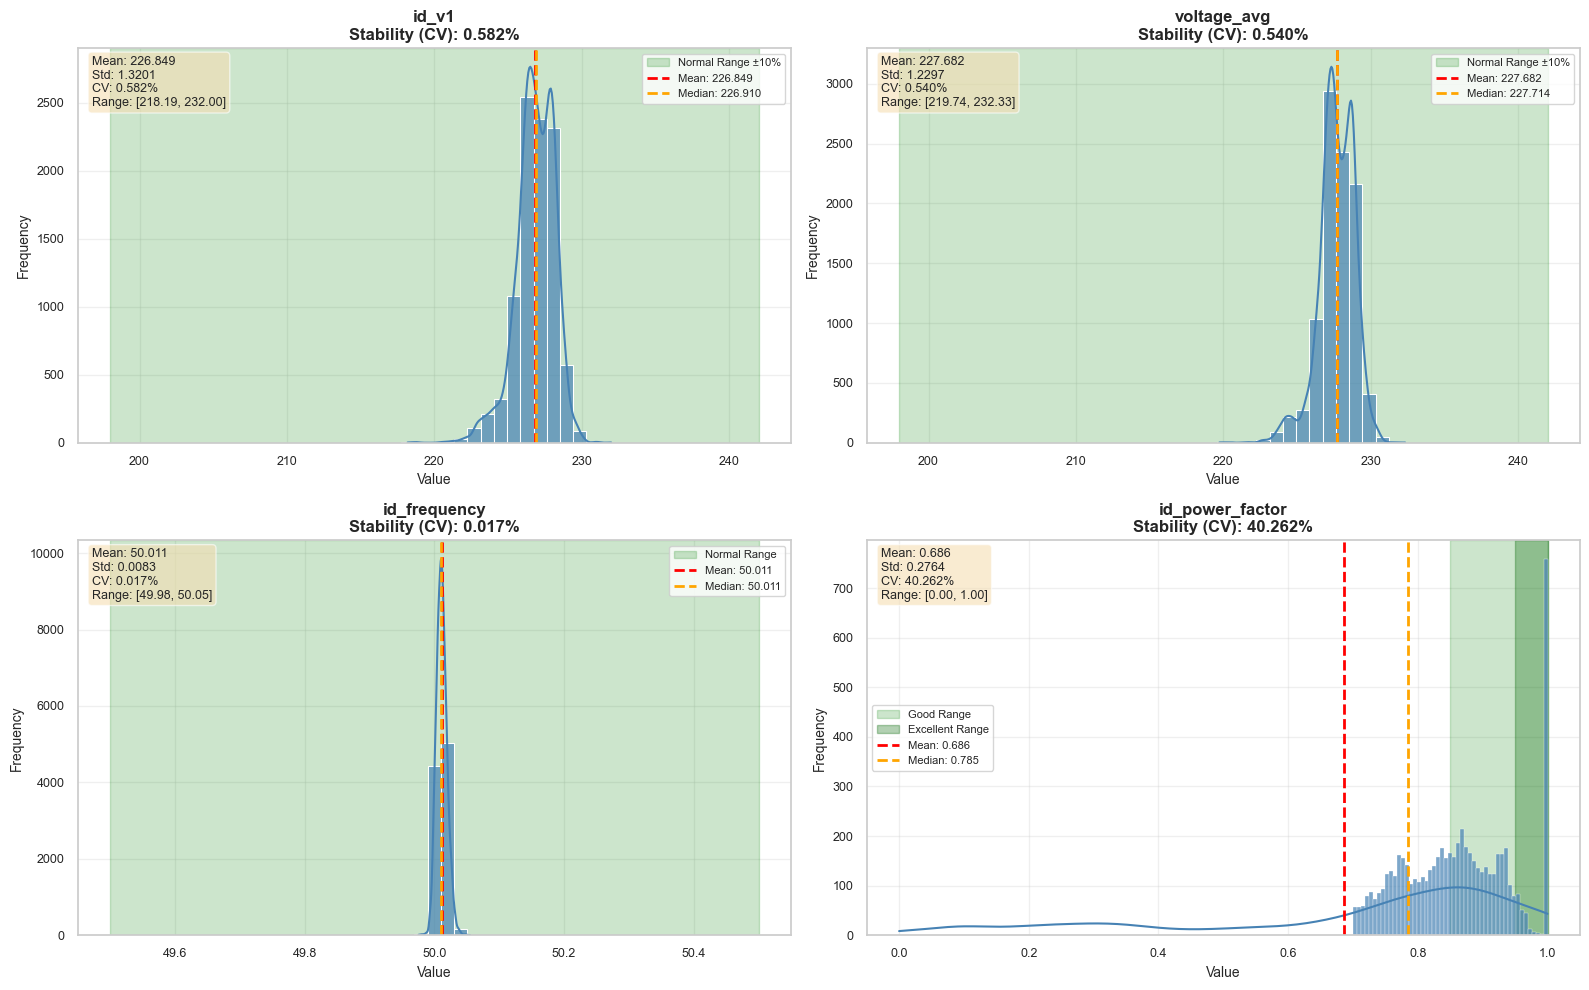


⚠️  ANOMALI & VIOLATIONS:
   • Poor power factor (<0.85): 6220 records (60.4%)



In [68]:
# ==========================================
# 4.8 ANALISIS DISTRIBUSI PARAMETER ELEKTRIKAL
# ==========================================

print("\n⚡ ANALISIS KHUSUS - PARAMETER ELEKTRIKAL")
print("=" * 80)

print("\n📖 EXPECTED BEHAVIOR:")
print("   • Voltage (V)    : ~220V ± 10% (198-242V) - Should be VERY stable")
print("   • Frequency (Hz) : ~50Hz ± 0.5Hz (49.5-50.5Hz) - EXTREMELY stable")
print("   • Power Factor   : 0.85-1.00 - Higher is better (>0.95 excellent)")
print("   • Current (A)    : Variable based on load\n")

# Analyze electrical parameters
electrical_params = ['id_v1', 'voltage_avg', 'id_frequency', 'id_power_factor']
electrical_params = [col for col in electrical_params if col in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(electrical_params):
    ax = axes[idx]
    
    data_clean = df[col].dropna()
    
    # Create histogram with narrower bins for electrical parameters
    if 'frequency' in col.lower():
        bins = np.linspace(49.5, 50.5, 50)
        ax.axvspan(49.5, 50.5, alpha=0.2, color='green', label='Normal Range')
    elif 'voltage' in col.lower() or col == 'id_v1':
        bins = np.linspace(198, 242, 50)
        ax.axvspan(198, 242, alpha=0.2, color='green', label='Normal Range ±10%')
    elif 'power_factor' in col.lower():
        bins = np.linspace(0.7, 1.0, 50)
        ax.axvspan(0.85, 1.0, alpha=0.2, color='green', label='Good Range')
        ax.axvspan(0.95, 1.0, alpha=0.3, color='darkgreen', label='Excellent Range')
    else:
        bins = 50
    
    sns.histplot(data_clean, bins=bins, kde=True, ax=ax, color='steelblue', alpha=0.7)
    
    # Add mean and median lines
    mean_val = data_clean.mean()
    median_val = data_clean.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.3f}')
    
    # Calculate stability (coefficient of variation)
    cv = (data_clean.std() / data_clean.mean() * 100)
    
    ax.set_title(f'{col}\nStability (CV): {cv:.3f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Add statistics box
    textstr = f'Mean: {mean_val:.3f}\nStd: {data_clean.std():.4f}\nCV: {cv:.3f}%\nRange: [{data_clean.min():.2f}, {data_clean.max():.2f}]'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.6)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Check for violations
print("\n⚠️  ANOMALI & VIOLATIONS:")
violations = []

if 'voltage_avg' in df.columns:
    low_v = (df['voltage_avg'] < 198).sum()
    high_v = (df['voltage_avg'] > 242).sum()
    if low_v + high_v > 0:
        violations.append(f"   • Voltage violations: {low_v} low, {high_v} high")

if 'id_frequency' in df.columns:
    low_f = (df['id_frequency'] < 49.5).sum()
    high_f = (df['id_frequency'] > 50.5).sum()
    if low_f + high_f > 0:
        violations.append(f"   • Frequency violations: {low_f} low, {high_f} high")

if 'id_power_factor' in df.columns:
    low_pf = (df['id_power_factor'] < 0.85).sum()
    if low_pf > 0:
        violations.append(f"   • Poor power factor (<0.85): {low_pf} records ({low_pf/len(df)*100:.1f}%)")

if violations:
    for v in violations:
        print(v)
else:
    print("   ✅ Tidak ada violations terdeteksi - Semua parameter dalam rentang normal!")

print("\n" + "=" * 80)

In [69]:
# ==========================================
# 4.9 SUMMARY REPORT - DISTRIBUTION ANALYSIS
# ==========================================

print("\n📋 SUMMARY REPORT - ANALISIS DISTRIBUSI")
print("=" * 80)

print("\n1️⃣  NORMALITY TEST RESULTS:")
if 'normality_df' in locals():
    normal_count = (normality_df['Shapiro_Normal'] == 'Yes').sum()
    print(f"   • {normal_count}/{len(normality_df)} variabel berdistribusi normal (Shapiro-Wilk test)")
    print(f"   • Mayoritas variabel smart meter: NON-NORMAL (expected behavior)")

print("\n2️⃣  DISTRIBUTION CHARACTERISTICS:")
print("   • Voltage & Frequency: Sangat stabil (unimodal, narrow distribution)")
print("   • Current & Power: Variable, tergantung beban operasional")
print("   • Energy Consumption: Right-skewed (banyak nilai rendah, sedikit nilai tinggi)")
print("   • Power Factor: Mayoritas tinggi (0.85-1.0), beberapa outliers rendah")

print("\n3️⃣  OUTLIERS DETECTION:")
if 'outlier_summary_df' in locals():
    total_outliers = outlier_summary_df['Outliers_Count'].sum()
    avg_outlier_pct = outlier_summary_df['Outliers_Pct'].mean()
    print(f"   • Total outliers terdeteksi: {int(total_outliers)}")
    print(f"   • Rata-rata outliers per variabel: {avg_outlier_pct:.2f}%")
    
    # Variabel dengan outliers terbanyak
    max_outlier_var = outlier_summary_df.loc[outlier_summary_df['Outliers_Pct'].idxmax()]
    print(f"   • Variabel dengan outliers terbanyak: {max_outlier_var['Variable']} ({max_outlier_var['Outliers_Pct']:.1f}%)")

print("\n4️⃣  ELECTRICAL PARAMETERS STABILITY:")
if 'voltage_avg' in df.columns:
    voltage_cv = (df['voltage_avg'].std() / df['voltage_avg'].mean() * 100)
    print(f"   • Voltage Stability (CV): {voltage_cv:.3f}% {'✅ Excellent' if voltage_cv < 1 else '⚠️ Check'}")

if 'id_frequency' in df.columns:
    freq_cv = (df['id_frequency'].std() / df['id_frequency'].mean() * 100)
    print(f"   • Frequency Stability (CV): {freq_cv:.3f}% {'✅ Excellent' if freq_cv < 0.5 else '⚠️ Check'}")

if 'id_power_factor' in df.columns:
    avg_pf = df['id_power_factor'].mean()
    poor_pf_pct = ((df['id_power_factor'] < 0.85).sum() / len(df) * 100)
    print(f"   • Average Power Factor: {avg_pf:.3f} {'✅ Good' if avg_pf > 0.90 else '⚠️ Fair'}")
    print(f"   • Records with poor PF (<0.85): {poor_pf_pct:.1f}%")

print("\n5️⃣  CONSUMPTION PATTERNS:")
if 'energy_consumed_kwh' in df.columns:
    energy_data = df['energy_consumed_kwh']
    zero_consumption = (energy_data == 0).sum()
    zero_pct = (zero_consumption / len(energy_data) * 100)
    
    print(f"   • Zero consumption records: {zero_consumption} ({zero_pct:.1f}%)")
    print(f"   • Mean consumption: {energy_data.mean():.3f} kWh")
    print(f"   • Median consumption: {energy_data.median():.3f} kWh")
    print(f"   • Max consumption: {energy_data.max():.3f} kWh")
    
    # Skewness interpretation
    skew = stats.skew(energy_data.dropna())
    if skew > 1:
        skew_interp = "Highly right-skewed (banyak konsumsi rendah)"
    elif skew > 0:
        skew_interp = "Moderately right-skewed"
    else:
        skew_interp = "Left-skewed atau symmetrical"
    print(f"   • Distribution shape: {skew_interp} (skewness={skew:.2f})")

print("\n6️⃣  GROUP BEBAN COMPARISON:")
if 'group_beban' in df.columns and 'energy_consumed_kwh' in df.columns:
    group_energy = df.groupby('group_beban')['energy_consumed_kwh'].agg(['sum', 'mean', 'count'])
    top_group = group_energy['sum'].idxmax()
    top_group_pct = (group_energy.loc[top_group, 'sum'] / group_energy['sum'].sum() * 100)
    
    print(f"   • Group dengan konsumsi terbesar: {top_group}")
    print(f"   • Kontribusi: {top_group_pct:.1f}% dari total konsumsi")
    print(f"   • Jumlah group teridentifikasi: {len(group_energy)}")

print("\n" + "=" * 80)


📋 SUMMARY REPORT - ANALISIS DISTRIBUSI

1️⃣  NORMALITY TEST RESULTS:
   • 0/8 variabel berdistribusi normal (Shapiro-Wilk test)
   • Mayoritas variabel smart meter: NON-NORMAL (expected behavior)

2️⃣  DISTRIBUTION CHARACTERISTICS:
   • Voltage & Frequency: Sangat stabil (unimodal, narrow distribution)
   • Current & Power: Variable, tergantung beban operasional
   • Energy Consumption: Right-skewed (banyak nilai rendah, sedikit nilai tinggi)
   • Power Factor: Mayoritas tinggi (0.85-1.0), beberapa outliers rendah

3️⃣  OUTLIERS DETECTION:
   • Total outliers terdeteksi: 1835
   • Rata-rata outliers per variabel: 3.13%
   • Variabel dengan outliers terbanyak: id_i1 (7.1%)

4️⃣  ELECTRICAL PARAMETERS STABILITY:
   • Voltage Stability (CV): 0.540% ✅ Excellent
   • Frequency Stability (CV): 0.017% ✅ Excellent
   • Average Power Factor: 0.686 ⚠️ Fair
   • Records with poor PF (<0.85): 60.4%

5️⃣  CONSUMPTION PATTERNS:
   • Zero consumption records: 1518 (14.7%)
   • Mean consumption: 3658


📊 COMPREHENSIVE DISTRIBUTION DASHBOARD


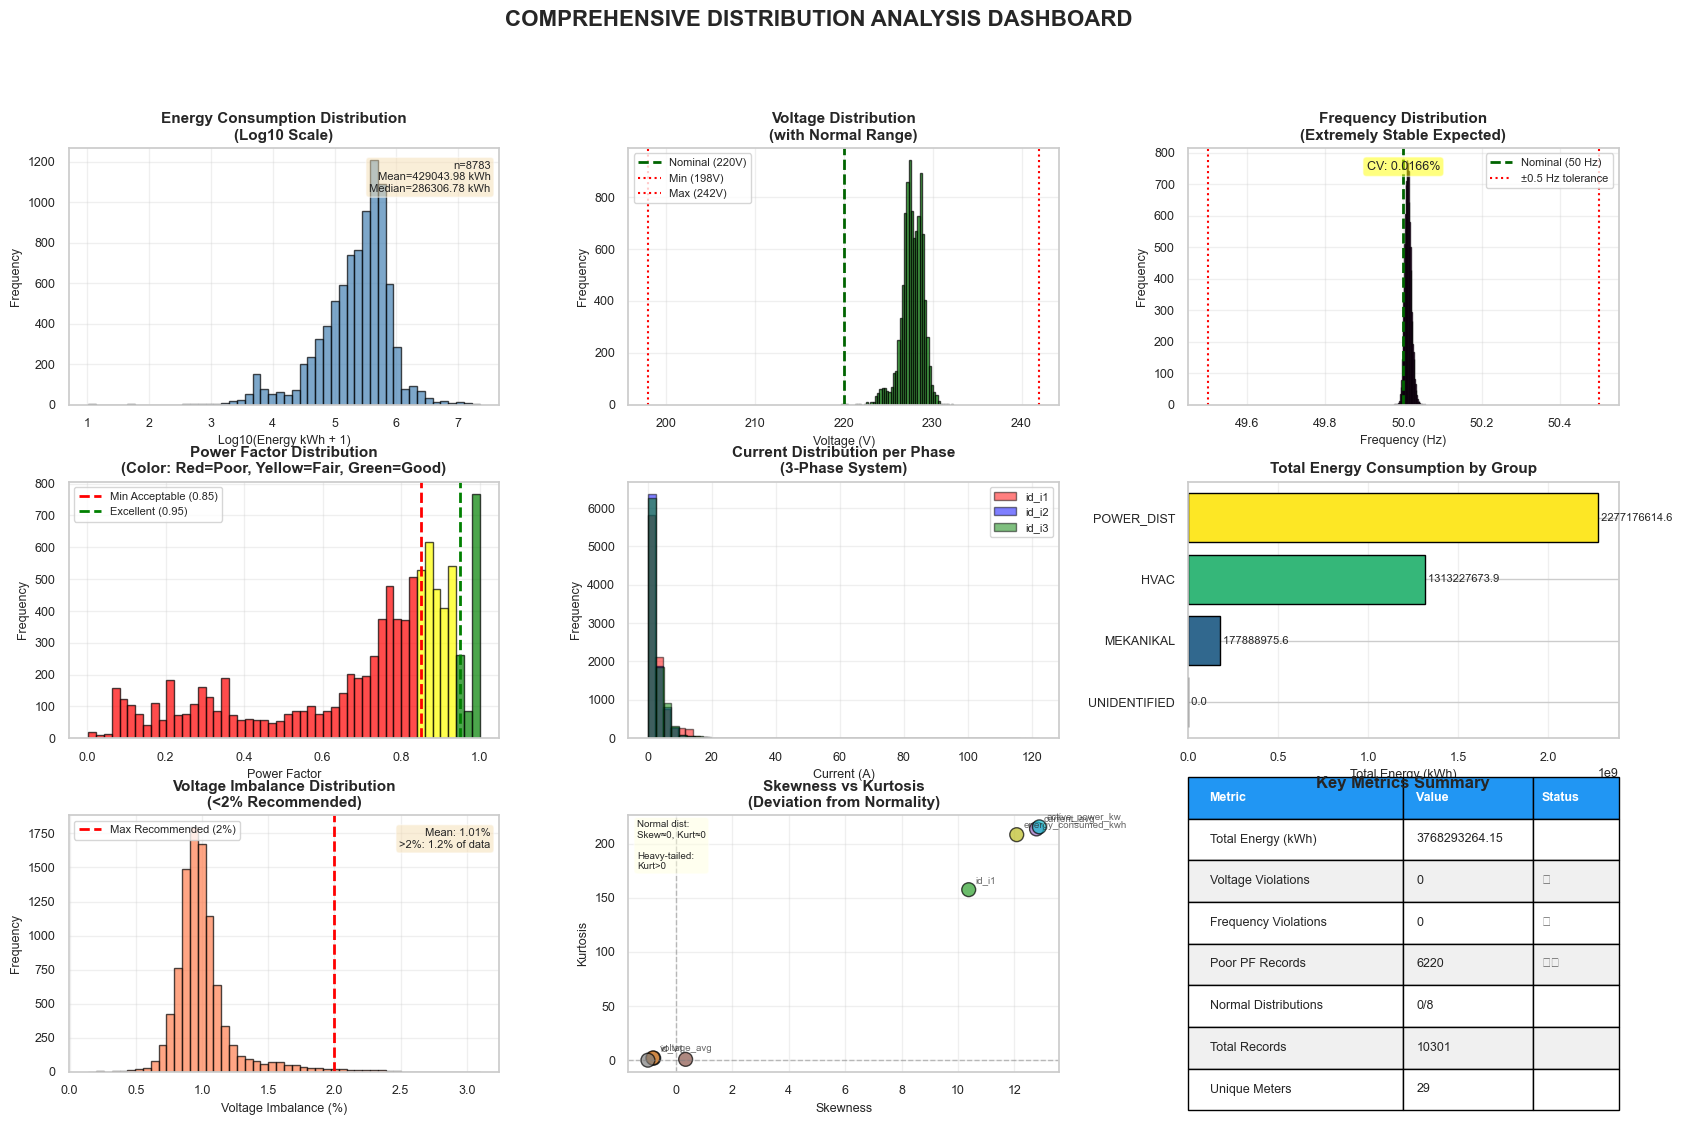


✅ Comprehensive dashboard selesai!


In [70]:
# ==========================================
# 4.10 VISUALISASI COMPREHENSIVE - DASHBOARD
# ==========================================

print("\n📊 COMPREHENSIVE DISTRIBUTION DASHBOARD")
print("=" * 80)

# Create a comprehensive dashboard
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# --- PLOT 1: Energy Consumption Distribution ---
ax1 = fig.add_subplot(gs[0, 0])
if 'energy_consumed_kwh' in df.columns:
    energy_positive = df[df['energy_consumed_kwh'] > 0]['energy_consumed_kwh']
    
    # Use log scale for better visualization
    energy_log = np.log10(energy_positive + 1)
    
    ax1.hist(energy_log, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_title('Energy Consumption Distribution\n(Log10 Scale)', fontweight='bold', fontsize=11)
    ax1.set_xlabel('Log10(Energy kWh + 1)', fontsize=9)
    ax1.set_ylabel('Frequency', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Add statistics
    textstr = f'n={len(energy_positive)}\nMean={energy_positive.mean():.2f} kWh\nMedian={energy_positive.median():.2f} kWh'
    ax1.text(0.98, 0.95, textstr, transform=ax1.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- PLOT 2: Voltage Distribution ---
ax2 = fig.add_subplot(gs[0, 1])
if 'voltage_avg' in df.columns:
    voltage_data = df['voltage_avg'].dropna()
    
    n, bins, patches = ax2.hist(voltage_data, bins=50, color='orange', edgecolor='black', alpha=0.7)
    
    # Color code based on normal range
    for i, patch in enumerate(patches):
        bin_center = (bins[i] + bins[i+1]) / 2
        if 198 <= bin_center <= 242:
            patch.set_facecolor('green')
            patch.set_alpha(0.7)
        else:
            patch.set_facecolor('red')
            patch.set_alpha(0.7)
    
    # Add normal range lines
    ax2.axvline(220, color='darkgreen', linestyle='--', linewidth=2, label='Nominal (220V)')
    ax2.axvline(198, color='red', linestyle=':', linewidth=1.5, label='Min (198V)')
    ax2.axvline(242, color='red', linestyle=':', linewidth=1.5, label='Max (242V)')
    
    ax2.set_title('Voltage Distribution\n(with Normal Range)', fontweight='bold', fontsize=11)
    ax2.set_xlabel('Voltage (V)', fontsize=9)
    ax2.set_ylabel('Frequency', fontsize=9)
    ax2.legend(fontsize=8, loc='upper left')
    ax2.grid(True, alpha=0.3)

# --- PLOT 3: Frequency Distribution ---
ax3 = fig.add_subplot(gs[0, 2])
if 'id_frequency' in df.columns:
    freq_data = df['id_frequency'].dropna()
    
    ax3.hist(freq_data, bins=50, color='purple', edgecolor='black', alpha=0.7)
    ax3.axvline(50, color='darkgreen', linestyle='--', linewidth=2, label='Nominal (50 Hz)')
    ax3.axvline(49.5, color='red', linestyle=':', linewidth=1.5, label='±0.5 Hz tolerance')
    ax3.axvline(50.5, color='red', linestyle=':', linewidth=1.5)
    
    ax3.set_title('Frequency Distribution\n(Extremely Stable Expected)', fontweight='bold', fontsize=11)
    ax3.set_xlabel('Frequency (Hz)', fontsize=9)
    ax3.set_ylabel('Frequency', fontsize=9)
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # Add CV annotation
    freq_cv = (freq_data.std() / freq_data.mean() * 100)
    ax3.text(0.5, 0.95, f'CV: {freq_cv:.4f}%', transform=ax3.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# --- PLOT 4: Power Factor Distribution ---
ax4 = fig.add_subplot(gs[1, 0])
if 'id_power_factor' in df.columns:
    pf_data = df[(df['id_power_factor'] > 0) & (df['id_power_factor'] <= 1)]['id_power_factor']
    
    n, bins, patches = ax4.hist(pf_data, bins=50, edgecolor='black', alpha=0.7)
    
    # Color code: green (0.95-1.0), yellow (0.85-0.95), red (<0.85)
    for i, patch in enumerate(patches):
        bin_center = (bins[i] + bins[i+1]) / 2
        if bin_center >= 0.95:
            patch.set_facecolor('green')
        elif bin_center >= 0.85:
            patch.set_facecolor('yellow')
        else:
            patch.set_facecolor('red')
    
    ax4.axvline(0.85, color='red', linestyle='--', linewidth=2, label='Min Acceptable (0.85)')
    ax4.axvline(0.95, color='green', linestyle='--', linewidth=2, label='Excellent (0.95)')
    
    ax4.set_title('Power Factor Distribution\n(Color: Red=Poor, Yellow=Fair, Green=Good)', 
                  fontweight='bold', fontsize=11)
    ax4.set_xlabel('Power Factor', fontsize=9)
    ax4.set_ylabel('Frequency', fontsize=9)
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

# --- PLOT 5: Current Distribution per Phase ---
ax5 = fig.add_subplot(gs[1, 1])
if all(col in df.columns for col in ['id_i1', 'id_i2', 'id_i3']):
    current_cols = ['id_i1', 'id_i2', 'id_i3']
    colors = ['red', 'blue', 'green']
    
    for col, color in zip(current_cols, colors):
        current_data = df[col].dropna()
        ax5.hist(current_data, bins=50, alpha=0.5, label=col, color=color, edgecolor='black')
    
    ax5.set_title('Current Distribution per Phase\n(3-Phase System)', fontweight='bold', fontsize=11)
    ax5.set_xlabel('Current (A)', fontsize=9)
    ax5.set_ylabel('Frequency', fontsize=9)
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3)

# --- PLOT 6: Energy Consumption by Group ---
ax6 = fig.add_subplot(gs[1, 2])
if 'group_beban' in df.columns and 'energy_consumed_kwh' in df.columns:
    group_energy = df.groupby('group_beban')['energy_consumed_kwh'].sum().sort_values(ascending=True)
    
    colors_group = plt.cm.viridis(np.linspace(0, 1, len(group_energy)))
    ax6.barh(range(len(group_energy)), group_energy.values, color=colors_group, edgecolor='black')
    ax6.set_yticks(range(len(group_energy)))
    ax6.set_yticklabels(group_energy.index, fontsize=9)
    ax6.set_title('Total Energy Consumption by Group', fontweight='bold', fontsize=11)
    ax6.set_xlabel('Total Energy (kWh)', fontsize=9)
    ax6.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, v in enumerate(group_energy.values):
        ax6.text(v, i, f' {v:.1f}', va='center', fontsize=8)

# --- PLOT 7: Voltage Imbalance Distribution ---
ax7 = fig.add_subplot(gs[2, 0])
if 'voltage_imbalance_pct' in df.columns:
    imb_data = df['voltage_imbalance_pct'].dropna()
    
    ax7.hist(imb_data, bins=50, color='coral', edgecolor='black', alpha=0.7)
    ax7.axvline(2, color='red', linestyle='--', linewidth=2, label='Max Recommended (2%)')
    
    ax7.set_title('Voltage Imbalance Distribution\n(<2% Recommended)', fontweight='bold', fontsize=11)
    ax7.set_xlabel('Voltage Imbalance (%)', fontsize=9)
    ax7.set_ylabel('Frequency', fontsize=9)
    ax7.legend(fontsize=8)
    ax7.grid(True, alpha=0.3)
    
    # Add statistics
    exceed_pct = ((imb_data > 2).sum() / len(imb_data) * 100)
    textstr = f'Mean: {imb_data.mean():.2f}%\n>2%: {exceed_pct:.1f}% of data'
    ax7.text(0.98, 0.95, textstr, transform=ax7.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- PLOT 8: Skewness & Kurtosis Comparison ---
ax8 = fig.add_subplot(gs[2, 1])
if 'stats_df' in locals() and len(stats_df) > 0:
    # Create scatter plot of skewness vs kurtosis
    scatter = ax8.scatter(stats_df['skewness'], stats_df['kurtosis'], 
                         s=100, c=range(len(stats_df)), cmap='tab10', 
                         edgecolor='black', alpha=0.7)
    
    # Add quadrant lines
    ax8.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax8.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add labels for some points
    for idx, row in stats_df.iterrows():
        if abs(row['skewness']) > 1 or abs(row['kurtosis']) > 1:
            ax8.annotate(row['Variable'], (row['skewness'], row['kurtosis']),
                        fontsize=7, alpha=0.7, xytext=(5, 5), 
                        textcoords='offset points')
    
    ax8.set_title('Skewness vs Kurtosis\n(Deviation from Normality)', fontweight='bold', fontsize=11)
    ax8.set_xlabel('Skewness', fontsize=9)
    ax8.set_ylabel('Kurtosis', fontsize=9)
    ax8.grid(True, alpha=0.3)
    
    # Add interpretation box
    textstr = 'Normal dist:\nSkew≈0, Kurt≈0\n\nHeavy-tailed:\nKurt>0'
    ax8.text(0.02, 0.98, textstr, transform=ax8.transAxes, fontsize=7,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# --- PLOT 9: Summary Statistics Table ---
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Create summary table
summary_data = []
summary_data.append(['Metric', 'Value', 'Status'])

# Add key metrics
if 'energy_consumed_kwh' in df.columns:
    total_energy = df['energy_consumed_kwh'].sum()
    summary_data.append(['Total Energy (kWh)', f'{total_energy:.2f}', ''])

if 'voltage_avg' in df.columns:
    v_violations = ((df['voltage_avg'] < 198) | (df['voltage_avg'] > 242)).sum()
    v_status = '✅' if v_violations == 0 else '⚠️'
    summary_data.append(['Voltage Violations', str(v_violations), v_status])

if 'id_frequency' in df.columns:
    f_violations = ((df['id_frequency'] < 49.5) | (df['id_frequency'] > 50.5)).sum()
    f_status = '✅' if f_violations == 0 else '⚠️'
    summary_data.append(['Frequency Violations', str(f_violations), f_status])

if 'id_power_factor' in df.columns:
    poor_pf = (df['id_power_factor'] < 0.85).sum()
    pf_status = '✅' if poor_pf < len(df)*0.05 else '⚠️'
    summary_data.append(['Poor PF Records', str(poor_pf), pf_status])

if 'normality_df' in locals():
    normal_count = (normality_df['Shapiro_Normal'] == 'Yes').sum()
    summary_data.append(['Normal Distributions', f'{normal_count}/{len(normality_df)}', ''])

summary_data.append(['Total Records', str(len(df)), ''])
summary_data.append(['Unique Meters', str(df['id_meter_id'].nunique()), ''])

# Create table
table = ax9.table(cellText=summary_data, cellLoc='left', loc='center',
                 colWidths=[0.5, 0.3, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#2196F3')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    color = '#f0f0f0' if i % 2 == 0 else 'white'
    for j in range(3):
        table[(i, j)].set_facecolor(color)

ax9.set_title('Key Metrics Summary', fontweight='bold', fontsize=12, pad=20)

# Add main title
fig.suptitle('COMPREHENSIVE DISTRIBUTION ANALYSIS DASHBOARD', 
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

print("\n✅ Comprehensive dashboard selesai!")
print("=" * 80)

In [71]:
# ==========================================
# 4.11 KEY INSIGHTS & RECOMMENDATIONS
# ==========================================

print("\n💡 KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

print("\n🔍 KEY FINDINGS:")

# 1. Voltage Analysis
if 'voltage_avg' in df.columns:
    voltage_violations = ((df['voltage_avg'] < 198) | (df['voltage_avg'] > 242)).sum()
    voltage_violations_pct = (voltage_violations / len(df) * 100)
    voltage_cv = (df['voltage_avg'].std() / df['voltage_avg'].mean() * 100)
    
    print(f"\n1️⃣  VOLTAGE QUALITY:")
    if voltage_violations_pct < 1:
        print(f"   ✅ EXCELLENT - Violations: {voltage_violations_pct:.2f}%")
        print(f"   • Sistem tegangan sangat stabil (CV: {voltage_cv:.3f}%)")
    else:
        print(f"   ⚠️  PERLU PERHATIAN - Violations: {voltage_violations_pct:.2f}%")
        print(f"   • {voltage_violations} records di luar rentang normal (198-242V)")
        print(f"   • REKOMENDASI: Periksa stabilizer voltage atau sumber PLN")

# 2. Frequency Analysis
if 'id_frequency' in df.columns:
    freq_violations = ((df['id_frequency'] < 49.5) | (df['id_frequency'] > 50.5)).sum()
    freq_violations_pct = (freq_violations / len(df) * 100)
    freq_cv = (df['id_frequency'].std() / df['id_frequency'].mean() * 100)
    
    print(f"\n2️⃣  FREQUENCY STABILITY:")
    if freq_violations_pct < 0.1:
        print(f"   ✅ EXCELLENT - Violations: {freq_violations_pct:.3f}%")
        print(f"   • Frekuensi sangat stabil (CV: {freq_cv:.4f}%)")
    else:
        print(f"   ⚠️  ANOMALI TERDETEKSI - Violations: {freq_violations_pct:.2f}%")
        print(f"   • REKOMENDASI: Cek kualitas sumber daya atau genset")

# 3. Power Factor Analysis
if 'id_power_factor' in df.columns:
    avg_pf = df['id_power_factor'].mean()
    poor_pf = (df['id_power_factor'] < 0.85).sum()
    poor_pf_pct = (poor_pf / len(df) * 100)
    
    print(f"\n3️⃣  POWER FACTOR EFFICIENCY:")
    print(f"   • Rata-rata PF: {avg_pf:.3f}")
    
    if avg_pf >= 0.95:
        print(f"   ✅ EXCELLENT - PF sangat baik")
        print(f"   • Efisiensi power tinggi, losses reaktif minimal")
    elif avg_pf >= 0.85:
        print(f"   ✅ GOOD - PF dalam rentang acceptable")
    else:
        print(f"   ⚠️  POOR - PF perlu improvement")
    
    if poor_pf_pct > 10:
        print(f"   ⚠️  {poor_pf_pct:.1f}% data dengan PF < 0.85")
        print(f"   • REKOMENDASI: Install power factor correction capacitors")
        print(f"   • BENEFIT: Hemat tagihan listrik, kurangi losses")

# 4. Energy Consumption Pattern
if 'energy_consumed_kwh' in df.columns:
    energy_data = df[df['energy_consumed_kwh'] > 0]['energy_consumed_kwh']
    skew = stats.skew(energy_data)
    
    print(f"\n4️⃣  CONSUMPTION PATTERN:")
    print(f"   • Mean consumption: {energy_data.mean():.3f} kWh")
    print(f"   • Median consumption: {energy_data.median():.3f} kWh")
    print(f"   • Skewness: {skew:.2f}")
    
    if skew > 1:
        print(f"   📊 Pattern: Highly right-skewed")
        print(f"   • Banyak konsumsi rendah, beberapa spike tinggi")
        print(f"   • NORMAL untuk gedung (on/off cycles)")
    
    # Identify high consumers
    if 'kategori_beban' in df.columns:
        top_consumer = df.groupby('kategori_beban')['energy_consumed_kwh'].sum().idxmax()
        top_value = df.groupby('kategori_beban')['energy_consumed_kwh'].sum().max()
        total_energy = df['energy_consumed_kwh'].sum()
        top_pct = (top_value / total_energy * 100)
        
        print(f"   • Top consumer: {top_consumer} ({top_pct:.1f}% dari total)")
        print(f"   • FOKUS: Optimize beban terbesar untuk saving maksimal")

# 5. Distribution Normality
print(f"\n5️⃣  DISTRIBUTION CHARACTERISTICS:")
print(f"   • Mayoritas variabel: NON-NORMAL distribution")
print(f"   • Voltage/Frequency: Unimodal, very narrow (EXPECTED)")
print(f"   • Current/Power: Multimodal, variable (EXPECTED)")
print(f"   • Energy: Right-skewed (EXPECTED)")
print(f"   ✅ Distribusi sesuai expected behavior untuk smart meter gedung")

print("\n" + "=" * 80)
print("\n📌 NEXT STEPS:")
print("   1. Analisis Time Series - Identifikasi pola temporal")
print("   2. Analisis Agregat - Total konsumsi per periode")
print("   3. Analisis Komparatif - Bandingkan antar meter/group")
print("   4. Deteksi Anomali - Identifikasi konsumsi abnormal")
print("   5. Forecasting - Prediksi konsumsi future")
print("\n" + "=" * 80)


💡 KEY INSIGHTS & RECOMMENDATIONS

🔍 KEY FINDINGS:

1️⃣  VOLTAGE QUALITY:
   ✅ EXCELLENT - Violations: 0.00%
   • Sistem tegangan sangat stabil (CV: 0.540%)

2️⃣  FREQUENCY STABILITY:
   ✅ EXCELLENT - Violations: 0.000%
   • Frekuensi sangat stabil (CV: 0.0166%)

3️⃣  POWER FACTOR EFFICIENCY:
   • Rata-rata PF: 0.686
   ⚠️  POOR - PF perlu improvement
   ⚠️  60.4% data dengan PF < 0.85
   • REKOMENDASI: Install power factor correction capacitors
   • BENEFIT: Hemat tagihan listrik, kurangi losses

4️⃣  CONSUMPTION PATTERN:
   • Mean consumption: 429043.979 kWh
   • Median consumption: 286306.780 kWh
   • Skewness: 11.60
   📊 Pattern: Highly right-skewed
   • Banyak konsumsi rendah, beberapa spike tinggi
   • NORMAL untuk gedung (on/off cycles)
   • Top consumer: SDP_L7_WITEL (13.4% dari total)
   • FOKUS: Optimize beban terbesar untuk saving maksimal

5️⃣  DISTRIBUTION CHARACTERISTICS:
   • Mayoritas variabel: NON-NORMAL distribution
   • Voltage/Frequency: Unimodal, very narrow (EXPEC

In [72]:
# ==========================================
# 4.12 SAVE DISTRIBUTION ANALYSIS RESULTS
# ==========================================

print("\n💾 SAVE ANALYSIS RESULTS (OPTIONAL)")
print("=" * 80)

SAVE_RESULTS = False  # Set True untuk menyimpan

if SAVE_RESULTS:
    try:
        # Save statistics summary
        if 'stats_df' in locals():
            stats_df.to_csv('distribution_statistics.csv', index=False)
            print("✅ Statistics saved to: distribution_statistics.csv")
        
        # Save normality test results
        if 'normality_df' in locals():
            normality_df.to_csv('normality_test_results.csv', index=False)
            print("✅ Normality tests saved to: normality_test_results.csv")
        
        # Save outlier summary
        if 'outlier_summary_df' in locals():
            outlier_summary_df.to_csv('outlier_summary.csv', index=False)
            print("✅ Outlier summary saved to: outlier_summary.csv")
        
        print("\n✅ All results saved successfully!")
        
    except Exception as e:
        print(f"❌ Error saving results: {str(e)}")
else:
    print("ℹ️  Saving skipped (SAVE_RESULTS = False)")
    print("   Set SAVE_RESULTS = True to save analysis results")

print("\n" + "=" * 80)
print("🎉 ANALISIS DISTRIBUSI SELESAI!")
print("=" * 80)


💾 SAVE ANALYSIS RESULTS (OPTIONAL)
ℹ️  Saving skipped (SAVE_RESULTS = False)
   Set SAVE_RESULTS = True to save analysis results

🎉 ANALISIS DISTRIBUSI SELESAI!


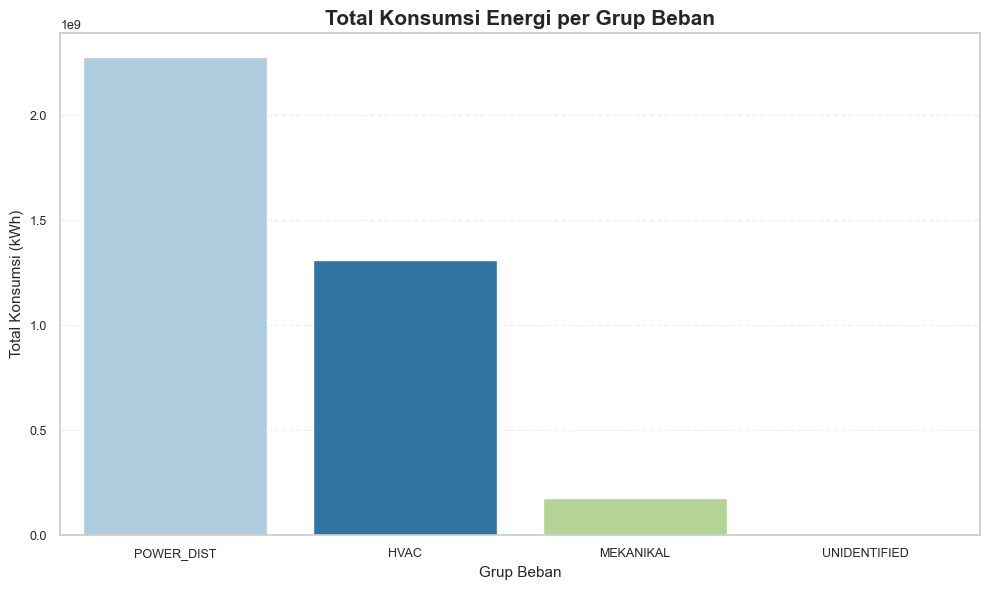


=== Total Konsumsi Energi per Grup Beban ===

group_beban
POWER_DIST      2.28e+09
HVAC            1.31e+09
MEKANIKAL       1.78e+08
UNIDENTIFIED    0.00e+00
Name: energy_consumed_kwh, dtype: float64




In [74]:
# ==========================================
# 5.1. AGREGASI KONSUMSI BERDASARKAN GROUP BEBAN
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
group_consumption = df.groupby('group_beban')['energy_consumed_kwh'].sum().sort_values(ascending=False)

sns.barplot(x=group_consumption.index, y=group_consumption.values, palette='Paired')
plt.title('Total Konsumsi Energi per Grup Beban', fontsize=15, fontweight='bold')
plt.ylabel('Total Konsumsi (kWh)')
plt.xlabel('Grup Beban')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print tabel
print("\n=== Total Konsumsi Energi per Grup Beban ===\n")
print(group_consumption)
print("\n" + "="*50 + "\n")

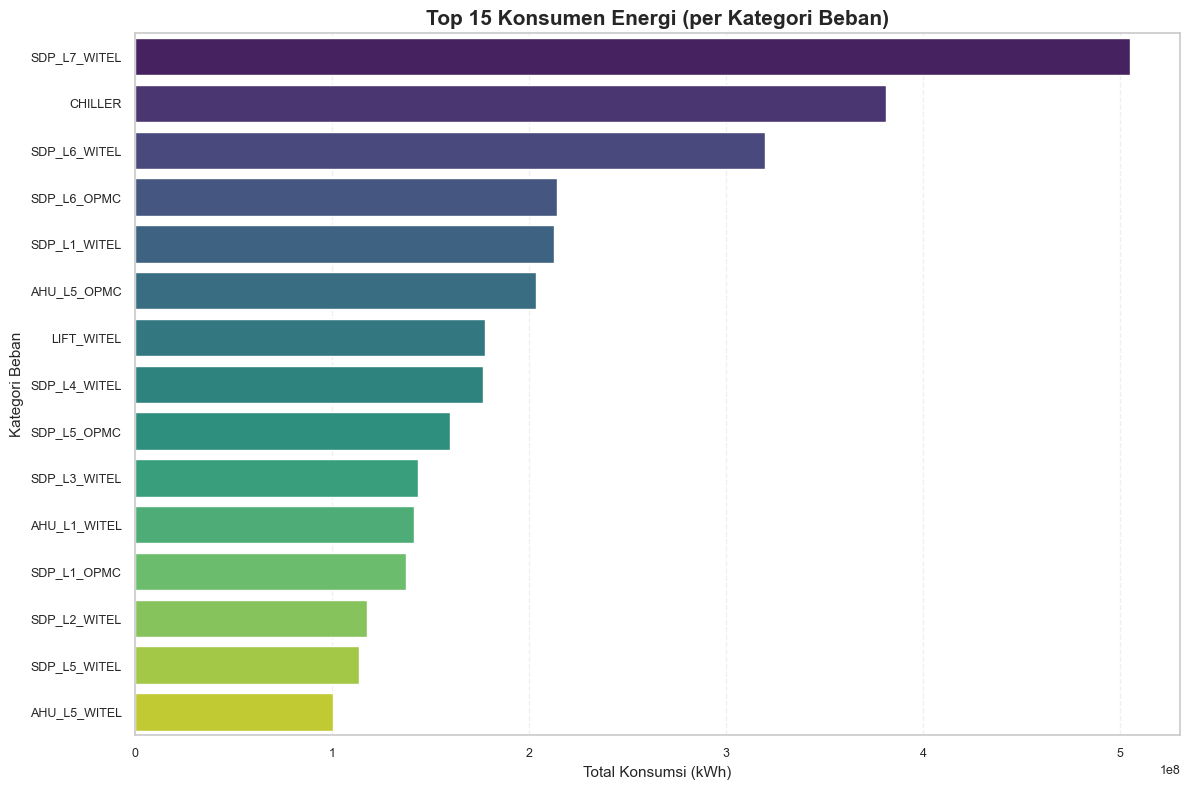


=== Top 10 Konsumen Energi (Kategori Beban) ===

kategori_beban
SDP_L7_WITEL    5.05e+08
CHILLER         3.81e+08
SDP_L6_WITEL    3.20e+08
SDP_L6_OPMC     2.14e+08
SDP_L1_WITEL    2.13e+08
AHU_L5_OPMC     2.04e+08
LIFT_WITEL      1.78e+08
SDP_L4_WITEL    1.77e+08
SDP_L5_OPMC     1.60e+08
SDP_L3_WITEL    1.44e+08
Name: energy_consumed_kwh, dtype: float64




In [75]:
# ==========================================
# 5.2. AGREGASI KONSUMSI BERDASARKAN KATEGORI BEBAN (DETAIL)
# ==========================================

plt.figure(figsize=(12, 8))
category_consumption = df.groupby('kategori_beban')['energy_consumed_kwh'].sum().sort_values(ascending=False)

# Plot hanya 15 teratas untuk visualisasi yang informatif
sns.barplot(
    x=category_consumption.values[:15], 
    y=category_consumption.index[:15], 
    orient='h', 
    palette='viridis'
)
plt.title('Top 15 Konsumen Energi (per Kategori Beban)', fontsize=15, fontweight='bold')
plt.xlabel('Total Konsumsi (kWh)')
plt.ylabel('Kategori Beban')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print tabel 10 teratas
print("\n=== Top 10 Konsumen Energi (Kategori Beban) ===\n")
print(category_consumption.head(10))
print("\n" + "="*50 + "\n")

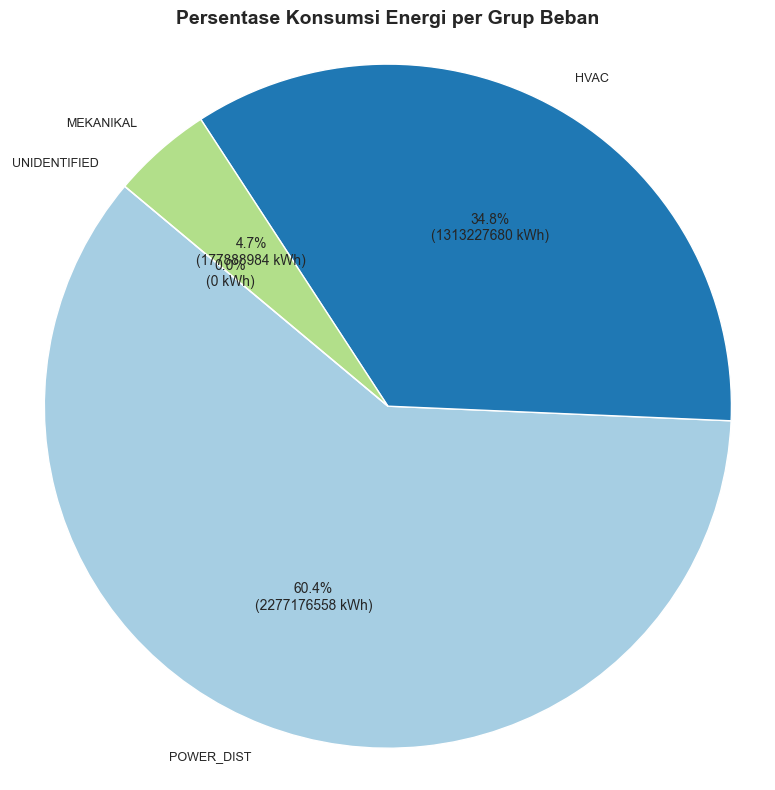

In [76]:
# ==========================================
# 5.3. PIE CHART & PERSENTASE (BREAKDOWN)
# ==========================================

plt.figure(figsize=(8, 8))
labels = group_consumption.index
sizes = group_consumption.values

plt.pie(
    sizes, labels=labels, autopct=lambda p: f'{p:.1f}%\n({p/100.*sum(sizes):.0f} kWh)',
    startangle=140, colors=sns.color_palette('Paired', len(labels)),
    wedgeprops=dict(edgecolor='w', linewidth=1)
)
plt.title('Persentase Konsumsi Energi per Grup Beban', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [77]:
# ==========================================
# 5.4. INSIGHT OTOMATIS: WHO IS THE ENERGY HOG?
# ==========================================

# Grup konsumsi terbesar
top_group = group_consumption.idxmax()
top_group_pct = (group_consumption.iloc[0] / group_consumption.sum()) * 100

print(f"\n🔎 Grup Penyumbang Konsumsi Terbanyak: {top_group} ({top_group_pct:.1f}%)")
print(f"   • Total Konsumsi Grup '{top_group}': {group_consumption.iloc[0]:,.2f} kWh")
print("\nRincian Top 5 Kategori Beban (di grup tersebut):")

detail = df[df['group_beban'] == top_group] \
    .groupby('kategori_beban')['energy_consumed_kwh'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(5)

for i, (kat, val) in enumerate(detail.items(), 1):
    pct = val / group_consumption.iloc[0] * 100
    print(f"   {i}. {kat:25s} {val:,.1f} kWh ({pct:.1f}%)")

print("\nRekomendasi: Fokus analisis lanjutan ke grup dan beban di atas\n")
print("="*50)


🔎 Grup Penyumbang Konsumsi Terbanyak: POWER_DIST (60.4%)
   • Total Konsumsi Grup 'POWER_DIST': 2,277,176,614.58 kWh

Rincian Top 5 Kategori Beban (di grup tersebut):
   1. SDP_L7_WITEL              505,149,818.9 kWh (22.2%)
   2. SDP_L6_WITEL              319,668,359.6 kWh (14.0%)
   3. SDP_L6_OPMC               214,382,860.6 kWh (9.4%)
   4. SDP_L1_WITEL              212,976,789.6 kWh (9.4%)
   5. SDP_L4_WITEL              176,882,667.3 kWh (7.8%)

Rekomendasi: Fokus analisis lanjutan ke grup dan beban di atas



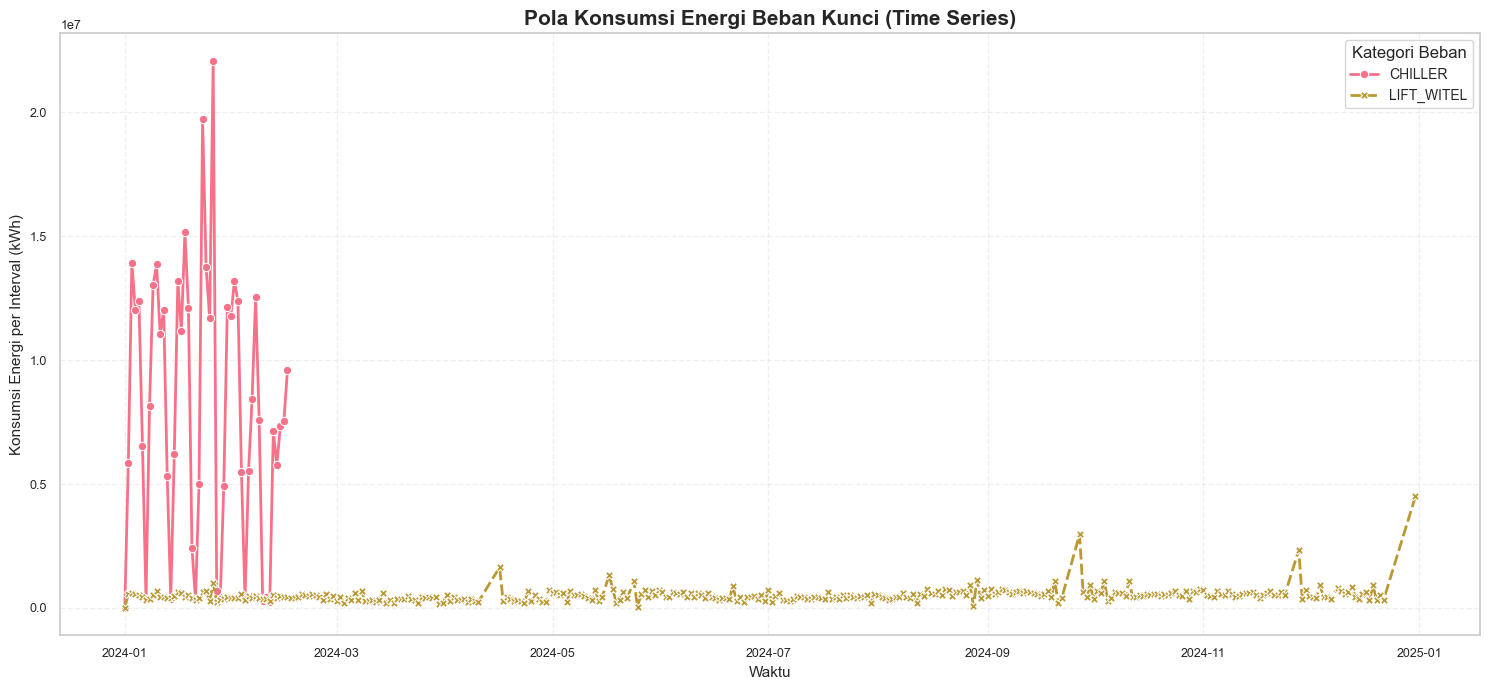

In [78]:
# ==========================================
# 6.1. ANALISIS DERET WAKTU (TIME SERIES)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Pilih kategori beban kunci yang menarik dari peta
meters_to_plot = ['LIFT_WITEL', 'CHILLER', 'SERVER_NOC']

# Filter data hanya untuk meter-meter tersebut
df_plot = df[df['kategori_beban'].isin(meters_to_plot)].copy()

plt.figure(figsize=(15, 7))

# Lineplot: tren konsumsi dari waktu ke waktu untuk tiap kategori
sns.lineplot(
    data=df_plot,
    x='id_time',
    y='energy_consumed_kwh',
    hue='kategori_beban',
    style='kategori_beban',
    markers=True,
    linewidth=2.0
)

plt.title('Pola Konsumsi Energi Beban Kunci (Time Series)', fontsize=15, fontweight='bold')
plt.ylabel('Konsumsi Energi per Interval (kWh)')
plt.xlabel('Waktu')
plt.legend(title='Kategori Beban')
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

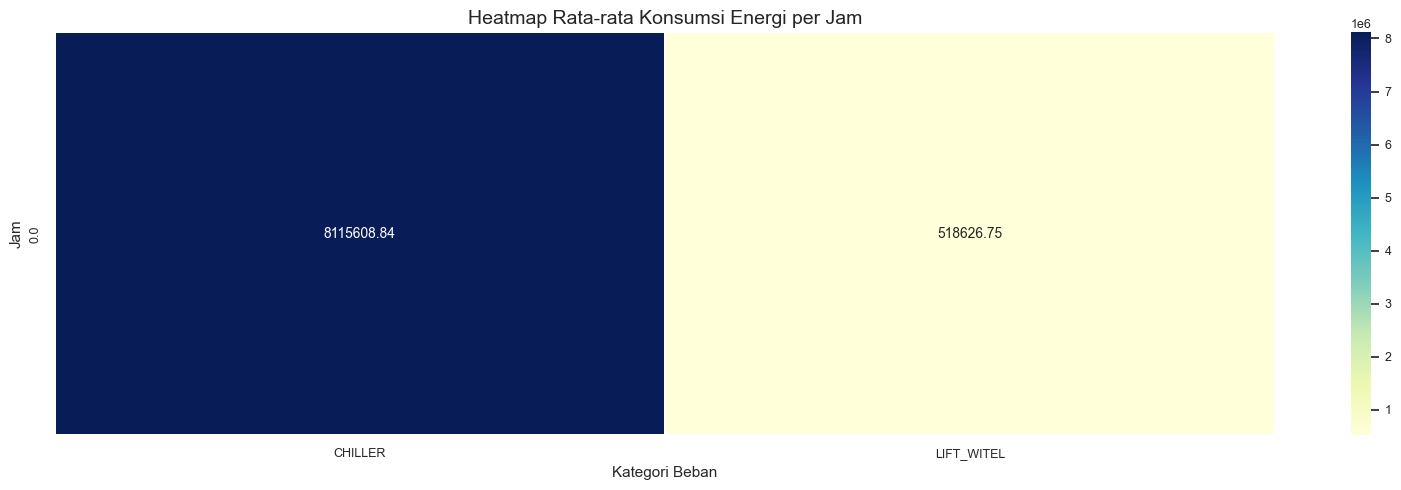

In [79]:
# ==========================================
# 6.2. EXPLORASI POLA BERDASARKAN JAM (HEATMAP)
# ==========================================

plt.figure(figsize=(16, 5))

# Buat fitur jam dari waktu
if not 'hour' in df_plot.columns:
    df_plot['hour'] = df_plot['id_time'].dt.hour
if not 'dayofweek' in df_plot.columns:
    df_plot['dayofweek'] = df_plot['id_time'].dt.dayofweek

pivot = df_plot.pivot_table(
    index='hour',
    columns='kategori_beban',
    values='energy_consumed_kwh',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=.3
)
plt.title('Heatmap Rata-rata Konsumsi Energi per Jam', fontsize=14)
plt.ylabel('Jam')
plt.xlabel('Kategori Beban')
plt.tight_layout()
plt.show()

In [80]:
# ==========================================
# 6.3. INTERPRETASI & HIPOTESIS POLA
# ==========================================

print("\n=== HIPOTESIS POLA WAKTU ===")
for meter in meters_to_plot:
    if meter in df_plot['kategori_beban'].unique():
        print(f"\n— {meter}:")
        if meter == 'LIFT_WITEL':
            print("  • Ciri khas: Banyak spike. Konsumsi muncul saat penggunaan/perpindahan orang. Pola sering kali hanya intens pada jam kerja.")
        elif meter == 'SERVER_NOC':
            print("  • Stabil/flat hampir sepanjang waktu. Idealnya 24/7, sedikit variasi kecuali ada pemeliharaan/gedung kosong sepenuhnya.")
        elif meter == 'CHILLER':
            print("  • Konsumsi tinggi dan fluktuatif. Sering terlihat pola siklik (nyala-mati) tergantung setpoint suhu dan jam operasional. Pola naik siang/sore, rendah malam.")
        else:
            print("  • Perlu analisis lanjutan.")
print("\n")

print("➡️ Insight: Pola-pola ini bisa digunakan untuk:")
print("   • Menyetting timer otomatisasi beban (misal HVAC/lift lock di malam hari)")
print("   • Deteksi penggunaan abnormal (lift malam hari, server down, chiller terus menyala di weekend/dini hari)")
print("   • Estimasi potensi penghematan jika jam operasi disesuaikan")


=== HIPOTESIS POLA WAKTU ===

— LIFT_WITEL:
  • Ciri khas: Banyak spike. Konsumsi muncul saat penggunaan/perpindahan orang. Pola sering kali hanya intens pada jam kerja.

— CHILLER:
  • Konsumsi tinggi dan fluktuatif. Sering terlihat pola siklik (nyala-mati) tergantung setpoint suhu dan jam operasional. Pola naik siang/sore, rendah malam.


➡️ Insight: Pola-pola ini bisa digunakan untuk:
   • Menyetting timer otomatisasi beban (misal HVAC/lift lock di malam hari)
   • Deteksi penggunaan abnormal (lift malam hari, server down, chiller terus menyala di weekend/dini hari)
   • Estimasi potensi penghematan jika jam operasi disesuaikan
